------
**You cannot apply any changes to this file, so please make sure to save it on your Google Colab drive or download it as a .ipynb file.**

------


# Practical 2: Representing Sentences with Neural Models

In this second practical, we will train neural network models to obtain sentence representations. We can then use these sentence representations for a downstream task such as sentiment classification.

In this notebook, we will help you to develop models for your experiments. But this time, next to completing the notebook, **you are expected to write a four-page scientific report with your findings**. Please still submit the notebook together with your scientific report so that we can reproduce your experiments. (Note: if you find it useful, you can split this notebook into multiple notebooks. If you do so, keep it mind that it should be possible for your TAs to reproduce the entire content of the notebooks without having to ask for clarifications or to copy and paste functions from one sub-notebook to another.) Make sure your code corresponds to the description you give in the report; we will deduct points if this is not the case. **Make sure you run all your code before submitting the notebook, and do not leave unnecessary print statements / cells in your notebook that are not intended for the grader.**

**Important!** The main purpose of this lab is for you to learn how to answer research questions by experimenting and then writing a scientific report.
So you will be *judged by the quality of your report* but will lose points if your experiments are not reproducible.
You can find the requirements for the report at the end of this notebook.


### Data set
We will use the [Stanford Sentiment Treebank](https://nlp.stanford.edu/sentiment/) (SST), which provides sentences, their binary tree structure, and fine-grained sentiment scores.
This dataset is different from the one we used in the first practical.
In Practical 1, a review consisted of several sentences, and we had one sentiment score for the whole review. Now, a review consists of a single sentence, and we have a sentiment score for each node in the binary tree that makes up the sentence, including the root node (i.e., we still have an overall sentiment score for the entire review). We will look at an example below.

In the first part of this practical we will only make use of the sentence tokens whereas in the second part we will also exploit the tree structure that is provided by the SST.

We will cover the following approaches:

- Bag-of-words (BOW)
- Continuous bag-of-words (CBOW)
- Deep continuous bag-of-words (Deep CBOW)
- LSTM
- Tree-LSTM


## Preparing the data

Let's first download the data set and take a look.

In [ ]:
import re
import random
import time
import math
import numpy as np
import nltk
import matplotlib.pyplot as plt
plt.style.use('default')

In [ ]:
!wget http://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip
!unzip trainDevTestTrees_PTB.zip

--2024-12-06 08:03:22--  http://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip [following]
--2024-12-06 08:03:23--  https://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 789539 (771K) [application/zip]
Saving to: ‘trainDevTestTrees_PTB.zip’

trainDevTestTrees_P 100%[===================>] 771.03K  2.33MB/s    in 0.3s    

2024-12-06 08:03:23 (2.33 MB/s) - ‘trainDevTestTrees_PTB.zip’ saved [789539/789539]

Archive:  trainDevTestTrees_PTB.zip
   creating: trees/
  inflating: trees/dev.txt           
  inflating: trees/test.txt          
  inflating: trees/train.txt         


In [ ]:
# this function reads in a textfile and fixes an issue with "\\"
def filereader(path):
  with open(path, mode="r", encoding="utf-8") as f:
    for line in f:
      yield line.strip().replace("\\","")

Let's look at a data point. It is a **flattened binary tree**, with sentiment scores at every node, and words as the leaves (or *terminal nodes*).

In [ ]:
s = next(filereader("trees/dev.txt"))
print(s)

(3 (2 It) (4 (4 (2 's) (4 (3 (2 a) (4 (3 lovely) (2 film))) (3 (2 with) (4 (3 (3 lovely) (2 performances)) (2 (2 by) (2 (2 (2 Buy) (2 and)) (2 Accorsi))))))) (2 .)))


In [ ]:
# We can use NLTK to better visualise the tree structure of the sentence
from nltk import Tree
from nltk.treeprettyprinter import TreePrettyPrinter
tree = Tree.fromstring(s)
print(TreePrettyPrinter(tree))

              3                                                                     
  ____________|____________________                                                  
 |                                 4                                                
 |        _________________________|______________________________________________   
 |       4                                                                        | 
 |    ___|______________                                                          |  
 |   |                  4                                                         | 
 |   |         _________|__________                                               |  
 |   |        |                    3                                              | 
 |   |        |               _____|______________________                        |  
 |   |        |              |                            4                       | 
 |   |        |              |            ________________|_

<ipython-input-6-6ab7e95feba4>:5: DeprecationWarning: 
    Class TreePrettyPrinter has been deprecated.  Import
    `TreePrettyPrinter` using `from nltk.tree import
    TreePrettyPrinter` instead.
  print(TreePrettyPrinter(tree))


The sentiment scores range from 0 (very negative) to 5 (very positive). Again, as you can see, every node in the tree is labeled with a sentiment score. For now, we will only use the score at the **root node**, i.e., the sentiment score for the complete sentence.

In [ ]:
# Let's first make a function that extracts the tokens (the leaves).

def tokens_from_treestring(s):
  """extract the tokens from a sentiment tree"""
  return re.sub(r"\([0-9] |\)", "", s).split()

# let's try it on our example tree
tokens = tokens_from_treestring(s)
print(tokens)
print(len(tokens))

['It', "'s", 'a', 'lovely', 'film', 'with', 'lovely', 'performances', 'by', 'Buy', 'and', 'Accorsi', '.']
13


> *Warning: you could also parse a treestring using NLTK and ask it to return the leaves, but there seems to be an issue with NLTK not always correctly parsing the input, so do not rely on it.*

In [ ]:
# We will also need the following function, but you can ignore this for now.
# It is explained later on.

SHIFT = 0
REDUCE = 1


def transitions_from_treestring(s):
  s = re.sub("\([0-5] ([^)]+)\)", "0", s)
  s = re.sub("\)", " )", s)
  s = re.sub("\([0-4] ", "", s)
  s = re.sub("\([0-4] ", "", s)
  s = re.sub("\)", "1", s)
  return list(map(int, s.split()))

In [ ]:
# Now let's first see how large our data sets are.
for path in ("trees/train.txt", "trees/dev.txt", "trees/test.txt"):
  print("{:16s} {:4d}".format(path, sum(1 for _ in filereader(path))))

trees/train.txt  8544
trees/dev.txt    1101
trees/test.txt   2210


You can see that the number of sentences is not very large. That's probably because the data set required so much manual annotation. However, it is large enough to train a neural network on.

It will be useful to store each data example in an `Example` object,
containing everything that we may need for each data point.
It will contain the tokens, the tree, the top-level sentiment label, and
the transitions (explained later).

In [ ]:
from collections import namedtuple
from nltk import Tree

# A simple way to define a class is using namedtuple.
Example = namedtuple("Example", ["tokens", "tree", "label", "transitions"])


def examplereader(path, lower=False):
  """Returns all examples in a file one by one."""
  for line in filereader(path):
    line = line.lower() if lower else line
    tokens = tokens_from_treestring(line)
    tree = Tree.fromstring(line)  # use NLTK's Tree
    label = int(line[1])
    trans = transitions_from_treestring(line)
    yield Example(tokens=tokens, tree=tree, label=label, transitions=trans)


# Let's load the data into memory.
LOWER = False  # we will keep the original casing
train_data = list(examplereader("trees/train.txt", lower=LOWER))
dev_data = list(examplereader("trees/dev.txt", lower=LOWER))
test_data = list(examplereader("trees/test.txt", lower=LOWER))

print("train", len(train_data))
print("dev", len(dev_data))
print("test", len(test_data))

train 8544
dev 1101
test 2210


Let's check out an `Example` object.

In [ ]:
example = dev_data[0]
print("First example:", example)
print("First example tokens:", example.tokens)
print("First example label:",  example.label)

First example: Example(tokens=['It', "'s", 'a', 'lovely', 'film', 'with', 'lovely', 'performances', 'by', 'Buy', 'and', 'Accorsi', '.'], tree=Tree('3', [Tree('2', ['It']), Tree('4', [Tree('4', [Tree('2', ["'s"]), Tree('4', [Tree('3', [Tree('2', ['a']), Tree('4', [Tree('3', ['lovely']), Tree('2', ['film'])])]), Tree('3', [Tree('2', ['with']), Tree('4', [Tree('3', [Tree('3', ['lovely']), Tree('2', ['performances'])]), Tree('2', [Tree('2', ['by']), Tree('2', [Tree('2', [Tree('2', ['Buy']), Tree('2', ['and'])]), Tree('2', ['Accorsi'])])])])])])]), Tree('2', ['.'])])]), label=3, transitions=[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1])
First example tokens: ['It', "'s", 'a', 'lovely', 'film', 'with', 'lovely', 'performances', 'by', 'Buy', 'and', 'Accorsi', '.']
First example label: 3


#### Vocabulary
A first step in most NLP tasks is collecting all the word types that appear in the data into a vocabulary, and counting the frequency of their occurrences. On the one hand, this will give us an overview of the word distribution of the data set (what are the most frequent words, how many rare words are there, ...). On the other hand, we will also use the vocabulary to map each word to a unique numeric ID, which is a more handy index than a string.

In [ ]:
# Here we first define a class that can map a word to an ID (w2i)
# and back (i2w).

from collections import Counter, OrderedDict, defaultdict


class OrderedCounter(Counter, OrderedDict):
  """Counter that remembers the order elements are first seen"""
  def __repr__(self):
    return '%s(%r)' % (self.__class__.__name__,
                      OrderedDict(self))
  def __reduce__(self):
    return self.__class__, (OrderedDict(self),)


class Vocabulary:
  """A vocabulary, assigns IDs to tokens"""

  def __init__(self):
    self.freqs = OrderedCounter()
    self.w2i = {}
    self.i2w = []

  def count_token(self, t):
    self.freqs[t] += 1

  def add_token(self, t):
    self.w2i[t] = len(self.w2i)
    self.i2w.append(t)

  def build(self, min_freq=0):
    '''
    min_freq: minimum number of occurrences for a word to be included
              in the vocabulary
    '''
    self.add_token("<unk>")  # reserve 0 for <unk> (unknown words)
    self.add_token("<pad>")  # reserve 1 for <pad> (discussed later)

    tok_freq = list(self.freqs.items())
    tok_freq.sort(key=lambda x: x[1], reverse=True)
    for tok, freq in tok_freq:
      if freq >= min_freq:
        self.add_token(tok)

The vocabulary has by default an `<unk>` token and a `<pad>` token. The `<unk>` token is reserved for all words which do not appear in the training data (and for which, therefore, we cannot learn word representations). The function of the `<pad>` token will be explained later.


Let's build the vocabulary!


In [ ]:
# This process should be deterministic and should have the same result
# if run multiple times on the same data set.

v = Vocabulary()
for data_set in (train_data,):
  for ex in data_set:
    for token in ex.tokens:
      v.count_token(token)

v.build()
print("Vocabulary size:", len(v.w2i))

Vocabulary size: 18280


Let's have a closer look at the properties of our vocabulary. Having a good idea of what it is like can facilitate data analysis and debugging later on.

In [ ]:
# What is the ID for "century?"
v.w2i['century']

1973

In [ ]:
# What are the first 10 words in the vocabulary (based on their IDs)?
for i in range(10):
  print(v.i2w[i])

<unk>
<pad>
.
,
the
and
a
of
to
's


In [ ]:
# What are the 10 most common words?
for i in range(2, 12):
  print(v.i2w[i])

.
,
the
and
a
of
to
's
is
that


In [ ]:
# And how many words are there with frequency 1?
# (A fancy name for these is hapax legomena.)
count = sum(1 for freq in v.freqs.values() if freq == 1)
print(count)

9543


In [ ]:
# Finally 20 random words from the vocabulary.
# This is a simple way to get a feeling for the data.
# You could use the `choice` function from the already imported `random` package
random_words = [random.choice(list(v.freqs.keys())) for _ in range(20)]
print(random_words)

['burgeoning', 'helmer', 'gang-infested', 'hooked', 'delay', 'entrée', 'Manipulative', 'existent', 'trove', 'plain', 'offal', 'twitchy', 'advertisement', 'Byron', 'Cosa', 'subtler', 'raunch-fests', 'dance', 'liveliness', 'friendly']


#### Sentiment label vocabulary

In [ ]:
# Now let's map the sentiment labels 0-4 to a more readable form
i2t = ["very negative", "negative", "neutral", "positive", "very positive"]
print(i2t)
print(i2t[4])

['very negative', 'negative', 'neutral', 'positive', 'very positive']
very positive


In [ ]:
# And let's also create the opposite mapping.
# We won't use a Vocabulary for this (although we could), since the labels
# are already numeric.
t2i = OrderedDict({p : i for p, i in zip(i2t, range(len(i2t)))})
print(t2i)
print(t2i['very positive'])

OrderedDict([('very negative', 0), ('negative', 1), ('neutral', 2), ('positive', 3), ('very positive', 4)])
4


## PyTorch

We are going to need PyTorch and Google Colab does not have it installed by default. Run the cell below to install it.

*For installing PyTorch in your own computer, follow the instructions on [pytorch.org](pytorch.org) instead. This is for Google Colab only.*

In [ ]:
import torch
print("Using torch", torch.__version__) # should say 1.7.0+cu101

Using torch 2.5.1+cu121


In [ ]:
# Let's also import torch.nn, a PyTorch package that
# makes building neural networks more convenient.
from torch import nn

In [ ]:
# PyTorch can run on CPU or on Nvidia GPU (video card) using CUDA
# This cell selects the GPU if one is available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
# Seed manually to make runs reproducible
# You need to set this again if you do multiple runs of the same model
torch.manual_seed(42)

# When running on the CuDNN backend two further options must be set for reproducibility
if torch.cuda.is_available():
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

# BOW

Our first model is a rather simple neural **bag-of-words (BOW) model**.
Unlike the bag-of-words model that you used in the previous lab, where we would look at the presence / frequency of words in a text, here we associate each word with a multi-dimensional vector which expresses what sentiment is conveyed by the word. In particular, our BOW vectors will be of size 5, exactly our number of sentiment classes.

To classify a sentence, we **sum** the vectors of the words in the sentence and a bias vector. Because we sum the vectors, we lose word order: that's why we call this a neural bag-of-words model.

```
this   [0.0, 0.1, 0.1, 0.1, 0.0]
movie  [0.0, 0.1, 0.1, 0.2, 0.1]
is     [0.0, 0.1, 0.0, 0.0, 0.0]
stupid [0.9, 0.5, 0.1, 0.0, 0.0]

bias   [0.0, 0.0, 0.0, 0.0, 0.0]
--------------------------------
sum    [0.9, 0.8, 0.3, 0.3, 0.1]

argmax: 0 (very negative)
```

The **argmax** of this sum is our predicted label.

We initialize all vectors *randomly* and train them using cross-entropy loss.

#### Model class

In [ ]:
class BOW(nn.Module):
  """A simple bag-of-words model"""

  def __init__(self, vocab_size, embedding_dim, vocab):
    super(BOW, self).__init__()
    self.vocab = vocab

    # this is a trainable look-up table with word embeddings
    self.embed = nn.Embedding(vocab_size, embedding_dim)

    # this is a trainable bias term
    self.bias = nn.Parameter(torch.zeros(embedding_dim), requires_grad=True)

  def forward(self, inputs):
    # this is the forward pass of the neural network
    # it applies a function to the input and returns the output

    # this looks up the embeddings for each word ID in inputs
    # the result is a sequence of word embeddings
    embeds = self.embed(inputs)

    # the output is the sum across the time dimension (1)
    # with the bias term added
    logits = embeds.sum(1) + self.bias

    return logits

In [ ]:
# Let's create a model.
vocab_size = len(v.w2i)
n_classes = len(t2i)
bow_model = BOW(vocab_size, n_classes, v)
print(bow_model)

BOW(
  (embed): Embedding(18280, 5)
)


> **Hey, wait, where is the bias vector?**
> PyTorch does not print Parameters, only Modules!

> We can print it ourselves though, to check that it is there.

In [ ]:

# Here we print each parameter name, shape, and if it is trainable.
def print_parameters(model):
  total = 0
  for name, p in model.named_parameters():
    total += np.prod(p.shape)
    print("{:24s} {:12s} requires_grad={}".format(name, str(list(p.shape)), p.requires_grad))
  print("\nTotal number of parameters: {}\n".format(total))


print_parameters(bow_model)

bias                     [5]          requires_grad=True
embed.weight             [18280, 5]   requires_grad=True

Total number of parameters: 91405



#### Preparing an example for input

To feed sentences to our PyTorch model, we need to convert a sequence of tokens to a sequence of IDs. The `prepare_example` function below takes care of this for us. We then use these IDs as indices for the word embedding table.

In [ ]:
def prepare_example(example, vocab):
  """
  Map tokens to their IDs for a single example
  """

  # vocab returns 0 if the word is not there (i2w[0] = <unk>)
  x = [vocab.w2i.get(t, 0) for t in example.tokens]

  x = torch.LongTensor([x])
  x = x.to(device)

  y = torch.LongTensor([example.label])
  y = y.to(device)

  return x, y

In [ ]:
x, y = prepare_example(dev_data[0], v)
print('x:', x)
print('y:', y)

x: tensor([[  28,    9,    6,  998,   16,   18,  998,  135,   32, 7688,    5,    0,
            2]])
y: tensor([3])


#### Evaluation
We now need to define an evaluation metric.
How many predictions do we get right? The accuracy will tell us.
Make sure that you understand this code block.


In [ ]:
def simple_evaluate(model, data, prep_fn=prepare_example, **kwargs):
  """Accuracy of a model on given data set."""
  correct = 0
  total = 0
  model.eval()  # disable dropout (explained later)

  for example in data:

    # convert the example input and label to PyTorch tensors
    x, target = prep_fn(example, model.vocab)

    # forward pass without backpropagation (no_grad)
    # get the output from the neural network for input x
    with torch.no_grad():
      logits = model(x)

    # get the prediction
    prediction = logits.argmax(dim=-1)

    # add the number of correct predictions to the total correct
    correct += (prediction == target).sum().item()
    total += 1

  return correct, total, correct / float(total)

We are using accuracy as a handy evaluation metric. Please consider using [alternative metrics](https://scikit-learn.org/stable/modules/classes.html#classification-metrics) for your experiments if that makes more theoretical sense.

#### Example feed
For stochastic gradient descent (SGD) we will need a random training example for every update.
We implement this by shuffling the training data and returning examples one by one using `yield`.

Shuffling is optional so that we get to use this function to get validation and test examples, too.

In [ ]:
def get_examples(data, shuffle=True, **kwargs):
  """Shuffle data set and return 1 example at a time (until nothing left)"""
  if shuffle:
    print("Shuffling training data")
    random.shuffle(data)  # shuffle training data each epoch
  for example in data:
    yield example

#### Exercise: Training function

Your task is now to complete the training loop below.
Before you do so, please read the section about optimisation.

**Optimisation**

As mentioned in the "Intro to PyTorch" notebook, one of the perks of using PyTorch is automatic differentiation. We will use it to train our BOW model.

We train our model by feeding it an input, performing a **forward** pass, obtaining an output prediction, and calculating a **loss** with our loss function.
After the gradients are computed in the **backward** pass, we can take a step on the surface of the loss function towards more optimal parameter settings (gradient descent).

The package we will use to do this optimisation is [torch.optim](https://pytorch.org/docs/stable/optim.html).

In [ ]:
from torch import optim

Besides implementations of stochastic gradient descent (SGD), this package also implements the optimisation algorithm Adam, which we'll be using in this practical.
For the purposes of this assignment you do not need to know what Adam does besides that it uses gradient information to update our model parameters by calling:

```
optimizer.step()
```
Remember when we updated our parameters in the PyTorch tutorial in a loop?


```python
# update weights
learning_rate = 0.5
for f in net.parameters():
    # for each parameter, take a small step in the opposite dir of the gradient
    p.data = p.data - p.grad.data * learning_rate

```
The function call optimizer.step() does effectively the same thing.

*(If you want to know more about optimisation algorithms using gradient information, [this blog](http://ruder.io/optimizing-gradient-descent/.) gives a nice intuitive overview.)*

In [ ]:
def train_model(model, optimizer, num_iterations=10000,
                print_every=1000, eval_every=1000,
                batch_fn=get_examples,
                prep_fn=prepare_example,
                eval_fn=simple_evaluate,
                batch_size=1, eval_batch_size=None):
  """Train a model."""
  iter_i = 0
  train_loss = 0.
  print_num = 0
  start = time.time()
  criterion = nn.CrossEntropyLoss() # loss function
  best_eval = 0.
  best_iter = 0

  # store train loss and validation accuracy during training
  # so we can plot them afterwards
  losses = []
  accuracies = []

  if eval_batch_size is None:
    eval_batch_size = batch_size

  while True:  # when we run out of examples, shuffle and continue
    for batch in batch_fn(train_data, batch_size=batch_size):

      # forward pass
      model.train()
      x, targets = prep_fn(batch, model.vocab)
      logits = model(x)

      B = targets.size(0)  # later we will use B examples per update

      # compute cross-entropy loss (our criterion)
      # note that the cross entropy loss function computes the softmax for us
      loss = criterion(logits.view([B, -1]), targets.view(-1))
      train_loss += loss.item()

      # backward pass (tip: check the Introduction to PyTorch notebook)
      # erase previous gradients
      #raise NotImplementedError("Implement this")
      # YOUR CODE HERE
      optimizer.zero_grad()

      # compute gradients
      # YOUR CODE HERE
      loss.backward()
      # update weights - take a small step in the opposite dir of the gradient
      # YOUR CODE HERE
      optimizer.step()

      print_num += 1
      iter_i += 1

      # print info
      if iter_i % print_every == 0:
        print("Iter %r: loss=%.4f, time=%.2fs" %
              (iter_i, train_loss, time.time()-start))
        losses.append(train_loss)
        print_num = 0
        train_loss = 0.

      # evaluate
      if iter_i % eval_every == 0:
        _, _, accuracy = eval_fn(model, dev_data, batch_size=eval_batch_size,
                                 batch_fn=batch_fn, prep_fn=prep_fn)
        accuracies.append(accuracy)
        print("iter %r: dev acc=%.4f" % (iter_i, accuracy))

        # save best model parameters
        if accuracy > best_eval:
          print("new highscore")
          best_eval = accuracy
          best_iter = iter_i
          path = "{}.pt".format(model.__class__.__name__)
          ckpt = {
              "state_dict": model.state_dict(),
              "optimizer_state_dict": optimizer.state_dict(),
              "best_eval": best_eval,
              "best_iter": best_iter
          }
          torch.save(ckpt, path)

      # done training
      if iter_i == num_iterations:
        print("Done training")

        # evaluate on train, dev, and test with best model
        print("Loading best model")
        path = "{}.pt".format(model.__class__.__name__)
        ckpt = torch.load(path)
        model.load_state_dict(ckpt["state_dict"])

        _, _, train_acc = eval_fn(
            model, train_data, batch_size=eval_batch_size,
            batch_fn=batch_fn, prep_fn=prep_fn)
        _, _, dev_acc = eval_fn(
            model, dev_data, batch_size=eval_batch_size,
            batch_fn=batch_fn, prep_fn=prep_fn)
        _, _, test_acc = eval_fn(
            model, test_data, batch_size=eval_batch_size,
            batch_fn=batch_fn, prep_fn=prep_fn)

        print("best model iter {:d}: "
              "train acc={:.4f}, dev acc={:.4f}, test acc={:.4f}".format(
                  best_iter, train_acc, dev_acc, test_acc))

        return losses, accuracies

### Training the BOW model

In [ ]:
# If everything is in place we can now train our first model!
bow_model = BOW(len(v.w2i), len(t2i), vocab=v)
print(bow_model)

bow_model = bow_model.to(device)

optimizer = optim.Adam(bow_model.parameters(), lr=0.0005)
bow_losses, bow_accuracies = train_model(
    bow_model, optimizer, num_iterations=30000,
    print_every=1000, eval_every=1000)

BOW(
  (embed): Embedding(18280, 5)
)
Shuffling training data
Iter 1000: loss=5577.3964, time=4.09s
iter 1000: dev acc=0.1880
new highscore
Iter 2000: loss=4942.8635, time=6.65s
iter 2000: dev acc=0.1916
new highscore
Iter 3000: loss=4666.9829, time=9.34s
iter 3000: dev acc=0.1944
new highscore
Iter 4000: loss=4627.0178, time=12.13s
iter 4000: dev acc=0.1935
Iter 5000: loss=4371.7433, time=15.20s
iter 5000: dev acc=0.1944
Iter 6000: loss=4392.5845, time=19.09s
iter 6000: dev acc=0.2025
new highscore
Iter 7000: loss=4319.2754, time=22.48s
iter 7000: dev acc=0.2080
new highscore
Iter 8000: loss=4319.4380, time=26.26s
iter 8000: dev acc=0.2071
Shuffling training data
Iter 9000: loss=4323.9638, time=29.18s
iter 9000: dev acc=0.2044
Iter 10000: loss=4168.1204, time=32.82s
iter 10000: dev acc=0.2080
Iter 11000: loss=3895.1680, time=35.99s
iter 11000: dev acc=0.2125
new highscore
Iter 12000: loss=4031.3524, time=38.89s
iter 12000: dev acc=0.2162
new highscore
Iter 13000: loss=3977.4278, time=

<ipython-input-116-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 27000: train acc=0.3038, dev acc=0.2361, test acc=0.2443


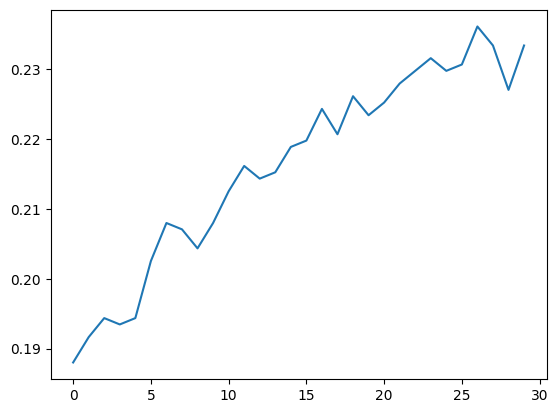

In [ ]:
# This will plot the validation accuracies across time.
plt.plot(bow_accuracies)

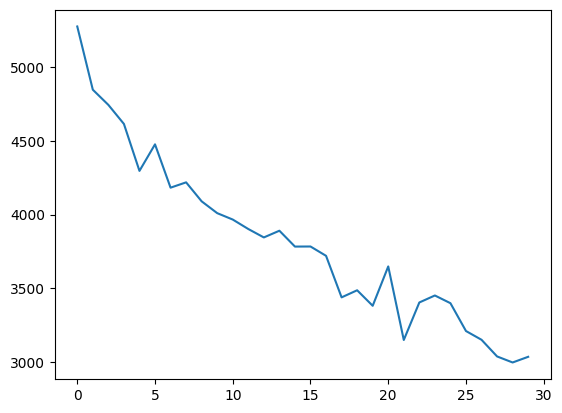

In [ ]:
# This will plot the training loss over time.
plt.plot(bow_losses)

Please note that we set the number of iterations to 30K as an indicative value, after which we simply stop training without checking for convergence. You should choose an appropriate number of iterations and motivate your decision. **This holds for all pre-set numbers of iteration in the following code blocks.**

# CBOW

We now continue with a **continuous bag-of-words (CBOW)** model. (*This is not the same as the word2vec CBOW model!*)

It is similar to the BOW model above, but now embeddings can have a dimension of *arbitrary size*.
This means that we can choose a higher dimensionality and learn more aspects of each word. We will still sum word vectors to get a sentence representation, but now the size of the resulting vector will no longer correspond to the number of sentiment classes.

So to turn the size of our summed vector into the number of output classes, we can *learn* a parameter matrix $W$ and multiply it by the sum vector $x$: $$Wx$$
If the size of $x$ is `d x 1`, we can set $W$ to be `5 x d`, so that the output of the matrix multiplication will be the of the desired size, `5 x 1`. Then, just like for the BOW model, we can obtain a prediction using the argmax function.

## Exercise: implement and train the CBOW model

Write a class `CBOW` that:

- has word embeddings with size 300
- sums the word vectors for the input words (just like in `BOW`)
- projects the resulting vector down to 5 units using a linear layer and a bias term (check out `nn.Linear`)

Train your CBOW model and plot the validation accuracy and training loss over time.

In [ ]:
class CBOW(nn.Module):
  """A simple bag-of-words model"""

  def __init__(self, vocab_size, embedding_dim, out_dim, vocab):
    super(CBOW, self).__init__()
    self.vocab = vocab

    # this is a trainable look-up table with word embeddings
    self.embed = nn.Embedding(vocab_size, embedding_dim)

    self.down_projection = nn.Linear(embedding_dim, out_dim)

  def forward(self, inputs):
    # this is the forward pass of the neural network
    # it applies a function to the input and returns the output

    # this looks up the embeddings for each word ID in inputs
    # the result is a sequence of word embeddings
    embeds = self.embed(inputs)

    # the output is the sum across the time dimension (1)
    # with the bias term added
    logits = self.down_projection(embeds.sum(1))

    return logits

In [ ]:
# If everything is in place we can now train our first model!
bow_model = CBOW(len(v.w2i), 300, len(t2i), vocab=v)
print(bow_model)

bow_model = bow_model.to(device)

optimizer = optim.Adam(bow_model.parameters(), lr=0.0005)
bow_losses, bow_accuracies = train_model(
    bow_model, optimizer, num_iterations=30000,
    print_every=250, eval_every=250, batch_size=25)

CBOW(
  (embed): Embedding(18280, 300)
  (down_projection): Linear(in_features=300, out_features=5, bias=True)
)
Shuffling training data
Iter 250: loss=824.8743, time=21.73s
iter 250: dev acc=0.2307
new highscore
Iter 500: loss=676.5886, time=40.46s
iter 500: dev acc=0.2470
new highscore
Iter 750: loss=611.4805, time=58.57s
iter 750: dev acc=0.2552
new highscore
Iter 1000: loss=651.7684, time=77.51s
iter 1000: dev acc=0.2534
Iter 1250: loss=636.9002, time=97.04s
iter 1250: dev acc=0.2325
Iter 1500: loss=630.7172, time=115.92s
iter 1500: dev acc=0.2434
Iter 1750: loss=590.3048, time=135.17s
iter 1750: dev acc=0.2516
Iter 2000: loss=555.8133, time=156.27s
iter 2000: dev acc=0.2579
new highscore
Iter 2250: loss=530.1156, time=177.06s
iter 2250: dev acc=0.2688
new highscore
Iter 2500: loss=552.1519, time=198.52s
iter 2500: dev acc=0.2688
Iter 2750: loss=524.0298, time=220.21s
iter 2750: dev acc=0.2698
new highscore
Iter 3000: loss=503.9673, time=243.21s
iter 3000: dev acc=0.2707
new highsc

<ipython-input-60-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 27250: train acc=0.6861, dev acc=0.3551, test acc=0.3443


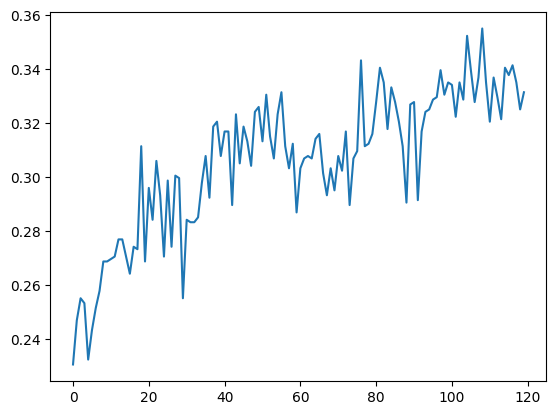

In [ ]:
# This will plot the validation accuracies across time.
plt.plot(bow_accuracies)

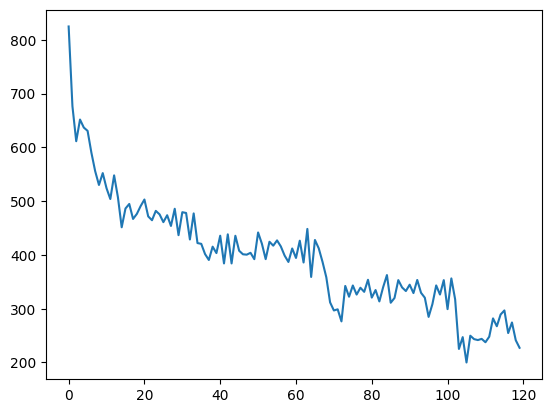

In [ ]:
# This will plot the training loss over time.
plt.plot(bow_losses)

# Deep CBOW

To see if we can squeeze some more performance out of the CBOW model, we can make it deeper and non-linear by adding more layers and, e.g., tanh-activations.
By using more parameters we can learn more aspects of the data, and by using more layers and non-linearities, we can try to learn a more complex function.
This is not something that always works. If the input-output mapping of your data is simple, then a complicated function could easily overfit on your training set, thereby leading to poor generalization.

#### Exercise: write Deep CBOW class and train it

Write a class `DeepCBOW`.

In your code, make sure that your `output_layer` consists of the following:
- A linear transformation from E units to D units.
- A Tanh activation
- A linear transformation from D units to D units
- A Tanh activation
- A linear transformation from D units to 5 units (our output classes).

E is the size of the word embeddings (please use E=300) and D for the size of a hidden layer (please use D=100).

We recommend using [nn.Sequential](https://pytorch.org/docs/stable/nn.html?highlight=sequential#torch.nn.Sequential) to implement this exercise.

In [ ]:
class DeepCBOW(nn.Module):
  """A simple bag-of-words model"""

  def __init__(self, vocab_size, E = 300, D = 100, output_classes = 5, vocab = None):
    super(DeepCBOW, self).__init__()
    self.vocab = vocab

    # this is a trainable look-up table with word embeddings
    self.embed = nn.Embedding(vocab_size, E)

    self.output_layer = nn.Sequential(
        nn.Linear(E, D),
        nn.Tanh(),
        nn.Linear(D, D),
        nn.Tanh(),
        nn.Linear(D, output_classes)
    )
  def forward(self, inputs):
    # this is the forward pass of the neural network
    # it applies a function to the input and returns the output

    # this looks up the embeddings for each word ID in inputs
    # the result is a sequence of word embeddings
    embeds = self.embed(inputs)

    # the output is the sum across the time dimension (1)
    # with the bias term added
    logits = self.output_layer(embeds.sum(1))

    return logits

In [ ]:
# If everything is in place we can now train our first model!
deep_bow_model = DeepCBOW(len(v.w2i), vocab=v)
print(deep_bow_model)

deep_bow_model = deep_bow_model.to(device)

optimizer = optim.Adam(deep_bow_model.parameters(), lr=0.0005)
deep_bow_losses, deep_bow_accuracies = train_model(
    deep_bow_model, optimizer, num_iterations=30000,
    print_every=250, eval_every=250, batch_size=25)

DeepCBOW(
  (embed): Embedding(18280, 300)
  (output_layer): Sequential(
    (0): Linear(in_features=300, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=5, bias=True)
  )
)
Shuffling training data
Iter 250: loss=405.2661, time=30.08s
iter 250: dev acc=0.2616
new highscore
Iter 500: loss=384.7336, time=64.66s
iter 500: dev acc=0.2797
new highscore
Iter 750: loss=389.8451, time=94.40s
iter 750: dev acc=0.2797
Iter 1000: loss=394.8412, time=124.05s
iter 1000: dev acc=0.2961
new highscore
Iter 1250: loss=389.4794, time=154.71s
iter 1250: dev acc=0.3161
new highscore
Iter 1500: loss=403.7066, time=185.92s
iter 1500: dev acc=0.2743
Iter 1750: loss=395.4301, time=216.65s
iter 1750: dev acc=0.2906
Iter 2000: loss=390.2362, time=247.71s
iter 2000: dev acc=0.3070
Iter 2250: loss=392.6410, time=281.00s
iter 2250: dev acc=0.2843
Iter 2500: loss=390.2666, time=313.50s
iter 2500:

<ipython-input-60-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 24500: train acc=0.6015, dev acc=0.3860, test acc=0.3688


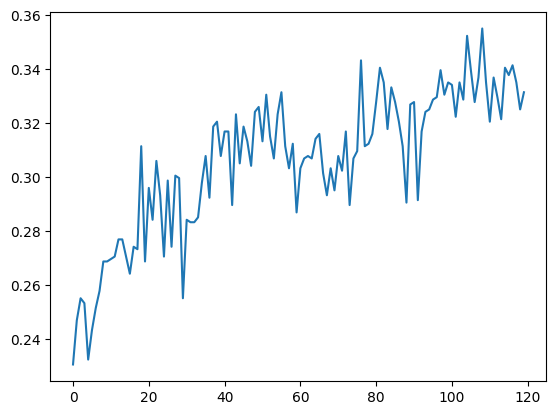

In [ ]:
# This will plot the validation accuracies across time.
plt.plot(bow_accuracies)

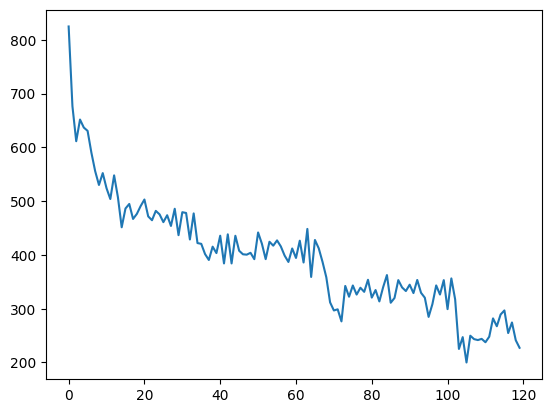

In [ ]:
# This will plot the training loss over time.
plt.plot(bow_losses)

# Pre-trained word embeddings

The Stanford Sentiment Treebank is a rather small data set, since it required fine-grained manual annotatation. This makes it difficult for the Deep CBOW model to learn good word embeddings, i.e. to learn good word representations for the words in our vocabulary.
In fact, the only error signal that the network receives is from predicting the sentiment of entire sentences!

To start off with better word representations, we can download **pre-trained word embeddings**.
You can choose which pre-trained word embeddings to use:

- **GloVe**. The "original" Stanford Sentiment classification [paper](http://aclweb.org/anthology/P/P15/P15-1150.pdf) used Glove embeddings, which are just another method (like *word2vec*) to get word embeddings from unannotated text. Glove is described in the following paper which you should cite if you use them:
> Jeffrey Pennington, Richard Socher, and Christopher Manning. ["Glove: Global vectors for word representation."](https://nlp.stanford.edu/pubs/glove.pdf) EMNLP 2014.

- **Word2Vec**. This is the method that you learned about in class, described in:
> Mikolov, Tomas, et al. ["Distributed representations of words and phrases and their compositionality."](https://papers.nips.cc/paper/5021-distributed-representations-of-words-and-phrases-and-their-compositionality.pdf) Advances in neural information processing systems. 2013.

Using these pre-trained word embeddings, we can initialize our word embedding lookup table and start form a point where similar words are already close to one another in the distributional semantic space.

You can choose to keep the word embeddings **fixed** or to train them further, specialising them to the task at hand.
We will keep them fixed for now.

For the purposes of this lab, it is enough if you understand how word2vec works (whichever vectors you use), but if you are interested, we encourage you to also check out the GloVe paper.

You can either download the word2vec vectors, or the Glove vectors.
If you want to compare your results to the Stanford paper later on, then you should use Glove.
**At the end of this lab you have the option to compare which vectors give you the best performance. For now, simply choose one of them and continue with that.**

[**OPTIONAL in case you don't want to mount Google Drive:** instead of running all the 5 boxes below, you can 1) download the GloVe and word2vec in your local machine, 2) upload them on your Drive folder ("My Drive"). Then, uncomment the first 2 lines in box 6 before writing your code!]


In [ ]:
# This downloads the Glove 840B 300d embeddings.
# The original file is at http://nlp.stanford.edu/data/glove.840B.300d.zip
# Since that file is 2GB, we provide you with a *filtered version*
# which contains all the words you need for this data set.

# You only need to do this once.
# Please comment this cell out after downloading.

!wget https://gist.githubusercontent.com/bastings/b094de2813da58056a05e8e7950d4ad1/raw/3fbd3976199c2b88de2ae62afc0ecc6f15e6f7ce/glove.840B.300d.sst.txt

--2024-12-06 08:05:01--  https://gist.githubusercontent.com/bastings/b094de2813da58056a05e8e7950d4ad1/raw/3fbd3976199c2b88de2ae62afc0ecc6f15e6f7ce/glove.840B.300d.sst.txt
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53933315 (51M) [text/plain]
Saving to: ‘glove.840B.300d.sst.txt’

glove.840B.300d.sst 100%[===================>]  51.43M   272MB/s    in 0.2s    

2024-12-06 08:05:03 (272 MB/s) - ‘glove.840B.300d.sst.txt’ saved [53933315/53933315]



In [ ]:
# This downloads the word2vec 300D Google News vectors
# The file has been truncated to only contain words that appear in our data set.
# You can find the original file here: https://code.google.com/archive/p/word2vec/

# You only need to do this once.
# Please comment this out after downloading.
!wget https://gist.githubusercontent.com/bastings/4d1c346c68969b95f2c34cfbc00ba0a0/raw/76b4fefc9ef635a79d0d8002522543bc53ca2683/googlenews.word2vec.300d.txt

--2024-12-06 08:05:06--  https://gist.githubusercontent.com/bastings/4d1c346c68969b95f2c34cfbc00ba0a0/raw/76b4fefc9ef635a79d0d8002522543bc53ca2683/googlenews.word2vec.300d.txt
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66209703 (63M) [text/plain]
Saving to: ‘googlenews.word2vec.300d.txt’

googlenews.word2vec 100%[===================>]  63.14M   231MB/s    in 0.3s    

2024-12-06 08:05:08 (231 MB/s) - ‘googlenews.word2vec.300d.txt’ saved [66209703/66209703]



In [ ]:
# Mount Google Drive (to save the downloaded files)
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
# Copy word vectors *to* Google Drive

# You only need to do this once.
# Please comment this out after running it.
!cp "glove.840B.300d.sst.txt" "/gdrive/My Drive/"
!cp "googlenews.word2vec.300d.txt" "/gdrive/My Drive/"

In [ ]:
# If you copied the word vectors to your Drive before,
# here is where you copy them back to the Colab notebook.

# Copy Glove vectors *from* Google Drive
!cp "/gdrive/My Drive/glove.840B.300d.sst.txt" .
!cp "/gdrive/My Drive/googlenews.word2vec.300d.txt" .

In [ ]:
# Uncomment these 2 lines below if went for the OPTIONAL method described above
# !cp "glove.840B.300d.sst.txt" "./"
# !cp "googlenews.word2vec.300d.txt" "./"

At this point you have the pre-trained word embedding files, but what do they look like?

In [ ]:
# Exercise: Print the first 4 lines of the files that you downloaded.

with open('glove.840B.300d.sst.txt', 'r') as file:
    for _ in range(4):
        print(file.readline())


with open('googlenews.word2vec.300d.txt', 'r') as file:
    for _ in range(4):
        print(file.readline())

# What do you see? The pre-trained word embedding files contain words followed by their corresponding 300-dimensional vectors, with each vector represented as 300 space-separated floating-point numbers.

, -0.082752 0.67204 -0.14987 -0.064983 0.056491 0.40228 0.0027747 -0.3311 -0.30691 2.0817 0.031819 0.013643 0.30265 0.0071297 -0.5819 -0.2774 -0.062254 1.1451 -0.24232 0.1235 -0.12243 0.33152 -0.006162 -0.30541 -0.13057 -0.054601 0.037083 -0.070552 0.5893 -0.30385 0.2898 -0.14653 -0.27052 0.37161 0.32031 -0.29125 0.0052483 -0.13212 -0.052736 0.087349 -0.26668 -0.16897 0.015162 -0.0083746 -0.14871 0.23413 -0.20719 -0.091386 0.40075 -0.17223 0.18145 0.37586 -0.28682 0.37289 -0.16185 0.18008 0.3032 -0.13216 0.18352 0.095759 0.094916 0.008289 0.11761 0.34046 0.03677 -0.29077 0.058303 -0.027814 0.082941 0.1862 -0.031494 0.27985 -0.074412 -0.13762 -0.21866 0.18138 0.040855 -0.113 0.24107 0.3657 -0.27525 -0.05684 0.34872 0.011884 0.14517 -0.71395 0.48497 0.14807 0.62287 0.20599 0.58379 -0.13438 0.40207 0.18311 0.28021 -0.42349 -0.25626 0.17715 -0.54095 0.16596 -0.036058 0.08499 -0.64989 0.075549 -0.28831 0.40626 -0.2802 0.094062 0.32406 0.28437 -0.26341 0.11553 0.071918 -0.47215 -0.18366 -0.3

#### Exercise: New Vocabulary

Since we now use pre-trained word embeddings, we need to create a new vocabulary.
This is because of two reasons:

1. We do not have pre-trained word embeddings for all words in our SST training set, and we do not want words in our vocabulary for which we have no word embeddings.
2. We should be able to look up the pre-trained word embedding for words in the validation and test set, even if these words are unseen in training.

Now, create a new vocabulary object `v` based on the word set of pre-trained embeddings, and load the corresponding embeddings into a list `vectors`.

The vocabulary `v` should consist of:
 - a  `<unk>` token at position 0,
 - a  `<pad>` token at position 1,
 - and then all words in the pre-trained embedding set.


After storing each vector in a list `vectors`, turn the list into a numpy matrix like this:
```python
 vectors = np.stack(vectors, axis=0)
```

Remember to add new embeddings for the `<unk>` and `<pad>` tokens, as they're not part of the word2vec/GloVe embeddings. These embeddings can be randomly initialized or 0-valued, think about what makes sense and see what the effects are.


In [ ]:
# YOUR CODE HERE
def process_embeddings(embedding_file):
    v = Vocabulary()
    vectors = [np.random.randn(300), np.zeros(300)]

    v.add_token('<unk>')
    v.add_token('<pad>')

    with open(embedding_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word, embedding = parts[0], np.array(parts[1:], dtype=float)
            v.add_token(word)
            vectors.append(embedding)

    return v, np.stack(vectors, axis=0)

glove_v, glove_vectors = process_embeddings('glove.840B.300d.sst.txt')

print(glove_vectors.shape)
print(len(glove_v.w2i))


(20727, 300)
20727


#### Exercise: words not in our pre-trained set

How many words in the training, dev, and test set are also in your vector set?
How many words are not there?

Store the words that are not in the word vector set in the set below.

In [ ]:
words_not_found = set()
# YOUR CODE HERE

words_found = set()

for data_set, name in [(train_data, 'train'), (dev_data, 'dev'), (test_data, 'test')]:
    found, not_found = set(), set()

    for example in data_set:
        tokens = set(example.tokens)
        found.update(tokens & glove_v.w2i.keys())
        not_found.update(tokens - glove_v.w2i.keys())

    words_found.update(found)
    words_not_found.update(not_found)

    print(f"{name} set: {len(found)} words found, {len(not_found)} words not found.")

print(f"Total number of words found: {len(words_found)}")
print(f"Total number of words not found: {len(words_not_found)}")

train set: 17579 words found, 699 words not found.
dev set: 5269 words found, 105 words not found.
test set: 8357 words found, 190 words not found.
Total number of words found: 20723
Total number of words not found: 976


#### Exercise: train Deep CBOW with (fixed) pre-trained embeddings

Now train Deep CBOW again using the pre-trained word vectors.


In [ ]:
# We define a new class that inherits from DeepCBOW.
class PTDeepCBOW(DeepCBOW):
  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, vocab):
    super(PTDeepCBOW, self).__init__(
        vocab_size, embedding_dim, hidden_dim, output_dim, vocab)

In [ ]:
# Create a Deep CBOW model with pre-trained embeddings
# YOUR CODE HERE
pt_deep_cbow_model = PTDeepCBOW(len(glove_v.w2i), 300, 100, len(t2i), glove_v)

# copy pre-trained word vectors into embeddings table
pt_deep_cbow_model.embed.weight.data.copy_(torch.from_numpy(glove_vectors))

# disable training the pre-trained embeddings
pt_deep_cbow_model.embed.weight.requires_grad = False

# move model to specified device
pt_deep_cbow_model = pt_deep_cbow_model.to(device)

# train the model
optimizer = optim.Adam(pt_deep_cbow_model.parameters(), lr=0.0005)
pt_deep_cbow_losses, pt_deep_cbow_accuracies = train_model(
    pt_deep_cbow_model, optimizer, num_iterations=30000,
    print_every=250, eval_every=250, batch_size=25)

Shuffling training data
Iter 250: loss=394.5922, time=1.01s
iter 250: dev acc=0.2616
new highscore
Iter 500: loss=380.4925, time=7.33s
iter 500: dev acc=0.3288
new highscore
Iter 750: loss=358.9441, time=8.96s
iter 750: dev acc=0.3633
new highscore
Iter 1000: loss=352.1098, time=10.62s
iter 1000: dev acc=0.3924
new highscore
Iter 1250: loss=351.0760, time=11.82s
iter 1250: dev acc=0.3569
Iter 1500: loss=351.6429, time=13.06s
iter 1500: dev acc=0.3996
new highscore
Iter 1750: loss=355.8521, time=14.60s
iter 1750: dev acc=0.3969
Iter 2000: loss=333.9792, time=15.86s
iter 2000: dev acc=0.3842
Iter 2250: loss=338.8777, time=16.53s
iter 2250: dev acc=0.3724
Iter 2500: loss=350.5571, time=17.26s
iter 2500: dev acc=0.3860
Iter 2750: loss=345.3151, time=18.20s
iter 2750: dev acc=0.3996
Iter 3000: loss=342.6582, time=19.17s
iter 3000: dev acc=0.4051
new highscore
Iter 3250: loss=334.4492, time=20.21s
iter 3250: dev acc=0.3924
Iter 3500: loss=346.7267, time=21.19s
iter 3500: dev acc=0.3515
Iter 

<ipython-input-60-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 25500: train acc=0.4671, dev acc=0.4414, test acc=0.4480


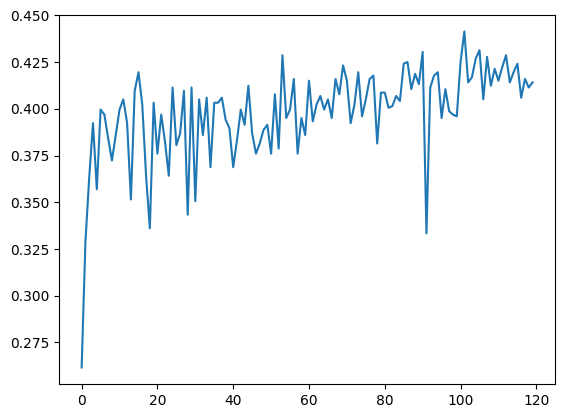

In [ ]:
# plot dev accuracies
plt.plot(pt_deep_cbow_accuracies)

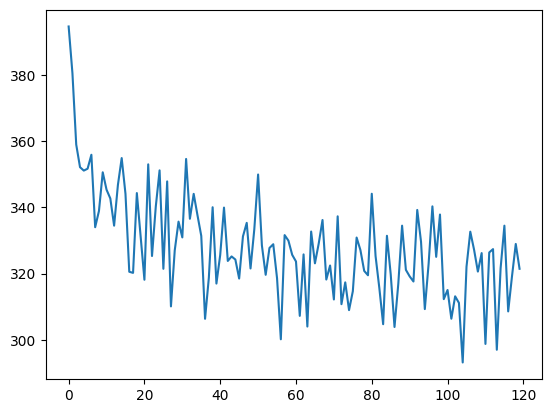

In [ ]:
# plot train loss
plt.plot(pt_deep_cbow_losses)

**It looks like we've hit what is possible with just using words.**
Let's move on by incorporating word order!

# LSTM

It is time to get more serious. Even with pre-trained word embeddings and multiple layers, we still seem to do pretty badly at sentiment classification.
The next step we can take is to introduce word order again, dropping our independence assumptions. In this way, we can get a representation of the sentence as an ordered set of tokens.

We will get this representation using a **Long Short-Term Memory** (LSTM). As an exercise, we will code our own LSTM cell, so that we get comfortable with its inner workings.
Once we have an LSTM cell, we can call it repeatedly, updating its hidden state one word at a time:

```python
rnn = MyLSTMCell(input_size, hidden_size)

hx = torch.zeros(1, hidden_size)  # initial hidden state
cx = torch.zeros(1, hidden_size)  # initial memory cell
output = []                       # to save intermediate LSTM states

# feed one word at a time
for i in range(n_timesteps):
  hx, cx = rnn(input[i], (hx, cx))
  output.append(hx)
```

If you need some more help understanding LSTMs, you can check out these resources:
- Blog post (highly recommended): http://colah.github.io/posts/2015-08-Understanding-LSTMs/
- Paper covering LSTM formulas in detail: https://arxiv.org/abs/1503.04069


#### Exercise: Finish the LSTM cell below.
You will need to implement the LSTM formulas:

$$
\begin{array}{ll}
        i = \sigma(W_{ii} x + b_{ii} + W_{hi} h + b_{hi}) \\
        f = \sigma(W_{if} x + b_{if} + W_{hf} h + b_{hf}) \\
        g = \tanh(W_{ig} x + b_{ig} + W_{hg} h + b_{hg}) \\
        o = \sigma(W_{io} x + b_{io} + W_{ho} h + b_{ho}) \\
        c' = f * c + i * g \\
        h' = o \tanh(c') \\
\end{array}
 $$

where $\sigma$ is the sigmoid function.

*Note that the LSTM formulas can differ slightly between different papers. We use the PyTorch LSTM formulation here.*

In [ ]:
import torch.nn.functional as F

class MyLSTMCell(nn.Module):
  """Our own LSTM cell"""

  def __init__(self, input_size, hidden_size, bias=True):
    """Creates the weights for this LSTM"""
    super(MyLSTMCell, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias

    # YOUR CODE HERE
    # Defining weight matrices and biases for the gates
    # self.W_ii = nn.Parameter(torch.Tensor(hidden_size, input_size))
    # self.W_hi = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
    # self.b_ii = nn.Parameter(torch.Tensor(hidden_size)) if bias else None
    # self.b_hi = nn.Parameter(torch.Tensor(hidden_size)) if bias else None

    # self.W_if = nn.Parameter(torch.Tensor(hidden_size, input_size))
    # self.W_hf = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
    # self.b_if = nn.Parameter(torch.Tensor(hidden_size)) if bias else None
    # self.b_hf = nn.Parameter(torch.Tensor(hidden_size)) if bias else None

    # self.W_ig = nn.Parameter(torch.Tensor(hidden_size, input_size))
    # self.W_hg = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
    # self.b_ig = nn.Parameter(torch.Tensor(hidden_size)) if bias else None
    # self.b_hg = nn.Parameter(torch.Tensor(hidden_size)) if bias else None

    # self.W_io = nn.Parameter(torch.Tensor(hidden_size, input_size))
    # self.W_ho = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
    # self.b_io = nn.Parameter(torch.Tensor(hidden_size)) if bias else None
    # self.b_ho = nn.Parameter(torch.Tensor(hidden_size)) if bias else None

    self.W_i = nn.Linear(self.input_size, 4 * self.hidden_size, self.bias)
    self.W_h = nn.Linear(self.hidden_size, 4 * self.hidden_size, self.bias)

    self.reset_parameters()

  def reset_parameters(self):
    """This is PyTorch's default initialization method"""
    stdv = 1.0 / math.sqrt(self.hidden_size)
    for weight in self.parameters():
      weight.data.uniform_(-stdv, stdv)

  def forward(self, input_, hx, mask=None):
    """
    input is (batch, input_size)
    hx is ((batch, hidden_size), (batch, hidden_size))
    """
    prev_h, prev_c = hx

    # project input and prev state
    # YOUR CODE HERE

    #raise NotImplementedError("Implement this")


    # main LSTM computation
    # i = torch.sigmoid(F.linear(input_, self.W_ii, self.b_ii) + F.linear(prev_h, self.W_hi, self.b_hi))
    # f = torch.sigmoid(F.linear(input_, self.W_if, self.b_if) + F.linear(prev_h, self.W_hf, self.b_hf))
    # g = torch.tanh(F.linear(input_, self.W_ig, self.b_ig) + F.linear(prev_h, self.W_hg, self.b_hg))
    # o = torch.sigmoid(F.linear(input_, self.W_io, self.b_io) + F.linear(prev_h, self.W_ho, self.b_ho))


    gates = self.W_i(input_) + self.W_h(prev_h)

    i_gate, f_gate, g_gate, o_gate = torch.chunk(gates, 4, dim=-1)

    i = torch.sigmoid(i_gate)
    f = torch.sigmoid(f_gate)
    g = torch.tanh(g_gate)
    o = torch.sigmoid(o_gate)

    c = f * prev_c + i * g
    h = o * torch.tanh(c)

    return h, c

  def __repr__(self):
    return "{}({:d}, {:d})".format(
        self.__class__.__name__, self.input_size, self.hidden_size)

#### Optional: Efficient Matrix Multiplication

It is more efficient to do a few big matrix multiplications than to do many smaller ones. So we will implement the above cell using just **two** linear layers.

This is possible because the eight linear transformations contained in one forward pass through an LSTM cell can be reduced to just two:
$$W_h h + b_h$$
$$W_i x + b_i $$

with $h = $ `prev_h` and $x = $ `input_`.

and where:

$W_h =  \begin{pmatrix}
W_{hi}\\
W_{hf}\\
W_{hg}\\
W_{ho}
\end{pmatrix}$, $b_h = \begin{pmatrix}
b_{hi}\\
b_{hf}\\
b_{hg}\\
b_{ho}
\end{pmatrix}$,  $W_i = \begin{pmatrix}
W_{ii}\\
W_{if}\\
W_{ig}\\
W_{io}
\end{pmatrix}$ and $b_i = \begin{pmatrix}
b_{ii}\\
b_{if}\\
b_{ig}\\
b_{io}
\end{pmatrix}$.

Convince yourself that, after chunking with [torch.chunk](https://pytorch.org/docs/stable/torch.html?highlight=chunk#torch.chunk), the output of those two linear transformations is equivalent to the output of the eight linear transformations in the LSTM cell calculations above.

#### LSTM Classifier

Having an LSTM cell is not enough: we still need some code that calls it repeatedly, and then makes a prediction from the final hidden state.
You will find that code below. Make sure that you understand it.

In [ ]:
class LSTMClassifier(nn.Module):
  """Encodes sentence with an LSTM and projects final hidden state"""

  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, vocab):
    super(LSTMClassifier, self).__init__()
    self.vocab = vocab
    self.hidden_dim = hidden_dim
    self.embed = nn.Embedding(vocab_size, embedding_dim, padding_idx=1)
    self.rnn = MyLSTMCell(embedding_dim, hidden_dim)

    self.output_layer = nn.Sequential(
        nn.Dropout(p=0.5),  # explained later
        nn.Linear(hidden_dim, output_dim)
    )

  def forward(self, x):

    B = x.size(0)  # batch size (this is 1 for now, i.e. 1 single example)
    T = x.size(1)  # timesteps (the number of words in the sentence)

    input_ = self.embed(x)

    # here we create initial hidden states containing zeros
    # we use a trick here so that, if input is on the GPU, then so are hx and cx
    hx = input_.new_zeros(B, self.rnn.hidden_size)
    cx = input_.new_zeros(B, self.rnn.hidden_size)

    # process input sentences one word/timestep at a time
    # input is batch-major (i.e., batch size is the first dimension)
    # so the first word(s) is (are) input_[:, 0]
    outputs = []
    for i in range(T):
      hx, cx = self.rnn(input_[:, i], (hx, cx))
      outputs.append(hx)

    # if we have a single example, our final LSTM state is the last hx
    if B == 1:
      final = hx
    else:
      #
      # This part is explained in next section, ignore this else-block for now.
      #
      # We processed sentences with different lengths, so some of the sentences
      # had already finished and we have been adding padding inputs to hx.
      # We select the final state based on the length of each sentence.

      # two lines below not needed if using LSTM from pytorch
      outputs = torch.stack(outputs, dim=0)           # [T, B, D]
      outputs = outputs.transpose(0, 1).contiguous()  # [B, T, D]

      # to be super-sure we're not accidentally indexing the wrong state
      # we zero out positions that are invalid
      pad_positions = (x == 1).unsqueeze(-1)

      outputs = outputs.contiguous()
      outputs = outputs.masked_fill_(pad_positions, 0.)

      mask = (x != 1)  # true for valid positions [B, T]
      lengths = mask.sum(dim=1)                 # [B, 1]

      indexes = (lengths - 1) + torch.arange(B, device=x.device, dtype=x.dtype) * T
      final = outputs.view(-1, self.hidden_dim)[indexes]  # [B, D]

    # we use the last hidden state to classify the sentence
    logits = self.output_layer(final)
    return logits

#### Dropout

Data sparsity and a small data set can cause *overfitting*. This is a phenomenom that is very likely to occur when training strong and expressive models, like LSTMs, on small data. In practice, if your model overfits, this means that it will be very good at predicting (or "remembering") the sentiment of the training set, but unable to generalise to new, unseen data in the test set. This is undesirable and one technique to mitigate this issue is *dropout*.

A dropout layer is defined by the following formula, which can be applied, for example, to a linear layer:

$$\text{tanh}(W(\mathbf{h}\odot \mathbf{d}) + \mathbf{b})$$

where $\mathbf{d} \in \{0, 1\}^n$, with $d_j \sim \text{Bernoulli}(p)$,

These formula simply means that we *drop* certain parameters during training (by setting them to zero). Which parameters we drop is stochastically determined by a Bernoulli distribution and the probability of each parameter being dropped is set to $p = 0.5$ in our experiments (see the previous cell of code where we define our output layer). A dropout layer can be applied at many different places in our models. This technique helps against the undesirable effect that a model relies on single parameters for prediction (e.g. if $h^{\prime}_j$ is large, always predict positive). If we use dropout, the model needs to learn to rely on different parameters, which is desirable to obtain better generalisation to unseen data.

**Let's train our LSTM!** Note that is will be a lot slower than previous models because we need to do many more computations per sentence.

#### Training

In [ ]:
lstm_model = LSTMClassifier(len(glove_v.w2i), 300, 168, len(t2i), glove_v)

# copy pre-trained word vectors into embeddings table
with torch.no_grad():
  lstm_model.embed.weight.data.copy_(torch.from_numpy(glove_vectors))
  lstm_model.embed.weight.requires_grad = False

print(lstm_model)
print_parameters(lstm_model)

lstm_model = lstm_model.to(device)
optimizer = optim.Adam(lstm_model.parameters(), lr=3e-4)

lstm_losses, lstm_accuracies = train_model(
    lstm_model, optimizer, num_iterations=30000,
    print_every=500, eval_every=500)

LSTMClassifier(
  (embed): Embedding(20727, 300, padding_idx=1)
  (rnn): MyLSTMCell(300, 168)
  (output_layer): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=168, out_features=5, bias=True)
  )
)
embed.weight             [20727, 300] requires_grad=False
rnn.W_i.weight           [672, 300]   requires_grad=True
rnn.W_i.bias             [672]        requires_grad=True
rnn.W_h.weight           [672, 168]   requires_grad=True
rnn.W_h.bias             [672]        requires_grad=True
output_layer.1.weight    [5, 168]     requires_grad=True
output_layer.1.bias      [5]          requires_grad=True

Total number of parameters: 6534785

Shuffling training data
Iter 500: loss=796.9751, time=10.85s
iter 500: dev acc=0.3043
new highscore
Iter 1000: loss=771.6318, time=25.13s
iter 1000: dev acc=0.2843
Iter 1500: loss=729.6859, time=41.25s
iter 1500: dev acc=0.3833
new highscore
Iter 2000: loss=716.8187, time=55.84s
iter 2000: dev acc=0.3915
new highscore
Iter 2500: lo

<ipython-input-34-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 24000: train acc=0.5298, dev acc=0.4723, test acc=0.4670


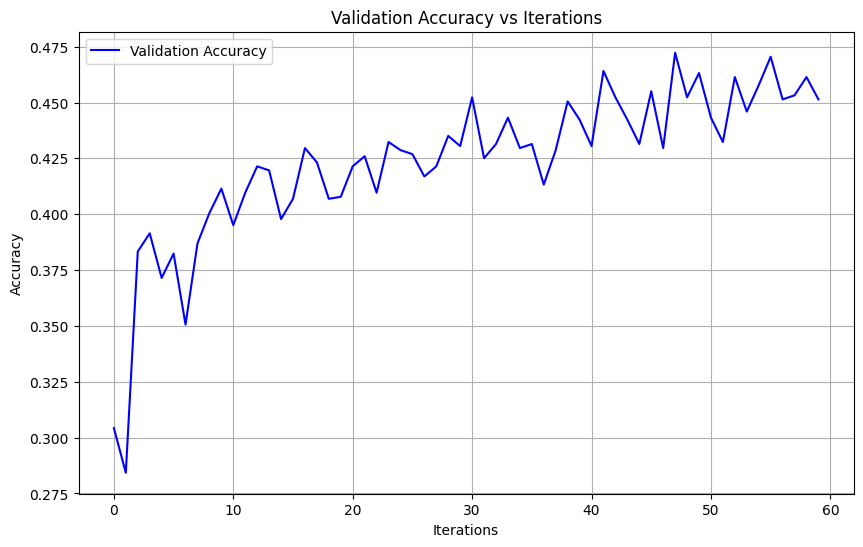

In [ ]:
# plot validation accuracy

plt.figure(figsize=(10, 6))
plt.plot(lstm_accuracies, label='Validation Accuracy', color='blue')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs Iterations')
plt.legend()
plt.grid(True)
plt.show()


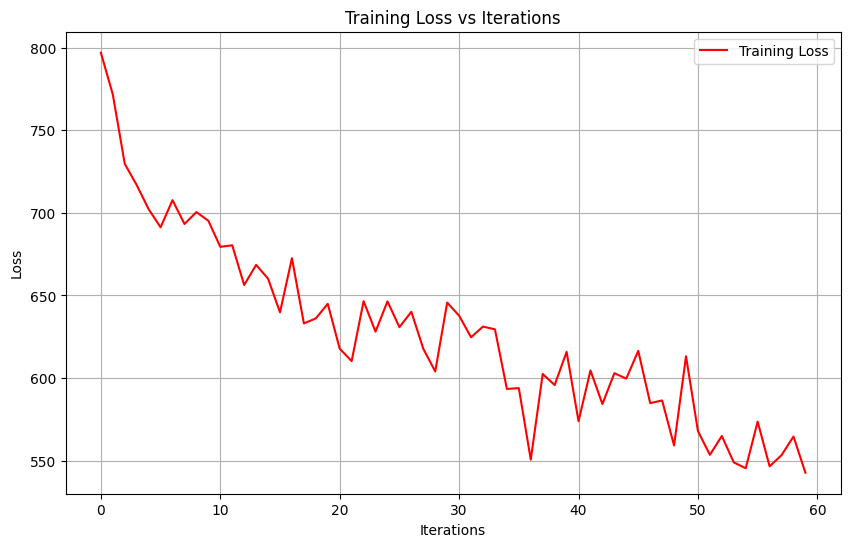

In [ ]:
# plot training loss

plt.figure(figsize=(10, 6))
plt.plot(lstm_losses, label='Training Loss', color='red')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss vs Iterations')
plt.legend()
plt.grid(True)
plt.show()

# Mini-batching



**Why is the LSTM so slow?** Despite our best efforts, we still need to make a lot of matrix multiplications per example (linear in the length of the example) just to get a single classification, and we can only process the 2nd word once we have computed the hidden state for the 1st word (sequential computation).

GPUs are more efficient if we do a few big matrix multiplications, rather than lots of small ones. If we could process multiple examples at the same time, then we could exploit that. That is, we could still process the input sequentially, but doing so for multiple sentences at the same time.

Up to now our "mini-batches" consisted of a single example. This was for a reason: the sentences in our data sets have **different lengths**, and this makes it difficult to process them at the same time.

Consider a batch of 2 sentences:

```
this movie is bad
this movie is super cool !
```

Let's say the IDs for these sentences are:

```
2 3 4 5
2 3 4 6 7 8
```

We cannot feed PyTorch an object with rows of variable length! We need to turn this into a matrix.

The solution is to add **padding values** to our mini-batch:

```
2 3 4 5 1 1
2 3 4 6 7 8
```

Whenever a sentence is shorter than the longest sentence in a mini-batch, we just use a padding value (here: 1) to fill the matrix.

In our computation, we should **ignore** the padding positions (e.g. mask them out) so that paddings do not contribute to the loss.

#### Mini-batch feed
We will now implement a `get_minibatch` function which will replace `get_example` and returns a mini-batch of the requested size.

In [ ]:
def get_minibatch(data, batch_size=25, shuffle=True):
  """Return minibatches, optional shuffling"""

  if shuffle:
    print("Shuffling training data")
    random.shuffle(data)  # shuffle training data each epoch

  batch = []

  # yield minibatches
  for example in data:
    batch.append(example)

    if len(batch) == batch_size:
      yield batch
      batch = []

  # in case there is something left
  if len(batch) > 0:
    yield batch

#### Padding function
We will need a function that adds padding 1s to a sequence of IDs so that
it becomes as long as the longest sequence in the minibatch.

In [ ]:
def pad(tokens, length, pad_value=1):
  """add padding 1s to a sequence to that it has the desired length"""
  return tokens + [pad_value] * (length - len(tokens))

# example
tokens = [2, 3, 4]
pad(tokens, 5)

[2, 3, 4, 1, 1]

#### New `prepare` function

We will also need a new function that turns a mini-batch into PyTorch tensors.

In [ ]:
def prepare_minibatch(mb, vocab):
  """
  Minibatch is a list of examples.
  This function converts words to IDs and returns
  torch tensors to be used as input/targets.
  """
  batch_size = len(mb)
  maxlen = max([len(ex.tokens) for ex in mb])

  # vocab returns 0 if the word is not there
  x = [pad([vocab.w2i.get(t, 0) for t in ex.tokens], maxlen) for ex in mb]

  x = torch.LongTensor(x)
  x = x.to(device)

  y = [ex.label for ex in mb]
  y = torch.LongTensor(y)
  y = y.to(device)

  return x, y

In [ ]:
# Let's test our new function.
# This should give us 3 examples.
mb = next(get_minibatch(train_data, batch_size=3, shuffle=False))
for ex in mb:
  print(ex)

Example(tokens=['The', 'Rock', 'is', 'destined', 'to', 'be', 'the', '21st', 'Century', "'s", 'new', '``', 'Conan', "''", 'and', 'that', 'he', "'s", 'going', 'to', 'make', 'a', 'splash', 'even', 'greater', 'than', 'Arnold', 'Schwarzenegger', ',', 'Jean-Claud', 'Van', 'Damme', 'or', 'Steven', 'Segal', '.'], tree=Tree('3', [Tree('2', [Tree('2', ['The']), Tree('2', ['Rock'])]), Tree('4', [Tree('3', [Tree('2', ['is']), Tree('4', [Tree('2', ['destined']), Tree('2', [Tree('2', [Tree('2', [Tree('2', [Tree('2', ['to']), Tree('2', [Tree('2', ['be']), Tree('2', [Tree('2', ['the']), Tree('2', [Tree('2', ['21st']), Tree('2', [Tree('2', [Tree('2', ['Century']), Tree('2', ["'s"])]), Tree('2', [Tree('3', ['new']), Tree('2', [Tree('2', ['``']), Tree('2', ['Conan'])])])])])])])]), Tree('2', ["''"])]), Tree('2', ['and'])]), Tree('3', [Tree('2', ['that']), Tree('3', [Tree('2', ['he']), Tree('3', [Tree('2', ["'s"]), Tree('3', [Tree('2', ['going']), Tree('3', [Tree('2', ['to']), Tree('4', [Tree('3', [Tree('

In [ ]:
# We should find padding 1s at the end
x, y = prepare_minibatch(mb, v)
print("x", x)
print("y", y)

x tensor([[  14, 1098,   10, 3554,    8,   27,    4, 2912, 3555,    9,  151,   60,
         5869,   61,    5,   11,   82,    9,  290,    8,   84,    6, 5870,   75,
         3556,   38, 1887, 2913,    3, 8737, 2139, 5871,   48,  828, 8738,    2,
            1,    1,    1],
        [  14, 2914, 2140, 5872,    7,   60,   14, 4473,    7,    4, 5873,   61,
         5874,   10,   49,  878,   11,    6, 5875,    7,  679,   65,   31, 3557,
         2141, 8739, 1099,  829,    9, 8740,  629,    7, 8741, 5876,    9, 8742,
            2,    1,    1],
        [8743, 5877, 2142, 8744,    6, 8745,    7, 1684,   33,    6,  171,  752,
         1269,    3,    6,  171,   37,  316, 8746,    8,    4,   52,   33,   17,
            4,  306, 3558,  377,  680,    4, 1021,    3, 4474,    3,  512,    7,
            4,  277,    2]])
y tensor([3, 4, 3])


#### Evaluate (mini-batch version)

We can now update our evaluation function to use mini-batches

In [ ]:
def evaluate(model, data,
             batch_fn=get_minibatch, prep_fn=prepare_minibatch,
             batch_size=16):
  """Accuracy of a model on given data set (using mini-batches)"""
  correct = 0
  total = 0
  model.eval()  # disable dropout

  for mb in batch_fn(data, batch_size=batch_size, shuffle=False):
    x, targets = prep_fn(mb, model.vocab)
    with torch.no_grad():
      logits = model(x)

    predictions = logits.argmax(dim=-1).view(-1)

    # add the number of correct predictions to the total correct
    correct += (predictions == targets.view(-1)).sum().item()
    total += targets.size(0)

  return correct, total, correct / float(total)

# LSTM (Mini-batched)

With this, let's run the LSTM again but now using mini-batches!

In [ ]:
lstm_model = LSTMClassifier(
    len(glove_v.w2i), 300, 168, len(t2i), glove_v)

# copy pre-trained vectors into embeddings table
with torch.no_grad():
  lstm_model.embed.weight.data.copy_(torch.from_numpy(glove_vectors))
  lstm_model.embed.weight.requires_grad = False

print(lstm_model)
print_parameters(lstm_model)

lstm_model = lstm_model.to(device)

batch_size = 25
optimizer = optim.Adam(lstm_model.parameters(), lr=2e-4)

lstm_losses, lstm_accuracies = train_model(
    lstm_model, optimizer, num_iterations=5000,
    print_every=40, eval_every=40,
    batch_size=batch_size,
    batch_fn=get_minibatch,
    prep_fn=prepare_minibatch,
    eval_fn=evaluate)

LSTMClassifier(
  (embed): Embedding(20727, 300, padding_idx=1)
  (rnn): MyLSTMCell(300, 168)
  (output_layer): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=168, out_features=5, bias=True)
  )
)
embed.weight             [20727, 300] requires_grad=False
rnn.W_i.weight           [672, 300]   requires_grad=True
rnn.W_i.bias             [672]        requires_grad=True
rnn.W_h.weight           [672, 168]   requires_grad=True
rnn.W_h.bias             [672]        requires_grad=True
output_layer.1.weight    [5, 168]     requires_grad=True
output_layer.1.bias      [5]          requires_grad=True

Total number of parameters: 6534785

Shuffling training data
Iter 40: loss=63.4344, time=2.85s
iter 40: dev acc=0.2743
new highscore
Iter 80: loss=62.6346, time=8.00s
iter 80: dev acc=0.2589
Iter 120: loss=62.3874, time=12.37s
iter 120: dev acc=0.3188
new highscore
Iter 160: loss=61.6406, time=16.15s
iter 160: dev acc=0.3379
new highscore
Iter 200: loss=62.3437, time=

<ipython-input-34-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 3840: train acc=0.5526, dev acc=0.4777, test acc=0.4566


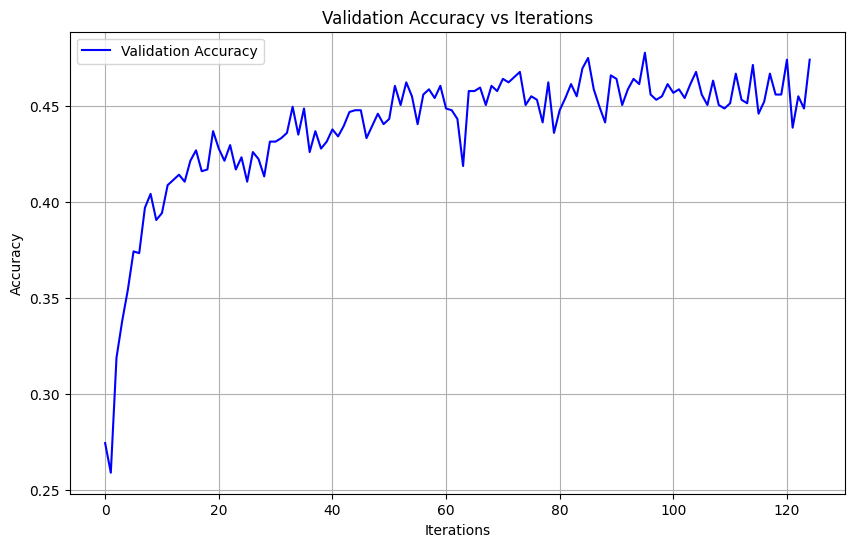

In [ ]:
# plot validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(lstm_accuracies, label='Validation Accuracy', color='blue')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs Iterations')
plt.legend()
plt.grid(True)
plt.show()

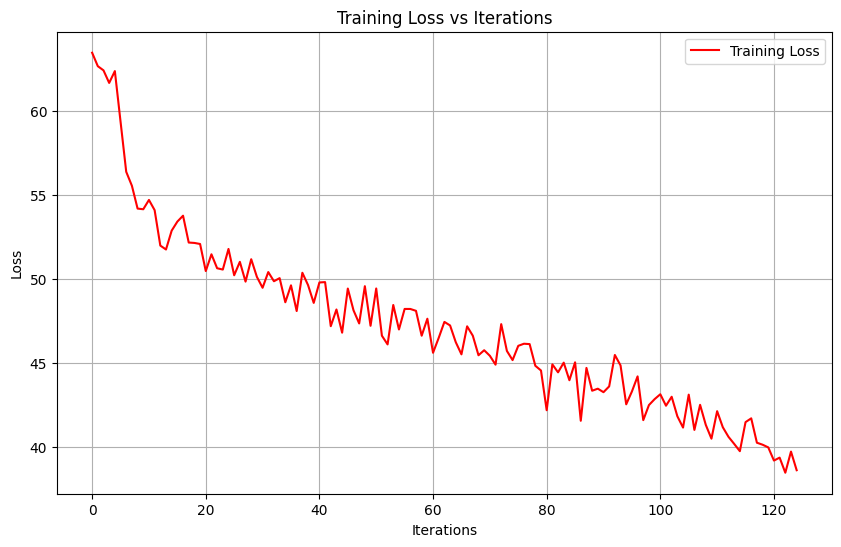

In [ ]:
# plot training loss
plt.figure(figsize=(10, 6))
plt.plot(lstm_losses, label='Training Loss', color='red')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss vs Iterations')
plt.legend()
plt.grid(True)
plt.show()

Fine-tuning word embeddings

In [ ]:
lstm_model = LSTMClassifier(
    len(glove_v.w2i), 300, 168, len(t2i), glove_v)

# Now fine-tune your embeddings together with the model
# YOUR CODE HERE
with torch.no_grad():
  lstm_model.embed.weight.data.copy_(torch.from_numpy(glove_vectors))
  lstm_model.embed.weight.requires_grad = True

print(lstm_model)
print_parameters(lstm_model)

lstm_model = lstm_model.to(device)

batch_size = 25
optimizer = optim.Adam(lstm_model.parameters(), lr=2e-4)

lstm_losses, lstm_accuracies = train_model(
    lstm_model, optimizer, num_iterations=3000,
    print_every=30, eval_every=30,
    batch_size=batch_size,
    batch_fn=get_minibatch,
    prep_fn=prepare_minibatch,
    eval_fn=evaluate)

LSTMClassifier(
  (embed): Embedding(20727, 300, padding_idx=1)
  (rnn): MyLSTMCell(300, 168)
  (output_layer): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=168, out_features=5, bias=True)
  )
)
embed.weight             [20727, 300] requires_grad=True
rnn.W_i.weight           [672, 300]   requires_grad=True
rnn.W_i.bias             [672]        requires_grad=True
rnn.W_h.weight           [672, 168]   requires_grad=True
rnn.W_h.bias             [672]        requires_grad=True
output_layer.1.weight    [5, 168]     requires_grad=True
output_layer.1.bias      [5]          requires_grad=True

Total number of parameters: 6534785

Shuffling training data
Iter 30: loss=47.7270, time=9.11s
iter 30: dev acc=0.2516
new highscore
Iter 60: loss=46.9535, time=21.07s
iter 60: dev acc=0.2688
new highscore
Iter 90: loss=46.9462, time=29.47s
iter 90: dev acc=0.3215
new highscore
Iter 120: loss=47.3526, time=35.63s
iter 120: dev acc=0.3025
Iter 150: loss=46.4450, time=43

<ipython-input-34-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 1410: train acc=0.6335, dev acc=0.4487, test acc=0.4520


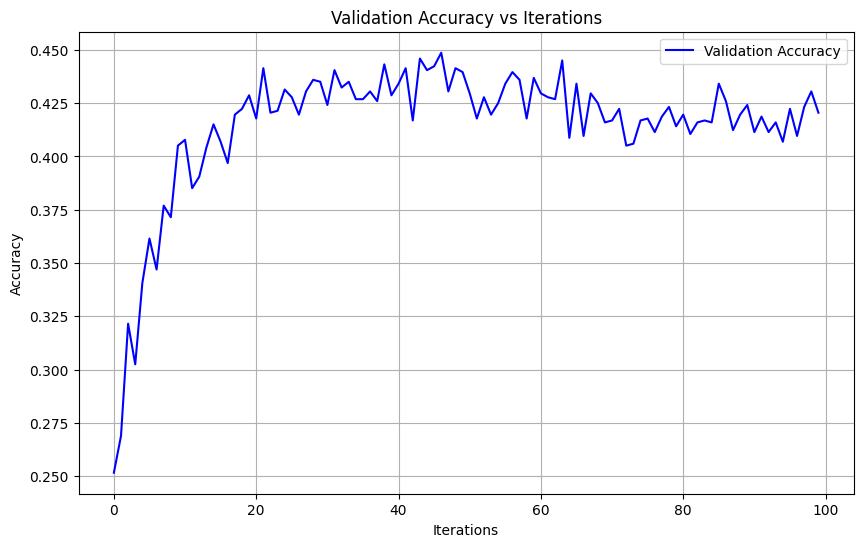

In [ ]:
# plot validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(lstm_accuracies, label='Validation Accuracy', color='blue')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs Iterations')
plt.legend()
plt.grid(True)
plt.show()

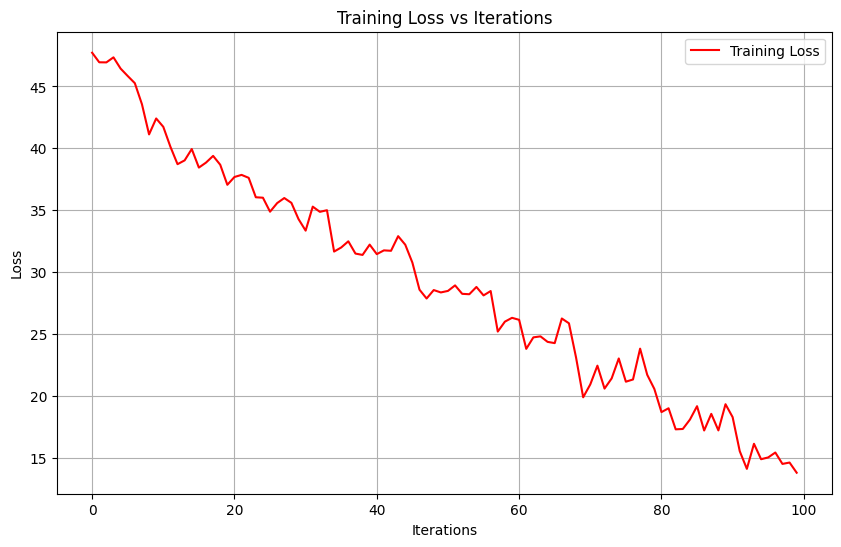

In [ ]:
# plot training loss
plt.figure(figsize=(10, 6))
plt.plot(lstm_losses, label='Training Loss', color='red')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss vs Iterations')
plt.legend()
plt.grid(True)
plt.show()

# Tree-LSTM

In the final part of this lab we will exploit the tree structure of the SST data.
Until now we only used the surface tokens, but remember that our data examples include binary trees with a sentiment score at every node.

In particular, we will implement **N-ary Tree-LSTMs** which are described in:

> Kai Sheng Tai, Richard Socher, and Christopher D. Manning. [Improved Semantic Representations From Tree-Structured Long Short-Term Memory Networks](http://aclweb.org/anthology/P/P15/P15-1150.pdf) ACL 2015.

Since our trees are binary (i.e., N=2), we can refer to these as *Binary Tree-LSTMs*. If you study equations (9) to (14) in the paper, you will find that they are not all too different from the original LSTM that you already have.

You should read this paper carefully and make sure that you understand the approach. You will also find our LSTM baseline there.
Note however that Tree-LSTMs were proposed around the same time by two other groups:

> Phong Le and Willem Zuidema. [Compositional distributional semantics with long short term memory](http://anthology.aclweb.org/S/S15/S15-1002.pdf). *SEM 2015.

> Xiaodan Zhu, Parinaz Sobihani,  and Hongyu Guo. [Long short-term memory over recursive structures](http://proceedings.mlr.press/v37/zhub15.pdf). ICML 2015.

It is good scientific practice to cite all three papers in your report.




## Computation

Do you remember the `transitions_from_treestring` function all the way in the beginning of this lab? Every example contains a **transition sequence** produced by this function. Let's look at it again:



In [ ]:
ex = next(examplereader("trees/dev.txt"))
print(TreePrettyPrinter(ex.tree))
print("Transitions:")
print(ex.transitions)

Note that the tree is **binary**. Every node has two children, except for pre-terminal nodes.

A tree like this can be described by a sequence of **SHIFT (0)** and **REDUCE (1)** actions.

To construct a tree, we can use the transitions as follows:
- **reverse** the sentence (a list of tokens) and call this the **buffer**
   - the first word is now on top (last in the list), and we would get it when calling pop() on the buffer
- create an empty list and call it the **stack**
- iterate through the transition sequence:
  - if it says SHIFT(0), we pop a word from the buffer, and push it to the stack
  - if it says REDUCE(1), we pop the **top two items** from the stack, and combine them (e.g. with a Tree-LSTM!), creating a new node that we push back on the stack
  
Convince yourself that going through the transition sequence above will result in the tree that you see.
For example, we would start by putting the following words on the stack (by shifting 5 times, starting with `It`):

```
Top of the stack:
-----------------
film
lovely
a
's  
It
```
Now we find a REDUCE in the transition sequence, so we get the top two words (film and lovely), and combine them, so our new stack becomes:
```
Top of the stack:
-----------------
lovely film
a
's  
It
```

We will use this approach when encoding sentences with our Tree-LSTM.
Now, our sentence is a reversed list of word embeddings.
When we shift, we move a word embedding to the stack.
When we reduce, we apply the Tree-LSTM to the top two vectors, and the result is a single vector that we put back on the stack.
After going through the whole transition sequence, we will have the root node on our stack! We can use that to classify the sentence.



## Obtaining the transition sequence



So what goes on in the `transitions_from_treestring` function?

The idea ([explained in this blog post](https://devblogs.nvidia.com/recursive-neural-networks-pytorch/)) is that, if we had a tree, we could traverse through the tree, and every time that we find a node containing only a word, we output a SHIFT.
Every time **after** we have finished visiting the children of a node, we output a REDUCE.
(What is this tree traversal called?)

However, our `transitions_from_treestring` function operates directly on the string representation. It works as follows.

We start with the representation:

```
(3 (2 It) (4 (4 (2 's) (4 (3 (2 a) (4 (3 lovely) (2 film))) (3 (2 with) (4 (3 (3 lovely) (2 performances)) (2 (2 by) (2 (2 (2 Buy) (2 and)) (2 Accorsi))))))) (2 .)))
```

First we remove pre-terminal nodes (and add spaces before closing brackets):

```
(3 It (4 (4 's (4 (3 a (4 lovely film ) ) (3 with (4 (3 lovely performances ) (2 by (2 (2 Buy and )  Accorsi ) ) ) ) ) ) . ) )
```

Then we remove node labels:

```
( It ( ( 's ( ( a ( lovely film ) ) ( with ( ( lovely performances) ( by ( ( Buy and )  Accorsi ) ) ) ) ) ) . ) )
```

Then we remove opening brackets:

```
It 's a lovely film ) ) with lovely performances ) by Buy and ) Accorsi ) ) ) ) ) ) . ) )
```

Now we replace words by S (for SHIFT), and closing brackets by R (for REDUCE):

```
S S S S S R R S S S R S S S R S R R R R R R S R R
0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1
```

Et voilà. We just obtained the transition sequence!

In [ ]:
# for comparison
seq = ex.transitions
s = " ".join(["S" if t == 0 else "R" for t in seq])
print(s)
print(" ".join(map(str, seq)))

S S R S S S R R R
0 0 1 0 0 0 1 1 1


## Coding the Tree-LSTM

The code below contains a Binary Tree-LSTM cell.
It is used in the TreeLSTM class below it, which in turn is used in the TreeLSTMClassifier.
The job of the TreeLSTM class is to encode a complete sentence and return the root node.
The job of the TreeLSTMCell is to return a new state when provided with two children (a reduce action). By repeatedly calling the TreeLSTMCell, the TreeLSTM will encode a sentence. This can be done for multiple sentences at the same time.


#### Exercise
Check the `forward` function and complete the Tree-LSTM formulas.
You can see that we defined a large linear layer for you, that projects the *concatenation* of the left and right child into the input gate, left forget gate, right forget gate, candidate, and output gate.

In [ ]:
class TreeLSTMCell(nn.Module):
  """A Binary Tree LSTM cell"""

  def __init__(self, input_size, hidden_size, bias=True, child_sum=False):
    """Creates the weights for this LSTM"""
    super(TreeLSTMCell, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias

    self.reduce_layer = nn.Linear(2 * hidden_size, 5 * hidden_size)
    self.dropout_layer = nn.Dropout(p=0.25)

    self.reset_parameters()

  def reset_parameters(self):
    """This is PyTorch's default initialization method"""
    stdv = 1.0 / math.sqrt(self.hidden_size)
    for weight in self.parameters():
      weight.data.uniform_(-stdv, stdv)

  def forward(self, hx_l, hx_r, mask=None):
    """
    hx_l is ((batch, hidden_size), (batch, hidden_size))
    hx_r is ((batch, hidden_size), (batch, hidden_size))
    """
    prev_h_l, prev_c_l = hx_l  # left child
    prev_h_r, prev_c_r = hx_r  # right child

    B = prev_h_l.size(0)

    # we concatenate the left and right children
    # you can also project from them separately and then sum
    children = torch.cat([prev_h_l, prev_h_r], dim=1)

    # project the combined children into a 5D tensor for i,fl,fr,g,o
    # this is done for speed, and you could also do it separately
    proj = self.reduce_layer(children)  # shape: B x 5D

    # each shape: B x D
    i, f_l, f_r, g, o = torch.chunk(proj, 5, dim=-1)

    # main Tree LSTM computation

    # YOUR CODE HERE
    # You only need to complete the commented lines below.

    # The shape of each of these is [batch_size, hidden_size]

    i = torch.sigmoid(i)
    f_l = torch.sigmoid(f_l)
    f_r = torch.sigmoid(f_r)
    g = torch.tanh(g)
    o = torch.sigmoid(o)

    c = i * g + f_l * prev_c_l + f_r * prev_c_r
    h = o * torch.tanh(c)

    return h, c

  def __repr__(self):
    return "{}({:d}, {:d})".format(
        self.__class__.__name__, self.input_size, self.hidden_size)

In [ ]:

class ChildSumTreeLSTMCell(nn.Module):
  def __init__(self, input_size, hidden_size, bias=True):
    """Creates the weights for this LSTM"""
    super(ChildSumTreeLSTMCell, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias

    self.i = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.f = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.o = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.g = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.dropout_layer = nn.Dropout(p=0.25)

    self.reset_parameters()

  def reset_parameters(self):
    """This is PyTorch's default initialization method"""
    stdv = 1.0 / math.sqrt(self.hidden_size)
    for weight in self.parameters():
      weight.data.uniform_(-stdv, stdv)

  def forward(self, hx_l, hx_r, mask=None):
    """
    hx_l is ((batch, hidden_size), (batch, hidden_size))
    hx_r is ((batch, hidden_size), (batch, hidden_size))
    """
    prev_h_l, prev_c_l = hx_l  # left child
    prev_h_r, prev_c_r = hx_r  # right child

    h_sum = prev_h_l + prev_h_r
    i = torch.sigmoid(self.i(h_sum))
    fl = torch.sigmoid(self.f(prev_h_l))
    fr = torch.sigmoid(self.f(prev_h_r))
    o = torch.sigmoid(self.o(h_sum))
    g = torch.tanh(self.g(h_sum))

    c = i * g + fl * prev_c_l + fr * prev_c_r
    h = o * torch.tanh(c)

    return h, c

  def __repr__(self):
    return "{}({:d}, {:d})".format(
        self.__class__.__name__, self.input_size, self.hidden_size)

## Explanation of the TreeLSTM class


The code below contains the TreeLSTM class, which implements everything we need in order to encode a sentence from word embeddings. The calculations are the same as in the paper, implemented such that the class `TreeLSTMCell` above is as general as possible and only takes two children to reduce them into a parent.


**Initialize $\mathbf{h}$ and $\mathbf{c}$ outside of the cell for the leaves**

At the leaves of each tree the children nodes are **empty**, whereas in higher levels the nodes are binary tree nodes that *do* have a left and right child (but no input $x$). By initializing the leaf nodes outside of the cell class (`TreeLSTMCell`), we avoid if-else statements in the forward pass.

The `TreeLSTM` class (among other things) pre-calculates an initial $h$ and $c$ for every word in the sentence. Since the initial left and right child are 0, the only calculations we need to do are based on $x$, and we can drop the forget gate calculation (`prev_c_l` and `prev_c_r` are zero). The calculations we do in order to initalize $h$ and $c$ are then:

$$
c_1 =  W^{(u)}x_1 \\
o_1 = \sigma (W^{(i)}x_1) \\
h_1 = o_1 \odot \text{tanh}(c_1)$$
*NB: note that these equations are chosen as initializations of $c$ and $h$, other initializations are possible and might work equally well.*

**Sentence Representations**

All our leaf nodes are now initialized, so we can start processing the sentence in its tree form. Each sentence is represented by a buffer (initially a list with a concatenation of $[h_1, c_1]$ for every word in the reversed sentence), a stack (initially an empty list) and a transition sequence. To encode our sentence, we construct the tree from its transition sequence as explained earlier.

*A short example that constructs a tree:*

We loop over the time dimension of the batched transition sequences (i.e. row by row), which contain values of 0's, 1's and 2's (representing SHIFT, REDUCE and padding respectively). If we have a batch of size 2 where the first example has a transition sequence given by [0, 0, 1, 0, 0, 0, 1] and the second by [0, 0, 1, 0, 0, 1], our transition batch will be given by the following two-dimensional numpy array:

$$
\text{transitions} =
\begin{pmatrix}
0 & 0\\
0 & 0\\
1 & 1\\
0 & 0\\
0 & 0\\
0 & 1\\
1 & 2
\end{pmatrix}
$$
The inner loop (`for transition, buffer, stack in zip(t_batch, buffers, stacks)`) goes over each example in the batch and updates its buffer and stack. The nested loop for this example will then do roughy the following:

```
Time = 0:  t_batch = [0, 0], the inner loop performs 2 SHIFTs.

Time = 1:  t_batch = [0, 0], ".."

Time = 2:  t_batch = [1, 1], causing the inner loop to fill the list child_l and child_r for both examples in the batch. Now the statement if child_l will return True, triggering a REDUCE action to be performed by our Tree LSTM cell with a batch size of 2.

Time = 3:  t_batch = [0, 0], "..".

Time = 4:  t_batch = [0, 0], ".."

Time = 5:  t_batch = [0, 1], one SHIFT will be done and another REDUCE action will be performed by our Tree LSTM, this time of batch size 1.  

Time = 6:  t_batch = [1, 2], triggering another REDUCE action with batch size 1.
```
*NB: note that this was an artificial example for the purpose of demonstrating parts of the code, the transition sequences do not necessarily represent actual trees.*

**Batching and Unbatching**

Within the body of the outer loop over time, we use the functions for batching and unbatching.

*Batching*

Before passing two lists of children to the reduce layer (an instance of `TreeLSTMCell`), we batch the children as they are at this point a list of tensors of variable length based on how many REDUCE actions there are to perform at a certain time step across the batch (let's call the length `L`). To do an efficient forward pass we want to transform the list to a pair of tensors of shape `([L, D], [L, D])`, which the function `batch` achieves.

*Unbatching*

In the same line where we batched the children, we unbatch the output of the forward pass to become a list of states of length `L` again. We do this because we need to loop over each example's transition at the current time step and push the children that are reduced into a parent to the stack.

*The batch and unbatch functions let us switch between the "PyTorch world" (Tensors) and the Python world (easy to manipulate lists).*


In [ ]:
# Helper functions for batching and unbatching states
# For speed we want to combine computations by batching, but
# for processing logic we want to turn the output into lists again
# to easily manipulate.

def batch(states):
  """
  Turns a list of states into a single tensor for fast processing.
  This function also chunks (splits) each state into a (h, c) pair"""
  return torch.cat(states, 0).chunk(2, 1)

def unbatch(state):
  """
  Turns a tensor back into a list of states.
  First, (h, c) are merged into a single state.
  Then the result is split into a list of sentences.
  """
  return torch.split(torch.cat(state, 1), 1, 0)

Take some time to understand the class below, having read the explanation above.

In [ ]:
class TreeLSTM(nn.Module):
  """Encodes a sentence using a TreeLSTMCell"""

  def __init__(self, input_size, hidden_size, bias=True, child_sum=False):
    """Creates the weights for this LSTM"""
    super(TreeLSTM, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias
    self.reduce = TreeLSTMCell(input_size, hidden_size) if not child_sum else ChildSumTreeLSTMCell(input_size, hidden_size)

    # project word to initial c
    self.proj_x = nn.Linear(input_size, hidden_size)
    self.proj_x_gate = nn.Linear(input_size, hidden_size)

    self.buffers_dropout = nn.Dropout(p=0.5)

  def forward(self, x, transitions):
    """
    WARNING: assuming x is reversed!
    :param x: word embeddings [B, T, E]
    :param transitions: [2T-1, B]
    :return: root states
    """

    B = x.size(0)  # batch size
    T = x.size(1)  # time

    # compute an initial c and h for each word
    # Note: this corresponds to input x in the Tai et al. Tree LSTM paper.
    # We do not handle input x in the TreeLSTMCell itself.
    buffers_c = self.proj_x(x)
    buffers_h = buffers_c.tanh()
    buffers_h_gate = self.proj_x_gate(x).sigmoid()
    buffers_h = buffers_h_gate * buffers_h

    # concatenate h and c for each word
    buffers = torch.cat([buffers_h, buffers_c], dim=-1)

    D = buffers.size(-1) // 2

    # we turn buffers into a list of stacks (1 stack for each sentence)
    # first we split buffers so that it is a list of sentences (length B)
    # then we split each sentence to be a list of word vectors
    buffers = buffers.split(1, dim=0)  # Bx[T, 2D]
    buffers = [list(b.squeeze(0).split(1, dim=0)) for b in buffers]  # BxTx[2D]

    # create B empty stacks
    stacks = [[] for _ in buffers]

    # t_batch holds 1 transition for each sentence
    for t_batch in transitions:

      child_l = []  # contains the left child for each sentence with reduce action
      child_r = []  # contains the corresponding right child

      # iterate over sentences in the batch
      # each has a transition t, a buffer and a stack
      for transition, buffer, stack in zip(t_batch, buffers, stacks):
        if transition == SHIFT:
          stack.append(buffer.pop())
        elif transition == REDUCE:
          assert len(stack) >= 2, \
            "Stack too small! Should not happen with valid transition sequences"
          child_r.append(stack.pop())  # right child is on top
          child_l.append(stack.pop())

      # if there are sentences with reduce transition, perform them batched
      if child_l:
        reduced = iter(unbatch(self.reduce(batch(child_l), batch(child_r))))
        for transition, stack in zip(t_batch, stacks):
          if transition == REDUCE:
            stack.append(next(reduced))

    final = [stack.pop().chunk(2, -1)[0] for stack in stacks]
    final = torch.cat(final, dim=0)  # tensor [B, D]

    return final

Just like the LSTM before, we will need an extra class that does the classifications.

In [ ]:
class TreeLSTMClassifier(nn.Module):
  """Encodes sentence with a TreeLSTM and projects final hidden state"""

  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, vocab, child_sum=False):
    super(TreeLSTMClassifier, self).__init__()
    self.vocab = vocab
    self.hidden_dim = hidden_dim
    self.embed = nn.Embedding(vocab_size, embedding_dim, padding_idx=1)
    self.treelstm = TreeLSTM(embedding_dim, hidden_dim, child_sum)
    self.output_layer = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(hidden_dim, output_dim, bias=True)
    )

  def forward(self, x):

    # x is a pair here of words and transitions; we unpack it here.
    # x is batch-major: [B, T], transitions is time major [2T-1, B]
    x, transitions = x
    emb = self.embed(x)

    # we use the root/top state of the Tree LSTM to classify the sentence
    root_states = self.treelstm(emb, transitions)

    # we use the last hidden state to classify the sentence
    logits = self.output_layer(root_states)
    return logits

## Special `prepare` function for Tree-LSTM

We need yet another `prepare` function. For our implementation, sentences need to be *reversed*. We will do that here.

In [ ]:
def prepare_treelstm_minibatch(mb, vocab):
  """
  Returns sentences reversed (last word first)
  Returns transitions together with the sentences.
  """
  batch_size = len(mb)
  maxlen = max([len(ex.tokens) for ex in mb])

  # vocab returns 0 if the word is not there
  # NOTE: reversed sequence!
  x = [pad([vocab.w2i.get(t, 0) for t in ex.tokens], maxlen)[::-1] for ex in mb]

  x = torch.LongTensor(x)
  x = x.to(device)

  y = [ex.label for ex in mb]
  y = torch.LongTensor(y)
  y = y.to(device)

  maxlen_t = max([len(ex.transitions) for ex in mb])
  transitions = [pad(ex.transitions, maxlen_t, pad_value=2) for ex in mb]
  transitions = np.array(transitions)
  transitions = transitions.T  # time-major

  return (x, transitions), y

## Training

In [ ]:
# Now let's train the Tree LSTM!

tree_model = TreeLSTMClassifier(
    len(glove_v.w2i), 300, 150, len(t2i), glove_v, child_sum=False)

print(len(v.w2i))

with torch.no_grad():
  tree_model.embed.weight.data.copy_(torch.from_numpy(glove_vectors))
  tree_model.embed.weight.requires_grad = False

def do_train(model):

  print(model)
  print_parameters(model)

  model = model.to(device)

  optimizer = optim.Adam(model.parameters(), lr=2e-4)

  return train_model(
      model, optimizer, num_iterations=5000,
      print_every=40, eval_every=40,
      prep_fn=prepare_treelstm_minibatch,
      eval_fn=evaluate,
      batch_fn=get_minibatch,
      batch_size=25, eval_batch_size=25)

results = do_train(tree_model)

18280
TreeLSTMClassifier(
  (embed): Embedding(20727, 300, padding_idx=1)
  (treelstm): TreeLSTM(
    (reduce): TreeLSTMCell(300, 150)
    (proj_x): Linear(in_features=300, out_features=150, bias=True)
    (proj_x_gate): Linear(in_features=300, out_features=150, bias=True)
    (buffers_dropout): Dropout(p=0.5, inplace=False)
  )
  (output_layer): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=150, out_features=5, bias=True)
  )
)
embed.weight             [20727, 300] requires_grad=False
treelstm.reduce.reduce_layer.weight [750, 300]   requires_grad=True
treelstm.reduce.reduce_layer.bias [750]        requires_grad=True
treelstm.proj_x.weight   [150, 300]   requires_grad=True
treelstm.proj_x.bias     [150]        requires_grad=True
treelstm.proj_x_gate.weight [150, 300]   requires_grad=True
treelstm.proj_x_gate.bias [150]        requires_grad=True
output_layer.1.weight    [5, 150]     requires_grad=True
output_layer.1.bias      [5]          requires_grad=T

<ipython-input-33-3a11a56da53a>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 3400: train acc=0.5494, dev acc=0.4687, test acc=0.4778


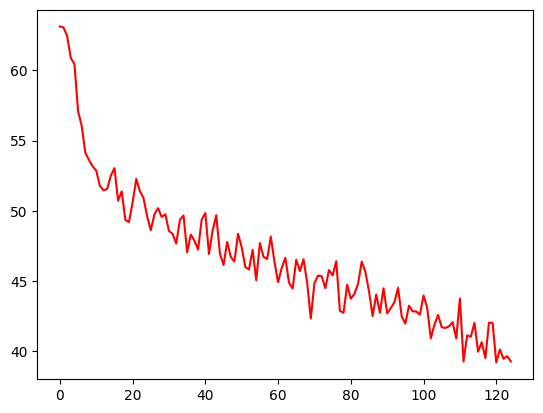

In [ ]:
plt.plot(results[0], label='Training Loss', color='red')

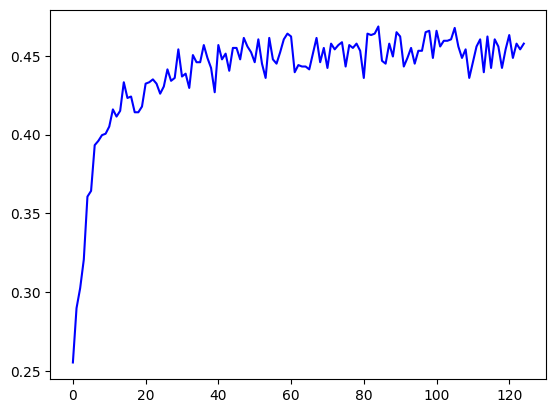

In [ ]:
plt.plot(results[1], label='Validation Accuracy', color='blue')

# Further experiments and report

For your report, you are expected to answer research questions by doing further experiments.

## Research Questions

Make sure you cover at least the following:

- How important is word order for this task?
- Does the tree structure help to get a better accuracy?
- How does performance depend on the sentence length? Compare the various models. Is there a model that does better on longer sentences? If so, why?
- Do you get better performance if you supervise the sentiment **at each node in the tree**? You can extract more training examples by treating every node in each tree as a separate tree. You will need to write a function that extracts all subtrees given a treestring.
    - Warning: NLTK's Tree function seems to result in invalid trees in some cases, so be careful if you want to parse the string to a tree structure before extraction the phrases.

**To be able to obtain a full grade (10), you should conduct further investigations.** For example, you can also investigate one the following:

- When making a wrong prediction, can you figure out at what point in the tree (sentence) the model fails? You can make a prediction at each node to investigate.
- How does N-ary Tree LSTM compare to the Child-Sum Tree LSTM?
- How do the Tai et al. Tree LSTMs compare to Le & Zuidema's formulation?
- Or... your own research question!

These examples should give you an idea of the expected scope of your further investigations. The maximum number of points awarded for these further investigations depends on the depth of your analysis, and can also be awarded for one of the further research questions already listed above.

In general:

- ***When you report numbers, please report the mean accuracy across 3 (or more) runs with different random seed, together with the standard deviation.*** This is because the final performance may vary per random seed.
More precisely, you should run each model with 3 different seeds, and for each of these 3 runs, evaluate the best model (according to the validation) on the test dataset. The validation dataset is used for finding the best model over iterations, but the accuracy you report should be on the test dataset.

## Report instructions

Your report needs to be written in LaTeX. You are required to use the ACL 2023 template which you can download from or edit directly on [Overleaf](https://www.overleaf.com/latex/templates/acl-2023-proceedings-template/qjdgcrdwcnwp). Make sure your names and student numbers are visible at the top. (Tip: you need to uncomment `\aclfinalcopy`).
You can find some general tips about writing a research paper [here](https://www.microsoft.com/en-us/research/academic-program/write-great-research-paper/), but note that you need to make your own judgment about what is appropriate for this project.

We expect you to use the following structure:
1. Introduction (~1 page) - describe the problem, your research questions and goals, a summary of your findings and contributions. Please cite related work (models, data set) as part of your introduction here, since this is a short paper.
    - Introduce the task and the main goal
    - Present your research questions
    - Motivate the importance of the questions
    - Present and explain your expectations
    - Make clear whether the research questions are addressed or not addressed in the literature
    - Describe the approach you use to answer the research questions
    - Summarise your findings
2. Background (~1/2-1 page) -
cover the main techniques ("building blocks") used in your project (e.g. word embeddings, LSTM, Tree-LSTM) and intuitions behind them. Be accurate and concise.
    - How does each technique work? (Don't just copy the formulas)
    - What is the relation between the techniques?
3. Models (~1/2 page) - Describe the architecture of the final models.
    - How do you use LSTM or Tree-LSTM for the sentiment classification task?
    - What layers do you have, how do you do classification?
    - What is your loss function?
    - Etc.
4. Experiments (~1/2 page) - Describe your experimental setup. This section should allow someone else to reproduce your experiments. Describe how you evaluate the models.
    - Task and the data
    - Training (model, data, parameters and hyper parameters, training algorithms, supervision signals, etc.)
    - Evaluation (e.g. metrics)
5. Results and Analysis (~1 page). Present the results and analyse your findings.
    - Answer each of the research questions you raised in the introduction.
    - Use figures and tables to highlight interesting patterns
    - What are the factors that make model A better than model B in task C? Investigate to prove their effect!
6. Conclusion (~1/4 page). Present the conclusions that can be drawn from your experiments.
    - What have you learned from you experiments?
    - How do your findings relate to what is already known in the literature?
    - Were the results as expected? Any surprising results? Why?
    - Based on what you learned, what would you suggest doing next?


General Tips:

- Math notation – define each variable (either in running text, or in a pseudo-legenda after or before the equation).
- Define technical terminology you need.
- Avoid colloquial language – everything can be said in a scientific-sounding way.
- Avoid lengthy sentences, stay to the point.
- Do not spend space on "obvious" things.
- Do not go over the page limit. (We will deduct points for that.)
- The page limit is 4 pages excluding references and appendix. This is a strict limit; points will be deducted for longer reports.
- There is no strict limit to references and appendix. However, the report needs to remain fully self-contained: the appendix should only include content that is not necessary to understand your work. For example, preprocessing decisions, model parameters, pseudocode, sample system inputs/outputs, and other details that are necessary for the exact replication of your work can be put into the appendix.


An ideal report:
- Precise, scientific, technical, to the point
  - Little general “waffle”/chit-chat
- Not boring – because you don’t explain obvious things too much
- Efficient delivery of (only) the facts that we need to know to understand/reimplement
- Results visually well-presented and described with the correct priority of importance of sub-results
- Insightful analysis – speculation should connect to something interesting and not be too much; the reader “learns something new”
- No typos, no colloquialisms – well-considered language
- This normally means several re-draftings (re-orderings of information)


# Further Experiments

## Imports and Dataset Creation

In [ ]:
import re
import random
import time
import math
import numpy as np
import nltk
import matplotlib.pyplot as plt
plt.style.use('default')
import torch
from torch import nn
from torch import optim
from google.colab import drive
from collections import namedtuple
from nltk import Tree
from collections import Counter, OrderedDict, defaultdict
import torch.nn.functional as F
import pickle

In [ ]:
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
cd /gdrive/My Drive/

/gdrive/My Drive


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
if torch.cuda.is_available():
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

cpu


In [ ]:
def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

In [ ]:
#!wget http://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip
#!unzip trainDevTestTrees_PTB.zip

--2024-12-05 15:26:52--  http://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip [following]
--2024-12-05 15:26:53--  https://nlp.stanford.edu/sentiment/trainDevTestTrees_PTB.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 789539 (771K) [application/zip]
Saving to: ‘trainDevTestTrees_PTB.zip.7’

trainDevTestTrees_P 100%[===================>] 771.03K   341KB/s    in 2.3s    

2024-12-05 15:26:55 (341 KB/s) - ‘trainDevTestTrees_PTB.zip.7’ saved [789539/789539]

Archive:  trainDevTestTrees_PTB.zip
replace trees/dev.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!wget https://gist.githubusercontent.com/bastings/b094de2813da58056a05e8e7950d4ad1/raw/3fbd3976199c2b88de2ae62afc0ecc6f15e6f7ce/glove.840B.300d.sst.txt
!cp "glove.840B.300d.sst.txt" "/gdrive/My Drive/"
!cp "/gdrive/My Drive/glove.840B.300d.sst.txt"

--2024-12-05 15:26:58--  https://gist.githubusercontent.com/bastings/b094de2813da58056a05e8e7950d4ad1/raw/3fbd3976199c2b88de2ae62afc0ecc6f15e6f7ce/glove.840B.300d.sst.txt
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53933315 (51M) [text/plain]
Saving to: ‘glove.840B.300d.sst.txt.7’

glove.840B.300d.sst 100%[===================>]  51.43M  48.6MB/s    in 1.1s    

2024-12-05 15:27:03 (48.6 MB/s) - ‘glove.840B.300d.sst.txt.7’ saved [53933315/53933315]

cp: 'glove.840B.300d.sst.txt' and '/gdrive/My Drive/glove.840B.300d.sst.txt' are the same file
cp: missing destination file operand after '/gdrive/My Drive/glove.840B.300d.sst.txt'
Try 'cp --help' for more information.


In [ ]:
def filereader(path):
  with open(path, mode="r", encoding="utf-8") as f:
    for line in f:
      yield line.strip().replace("\\","")

s = next(filereader("trees/dev.txt"))

In [ ]:
def tokens_from_treestring(s):
  """extract the tokens from a sentiment tree"""
  return re.sub(r"\([0-9] |\)", "", s).split()

# let's try it on our example tree
tokens = tokens_from_treestring(s)
print(tokens)
print(len(tokens))

SHIFT = 0
REDUCE = 1

def transitions_from_treestring(s):
  s = re.sub("\([0-5] ([^)]+)\)", "0", s)
  s = re.sub("\)", " )", s)
  s = re.sub("\([0-4] ", "", s)
  s = re.sub("\([0-4] ", "", s)
  s = re.sub("\)", "1", s)
  return list(map(int, s.split()))

for path in ("trees/train.txt", "trees/dev.txt", "trees/test.txt"):
  print("{:16s} {:4d}".format(path, sum(1 for _ in filereader(path))))

['It', "'s", 'a', 'lovely', 'film', 'with', 'lovely', 'performances', 'by', 'Buy', 'and', 'Accorsi', '.']
13
trees/train.txt  8544
trees/dev.txt    1101
trees/test.txt   2210


In [ ]:
# A simple way to define a class is using namedtuple.
Example = namedtuple("Example", ["tokens", "tree", "label", "transitions"])


def examplereader(path, lower=False):
  """Returns all examples in a file one by one."""
  for line in filereader(path):
    line = line.lower() if lower else line
    tokens = tokens_from_treestring(line)
    tree = Tree.fromstring(line)  # use NLTK's Tree
    label = int(line[1])
    trans = transitions_from_treestring(line)
    yield Example(tokens=tokens, tree=tree, label=label, transitions=trans)


# Let's load the data into memory.
LOWER = False  # we will keep the original casing
train_data = list(examplereader("trees/train.txt", lower=LOWER))
dev_data = list(examplereader("trees/dev.txt", lower=LOWER))
test_data = list(examplereader("trees/test.txt", lower=LOWER))

print("train", len(train_data))
print("dev", len(dev_data))
print("test", len(test_data))


train 8544
dev 1101
test 2210


In [ ]:
def extract_subtrees_from_string(tree_string):
    """
    Extracts all subtrees from a single tree string.
    """
    subtrees = []
    stack = []
    subtree_starts = []

    for i, char in enumerate(tree_string):
        if char == '(':
            stack.append(char)
            subtree_starts.append(i)
        elif char == ')':
            if stack:
                start_idx = subtree_starts.pop()
                subtree = tree_string[start_idx:i+1]
                subtrees.append(subtree)
                stack.pop()

    return subtrees

def extract_and_read_subtrees(path, lower=False):
    """
    Reads a file, extracts all subtrees for each tree in the file, and returns Examples.
    """
    def process_subtree(subtree):
        """Process a single subtree string into an Example."""
        tokens = tokens_from_treestring(subtree)
        tree = Tree.fromstring(subtree)
        label = int(subtree[1])
        transitions = transitions_from_treestring(subtree)
        return Example(tokens=tokens, tree=tree, label=label, transitions=transitions)

    for line in filereader(path):
        line = line.lower() if lower else line
        subtrees = extract_subtrees_from_string(line)
        for subtree in subtrees:
            yield process_subtree(subtree)


train_sub = list(extract_and_read_subtrees("trees/train.txt", lower=False))
print(f"Total subtrees in train set: {len(train_sub)}")

with open("trees/train.txt", "r") as f:
    first_tree_string = f.readline().strip()

print("\n Example Tree String:")
print(first_tree_string)
subtrees_1 = extract_subtrees_from_string(first_tree_string)

print("\nExtracted Subtrees:")
for i, subtree in enumerate(subtrees_1):
    print(f"Subtree {i + 1}: {subtree}")

Total subtrees in train set: 318582

 Example Tree String:
(3 (2 (2 The) (2 Rock)) (4 (3 (2 is) (4 (2 destined) (2 (2 (2 (2 (2 to) (2 (2 be) (2 (2 the) (2 (2 21st) (2 (2 (2 Century) (2 's)) (2 (3 new) (2 (2 ``) (2 Conan)))))))) (2 '')) (2 and)) (3 (2 that) (3 (2 he) (3 (2 's) (3 (2 going) (3 (2 to) (4 (3 (2 make) (3 (3 (2 a) (3 splash)) (2 (2 even) (3 greater)))) (2 (2 than) (2 (2 (2 (2 (1 (2 Arnold) (2 Schwarzenegger)) (2 ,)) (2 (2 Jean-Claud) (2 (2 Van) (2 Damme)))) (2 or)) (2 (2 Steven) (2 Segal))))))))))))) (2 .)))

Extracted Subtrees:
Subtree 1: (2 The)
Subtree 2: (2 Rock)
Subtree 3: (2 (2 The) (2 Rock))
Subtree 4: (2 is)
Subtree 5: (2 destined)
Subtree 6: (2 to)
Subtree 7: (2 be)
Subtree 8: (2 the)
Subtree 9: (2 21st)
Subtree 10: (2 Century)
Subtree 11: (2 's)
Subtree 12: (2 (2 Century) (2 's))
Subtree 13: (3 new)
Subtree 14: (2 ``)
Subtree 15: (2 Conan)
Subtree 16: (2 (2 ``) (2 Conan))
Subtree 17: (2 (3 new) (2 (2 ``) (2 Conan)))
Subtree 18: (2 (2 (2 Century) (2 's)) (2 (3 new) 

In [ ]:
class OrderedCounter(Counter, OrderedDict):
  """Counter that remembers the order elements are first seen"""
  def __repr__(self):
    return '%s(%r)' % (self.__class__.__name__,
                      OrderedDict(self))
  def __reduce__(self):
    return self.__class__, (OrderedDict(self),)


class Vocabulary:
  """A vocabulary, assigns IDs to tokens"""

  def __init__(self):
    self.freqs = OrderedCounter()
    self.w2i = {}
    self.i2w = []

  def count_token(self, t):
    self.freqs[t] += 1

  def add_token(self, t):
    self.w2i[t] = len(self.w2i)
    self.i2w.append(t)

  def build(self, min_freq=0):
    '''
    min_freq: minimum number of occurrences for a word to be included
              in the vocabulary
    '''
    self.add_token("<unk>")  # reserve 0 for <unk> (unknown words)
    self.add_token("<pad>")  # reserve 1 for <pad> (discussed later)

    tok_freq = list(self.freqs.items())
    tok_freq.sort(key=lambda x: x[1], reverse=True)
    for tok, freq in tok_freq:
      if freq >= min_freq:
        self.add_token(tok)

In [ ]:
v = Vocabulary()
for data_set in (train_data,):
  for ex in data_set:
    for token in ex.tokens:
      v.count_token(token)

v.build()
print("Vocabulary size:", len(v.w2i))

Vocabulary size: 18280


In [ ]:
def process_embeddings(embedding_file):
    v = Vocabulary()
    vectors = [np.random.randn(300), np.zeros(300)]

    v.add_token('<unk>')
    v.add_token('<pad>')

    with open(embedding_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word, embedding = parts[0], np.array(parts[1:], dtype=float)
            v.add_token(word)
            vectors.append(embedding)

    return v, np.stack(vectors, axis=0)

glove_v, glove_vectors = process_embeddings('glove.840B.300d.sst.txt')

print(glove_vectors.shape)
print(len(glove_v.w2i))


(20727, 300)
20727


In [ ]:
i2t = ["very negative", "negative", "neutral", "positive", "very positive"]
print(i2t)

t2i = OrderedDict({p : i for p, i in zip(i2t, range(len(i2t)))})
print(t2i)

['very negative', 'negative', 'neutral', 'positive', 'very positive']
OrderedDict([('very negative', 0), ('negative', 1), ('neutral', 2), ('positive', 3), ('very positive', 4)])


In [ ]:
sentence_lengths = [len(example.tokens) for example in test_data]

mean_length = np.mean(sentence_lengths)
median_length = np.median(sentence_lengths)


threshold = int(median_length)

short_sentences = [example for example in test_data if len(example.tokens) <= threshold]
long_sentences = [example for example in test_data if len(example.tokens) > threshold]

print(f"Threshold for short vs long sentences: {threshold}")
print(f"Number of short sentences: {len(short_sentences)}")
print(f"Number of long sentences: {len(long_sentences)}\n")


print("Short Sentences:")
for example in short_sentences[:3]:
    print(f"Tokens ({len(example.tokens)}):", example.tokens)

print("\nLong Sentences:")
for example in long_sentences[:3]:
    print(f"Tokens ({len(example.tokens)}):", example.tokens)


Threshold for short vs long sentences: 18
Number of short sentences: 1106
Number of long sentences: 1104

Short Sentences:
Tokens (4): ['Effective', 'but', 'too-tepid', 'biopic']
Tokens (9): ['Offers', 'that', 'rare', 'combination', 'of', 'entertainment', 'and', 'education', '.']
Tokens (7): ['But', 'he', 'somehow', 'pulls', 'it', 'off', '.']

Long Sentences:
Tokens (21): ['If', 'you', 'sometimes', 'like', 'to', 'go', 'to', 'the', 'movies', 'to', 'have', 'fun', ',', 'Wasabi', 'is', 'a', 'good', 'place', 'to', 'start', '.']
Tokens (23): ['Emerges', 'as', 'something', 'rare', ',', 'an', 'issue', 'movie', 'that', "'s", 'so', 'honest', 'and', 'keenly', 'observed', 'that', 'it', 'does', "n't", 'feel', 'like', 'one', '.']
Tokens (26): ['The', 'film', 'provides', 'some', 'great', 'insight', 'into', 'the', 'neurotic', 'mindset', 'of', 'all', 'comics', '--', 'even', 'those', 'who', 'have', 'reached', 'the', 'absolute', 'top', 'of', 'the', 'game', '.']


## Models

In [ ]:
# BoW model
class BOW(nn.Module):
  """A simple bag-of-words model"""

  def __init__(self, vocab_size, embedding_dim, vocab):
    super(BOW, self).__init__()
    self.vocab = vocab

    # this is a trainable look-up table with word embeddings
    self.embed = nn.Embedding(vocab_size, embedding_dim)

    # this is a trainable bias term
    self.bias = nn.Parameter(torch.zeros(embedding_dim), requires_grad=True)

  def forward(self, inputs):
    # this is the forward pas>s of the neural network
    # it applies a function to the input and returns the output

    # this looks up the embeddings for each word ID in inputs
    # the result is a sequence of word embeddings
    embeds = self.embed(inputs)

    # the output is the sum across the time dimension (1)
    # with the bias term added
    logits = embeds.sum(1) + self.bias

    return logits

In [ ]:
# CBoW model
class CBOW(nn.Module):
  """A simple bag-of-words model"""

  def __init__(self, vocab_size, embedding_dim, out_dim, vocab):
    super(CBOW, self).__init__()
    self.vocab = vocab

    # this is a trainable look-up table with word embeddings
    self.embed = nn.Embedding(vocab_size, embedding_dim)

    self.down_projection = nn.Linear(embedding_dim, out_dim)

  def forward(self, inputs):
    # this is the forward pass of the neural network
    # it applies a function to the input and returns the output

    # this looks up the embeddings for each word ID in inputs
    # the result is a sequence of word embeddings
    embeds = self.embed(inputs)

    # the output is the sum across the time dimension (1)
    # with the bias term added
    logits = self.down_projection(embeds.sum(1))

    return logits

In [ ]:
# Deep CBoW model
class DeepCBOW(nn.Module):
  """A simple bag-of-words model"""

  def __init__(self, vocab_size, E = 300, D = 100, output_classes = 5, vocab = None):
    super(DeepCBOW, self).__init__()
    self.vocab = vocab

    # this is a trainable look-up table with word embeddings
    self.embed = nn.Embedding(vocab_size, E)

    self.output_layer = nn.Sequential(
        nn.Linear(E, D),
        nn.Tanh(),
        nn.Linear(D, D),
        nn.Tanh(),
        nn.Linear(D, output_classes)
    )
  def forward(self, inputs):
    # this is the forward pass of the neural network
    # it applies a function to the input and returns the output

    # this looks up the embeddings for each word ID in inputs
    # the result is a sequence of word embeddings
    embeds = self.embed(inputs)

    # the output is the sum across the time dimension (1)
    # with the bias term added
    logits = self.output_layer(embeds.sum(1))

    return logits

In [ ]:
# Pre-Trained Deep CBoW model
class PTDeepCBOW(DeepCBOW):
  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, vocab):
    super(PTDeepCBOW, self).__init__(
        vocab_size, embedding_dim, hidden_dim, output_dim, vocab)

In [ ]:
# LSTM model
class MyLSTMCell(nn.Module):
  """Our own LSTM cell"""

  def __init__(self, input_size, hidden_size, bias=True):
    """Creates the weights for this LSTM"""
    super(MyLSTMCell, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias

    self.W_i = nn.Linear(self.input_size, 4 * self.hidden_size, self.bias)
    self.W_h = nn.Linear(self.hidden_size, 4 * self.hidden_size, self.bias)

    self.reset_parameters()

  def reset_parameters(self):
    """This is PyTorch's default initialization method"""
    stdv = 1.0 / math.sqrt(self.hidden_size)
    for weight in self.parameters():
      weight.data.uniform_(-stdv, stdv)

  def forward(self, input_, hx, mask=None):
    """
    input is (batch, input_size)
    hx is ((batch, hidden_size), (batch, hidden_size))
    """
    prev_h, prev_c = hx

    # project input and prev state

    gates = self.W_i(input_) + self.W_h(prev_h)

    i_gate, f_gate, g_gate, o_gate = torch.chunk(gates, 4, dim=-1)

    i = torch.sigmoid(i_gate)
    f = torch.sigmoid(f_gate)
    g = torch.tanh(g_gate)
    o = torch.sigmoid(o_gate)

    c = f * prev_c + i * g
    h = o * torch.tanh(c)

    return h, c

  def __repr__(self):
    return "{}({:d}, {:d})".format(
        self.__class__.__name__, self.input_size, self.hidden_size)


class LSTMClassifier(nn.Module):
  """Encodes sentence with an LSTM and projects final hidden state"""

  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, vocab):
    super(LSTMClassifier, self).__init__()
    self.vocab = vocab
    self.hidden_dim = hidden_dim
    self.embed = nn.Embedding(vocab_size, embedding_dim, padding_idx=1)
    self.rnn = MyLSTMCell(embedding_dim, hidden_dim)

    self.output_layer = nn.Sequential(
        nn.Dropout(p=0.5),  # explained later
        nn.Linear(hidden_dim, output_dim)
    )

  def forward(self, x):

    B = x.size(0)  # batch size (this is 1 for now, i.e. 1 single example)
    T = x.size(1)  # timesteps (the number of words in the sentence)

    input_ = self.embed(x)

    # here we create initial hidden states containing zeros
    # we use a trick here so that, if input is on the GPU, then so are hx and cx
    hx = input_.new_zeros(B, self.rnn.hidden_size)
    cx = input_.new_zeros(B, self.rnn.hidden_size)

    # process input sentences one word/timestep at a time
    # input is batch-major (i.e., batch size is the first dimension)
    # so the first word(s) is (are) input_[:, 0]
    outputs = []
    for i in range(T):
      hx, cx = self.rnn(input_[:, i], (hx, cx))
      outputs.append(hx)

    # if we have a single example, our final LSTM state is the last hx
    if B == 1:
      final = hx
    else:
      #
      # This part is explained in next section, ignore this else-block for now.
      #
      # We processed sentences with different lengths, so some of the sentences
      # had already finished and we have been adding padding inputs to hx.
      # We select the final state based on the length of each sentence.

      # two lines below not needed if using LSTM from pytorch
      outputs = torch.stack(outputs, dim=0)           # [T, B, D]
      outputs = outputs.transpose(0, 1).contiguous()  # [B, T, D]

      # to be super-sure we're not accidentally indexing the wrong state
      # we zero out positions that are invalid
      pad_positions = (x == 1).unsqueeze(-1)

      outputs = outputs.contiguous()
      outputs = outputs.masked_fill_(pad_positions, 0.)

      mask = (x != 1)  # true for valid positions [B, T]
      lengths = mask.sum(dim=1)                 # [B, 1]

      indexes = (lengths - 1) + torch.arange(B, device=x.device, dtype=x.dtype) * T
      final = outputs.view(-1, self.hidden_dim)[indexes]  # [B, D]

    # we use the last hidden state to classify the sentence
    logits = self.output_layer(final)
    return logits

In [ ]:
# Tree LSTM model
class TreeLSTMCell(nn.Module):
  """A Binary Tree LSTM cell"""

  def __init__(self, input_size, hidden_size, bias=True, child_sum=False):
    """Creates the weights for this LSTM"""
    super(TreeLSTMCell, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias

    self.reduce_layer = nn.Linear(2 * hidden_size, 5 * hidden_size)
    self.dropout_layer = nn.Dropout(p=0.25)

    self.reset_parameters()

  def reset_parameters(self):
    """This is PyTorch's default initialization method"""
    stdv = 1.0 / math.sqrt(self.hidden_size)
    for weight in self.parameters():
      weight.data.uniform_(-stdv, stdv)

  def forward(self, hx_l, hx_r, mask=None):
    """
    hx_l is ((batch, hidden_size), (batch, hidden_size))
    hx_r is ((batch, hidden_size), (batch, hidden_size))
    """
    prev_h_l, prev_c_l = hx_l  # left child
    prev_h_r, prev_c_r = hx_r  # right child

    B = prev_h_l.size(0)

    # we concatenate the left and right children
    # you can also project from them separately and then sum
    children = torch.cat([prev_h_l, prev_h_r], dim=1)

    # project the combined children into a 5D tensor for i,fl,fr,g,o
    # this is done for speed, and you could also do it separately
    proj = self.reduce_layer(children)  # shape: B x 5D

    # each shape: B x D
    i, f_l, f_r, g, o = torch.chunk(proj, 5, dim=-1)

    # main Tree LSTM computation

    # YOUR CODE HERE
    # You only need to complete the commented lines below.

    # The shape of each of these is [batch_size, hidden_size]

    i = torch.sigmoid(i)
    f_l = torch.sigmoid(f_l)
    f_r = torch.sigmoid(f_r)
    g = torch.tanh(g)
    o = torch.sigmoid(o)

    c = i * g + f_l * prev_c_l + f_r * prev_c_r
    h = o * torch.tanh(c)

    return h, c

  def __repr__(self):
    return "{}({:d}, {:d})".format(
        self.__class__.__name__, self.input_size, self.hidden_size)


class TreeLSTM(nn.Module):
  """Encodes a sentence using a TreeLSTMCell"""

  def __init__(self, input_size, hidden_size, bias=True, child_sum=False):
    """Creates the weights for this LSTM"""
    super(TreeLSTM, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias
    self.reduce = TreeLSTMCell(input_size, hidden_size) if not child_sum else ChildSumTreeLSTMCell(input_size, hidden_size)

    # project word to initial c
    self.proj_x = nn.Linear(input_size, hidden_size)
    self.proj_x_gate = nn.Linear(input_size, hidden_size)

    self.buffers_dropout = nn.Dropout(p=0.5)

  def forward(self, x, transitions):
    """
    WARNING: assuming x is reversed!
    :param x: word embeddings [B, T, E]
    :param transitions: [2T-1, B]
    :return: root states
    """

    B = x.size(0)  # batch size
    T = x.size(1)  # time

    # compute an initial c and h for each word
    # Note: this corresponds to input x in the Tai et al. Tree LSTM paper.
    # We do not handle input x in the TreeLSTMCell itself.
    buffers_c = self.proj_x(x)
    buffers_h = buffers_c.tanh()
    buffers_h_gate = self.proj_x_gate(x).sigmoid()
    buffers_h = buffers_h_gate * buffers_h

    # concatenate h and c for each word
    buffers = torch.cat([buffers_h, buffers_c], dim=-1)

    D = buffers.size(-1) // 2

    # we turn buffers into a list of stacks (1 stack for each sentence)
    # first we split buffers so that it is a list of sentences (length B)
    # then we split each sentence to be a list of word vectors
    buffers = buffers.split(1, dim=0)  # Bx[T, 2D]
    buffers = [list(b.squeeze(0).split(1, dim=0)) for b in buffers]  # BxTx[2D]

    # create B empty stacks
    stacks = [[] for _ in buffers]

    # t_batch holds 1 transition for each sentence
    for t_batch in transitions:

      child_l = []  # contains the left child for each sentence with reduce action
      child_r = []  # contains the corresponding right child

      # iterate over sentences in the batch
      # each has a transition t, a buffer and a stack
      for transition, buffer, stack in zip(t_batch, buffers, stacks):
        if transition == SHIFT:
          stack.append(buffer.pop())
        elif transition == REDUCE:
          assert len(stack) >= 2, \
            "Stack too small! Should not happen with valid transition sequences"
          child_r.append(stack.pop())  # right child is on top
          child_l.append(stack.pop())

      # if there are sentences with reduce transition, perform them batched
      if child_l:
        reduced = iter(unbatch(self.reduce(batch(child_l), batch(child_r))))
        for transition, stack in zip(t_batch, stacks):
          if transition == REDUCE:
            stack.append(next(reduced))

    final = [stack.pop().chunk(2, -1)[0] for stack in stacks]
    final = torch.cat(final, dim=0)  # tensor [B, D]

    return final


class TreeLSTMClassifier(nn.Module):
  """Encodes sentence with a TreeLSTM and projects final hidden state"""

  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, vocab, child_sum):
    super(TreeLSTMClassifier, self).__init__()
    self.vocab = vocab
    self.hidden_dim = hidden_dim
    self.embed = nn.Embedding(vocab_size, embedding_dim, padding_idx=1)
    self.treelstm = TreeLSTM(embedding_dim, hidden_dim, child_sum)
    self.output_layer = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(hidden_dim, output_dim, bias=True)
    )

  def forward(self, x):

    # x is a pair here of words and transitions; we unpack it here.
    # x is batch-major: [B, T], transitions is time major [2T-1, B]
    x, transitions = x
    emb = self.embed(x)

    # we use the root/top state of the Tree LSTM to classify the sentence
    root_states = self.treelstm(emb, transitions)

    # we use the last hidden state to classify the sentence
    logits = self.output_layer(root_states)
    return logits


In [ ]:
# Child Sum model
class ChildSumTreeLSTMCell(nn.Module):
  def __init__(self, input_size, hidden_size, bias=True):
    """Creates the weights for this LSTM"""
    super(ChildSumTreeLSTMCell, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias

    self.i = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.f = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.o = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.g = nn.Linear(hidden_size, hidden_size, bias=bias)
    self.dropout_layer = nn.Dropout(p=0.25)

    self.reset_parameters()

  def reset_parameters(self):
    """This is PyTorch's default initialization method"""
    stdv = 1.0 / math.sqrt(self.hidden_size)
    for weight in self.parameters():
      weight.data.uniform_(-stdv, stdv)

  def forward(self, hx_l, hx_r, mask=None):
    """
    hx_l is ((batch, hidden_size), (batch, hidden_size))
    hx_r is ((batch, hidden_size), (batch, hidden_size))
    """
    prev_h_l, prev_c_l = hx_l  # left child
    prev_h_r, prev_c_r = hx_r  # right child

    h_sum = prev_h_l + prev_h_r
    i = torch.sigmoid(self.i(h_sum))
    fl = torch.sigmoid(self.f(prev_h_l))
    fr = torch.sigmoid(self.f(prev_h_r))
    o = torch.sigmoid(self.o(h_sum))
    g = torch.tanh(self.g(h_sum))

    c = i * g + fl * prev_c_l + fr * prev_c_r
    h = o * torch.tanh(c)

    return h, c

  def __repr__(self):
    return "{}({:d}, {:d})".format(
        self.__class__.__name__, self.input_size, self.hidden_size)

## Experiments' Preparation

In [ ]:
def get_minibatch(data, batch_size=25, shuffle=True):
  """Return minibatches, optional shuffling"""

  if shuffle:
    print("Shuffling training data")
    random.shuffle(data)  # shuffle training data each epoch

  batch = []

  # yield minibatches
  for example in data:
    batch.append(example)

    if len(batch) == batch_size:
      yield batch
      batch = []

  # in case there is something left
  if len(batch) > 0:
    yield batch

In [ ]:
def batch(states):
  """
  Turns a list of states into a single tensor for fast processing.
  This function also chunks (splits) each state into a (h, c) pair"""
  return torch.cat(states, 0).chunk(2, 1)

def unbatch(state):
  """
  Turns a tensor back into a list of states.
  First, (h, c) are merged into a single state.
  Then the result is split into a list of sentences.
  """
  return torch.split(torch.cat(state, 1), 1, 0)

In [ ]:
def get_examples(data, shuffle=True, **kwargs):
  """Shuffle data set and return 1 example at a time (until nothing left)"""
  if shuffle:
    print("Shuffling training data")
    random.shuffle(data)  # shuffle training data each epoch
  for example in data:
    yield example

In [ ]:
def pad(tokens, length, pad_value=1):
  """add padding 1s to a sequence to that it has the desired length"""
  return tokens + [pad_value] * (length - len(tokens))

In [ ]:
def prepare_example(example, vocab):
  """
  Map tokens to their IDs for a single example
  """

  # vocab returns 0 if the word is not there (i2w[0] = <unk>)
  x = [vocab.w2i.get(t, 0) for t in example.tokens]

  x = torch.LongTensor([x])
  x = x.to(device)

  y = torch.LongTensor([example.label])
  y = y.to(device)

  return x, y

In [ ]:
def prepare_minibatch(mb, vocab):
  """
  Minibatch is a list of examples.
  This function converts words to IDs and returns
  torch tensors to be used as input/targets.
  """
  batch_size = len(mb)
  maxlen = max([len(ex.tokens) for ex in mb])

  # vocab returns 0 if the word is not there
  x = [pad([vocab.w2i.get(t, 0) for t in ex.tokens], maxlen) for ex in mb]

  x = torch.LongTensor(x)
  x = x.to(device)

  y = [ex.label for ex in mb]
  y = torch.LongTensor(y)
  y = y.to(device)

  return x, y

In [ ]:
def prepare_treelstm_minibatch(mb, vocab):
  """
  Returns sentences reversed (last word first)
  Returns transitions together with the sentences.
  """
  batch_size = len(mb)
  maxlen = max([len(ex.tokens) for ex in mb])

  # vocab returns 0 if the word is not there
  # NOTE: reversed sequence!
  x = [pad([vocab.w2i.get(t, 0) for t in ex.tokens], maxlen)[::-1] for ex in mb]

  x = torch.LongTensor(x)
  x = x.to(device)

  y = [ex.label for ex in mb]
  y = torch.LongTensor(y)
  y = y.to(device)

  maxlen_t = max([len(ex.transitions) for ex in mb])
  transitions = [pad(ex.transitions, maxlen_t, pad_value=2) for ex in mb]
  transitions = np.array(transitions)
  transitions = transitions.T  # time-major

  return (x, transitions), y

In [ ]:
def simple_evaluate(model, data, prep_fn=prepare_example, **kwargs):
  """Accuracy of a model on given data set."""
  correct = 0
  total = 0
  model.eval()  # disable dropout (explained later)

  for example in data:

    # convert the example input and label to PyTorch tensors
    x, target = prep_fn(example, model.vocab)

    # forward pass without backpropagation (no_grad)
    # get the output from the neural network for input x
    with torch.no_grad():
      logits = model(x)

    # get the prediction
    prediction = logits.argmax(dim=-1)

    # add the number of correct predictions to the total correct
    correct += (prediction == target).sum().item()
    total += 1

  return correct, total, correct / float(total)


def evaluate(model, data,
             batch_fn=get_minibatch, prep_fn=prepare_minibatch,
             batch_size=16):
  """Accuracy of a model on given data set (using mini-batches)"""
  correct = 0
  total = 0
  model.eval()  # disable dropout

  for mb in batch_fn(data, batch_size=batch_size, shuffle=False):
    x, targets = prep_fn(mb, model.vocab)
    with torch.no_grad():
      logits = model(x)

    predictions = logits.argmax(dim=-1).view(-1)

    # add the number of correct predictions to the total correct
    correct += (predictions == targets.view(-1)).sum().item()
    total += targets.size(0)

  return correct, total, correct / float(total)

In [ ]:
def evaluate_all_models(models, data, eval_fn=simple_evaluate, batch_fn=None,
                         prep_fn=None, batch_size=None):
    """
    Evaluate all models on the given data sets.

    """
    results = []
    for model in models:
        model_res = []
        for data_set in data:
            if batch_fn and prep_fn and batch_size:
                correct, total, accuracy = eval_fn(
                    model, data_set, batch_fn=batch_fn, prep_fn=prep_fn, batch_size=batch_size
                )
            else:
                correct, total, accuracy = eval_fn(model, data_set)
            model_res.append(accuracy)
        results.append(model_res)
    return results


In [ ]:
def train_model(model, optimizer, num_iterations=10000,
                print_every=1000, eval_every=1000,
                batch_fn=get_examples,
                prep_fn=prepare_example,
                eval_fn=simple_evaluate,
                batch_size=1, eval_batch_size=None, data=train_data):
  """Train a model."""
  iter_i = 0
  train_loss = 0.
  print_num = 0
  start = time.time()
  criterion = nn.CrossEntropyLoss() # loss function
  best_eval = 0.
  best_iter = 0

  # store train loss and validation accuracy during training
  # so we can plot them afterwards
  losses = []
  accuracies = []

  if eval_batch_size is None:
    eval_batch_size = batch_size

  while True:  # when we run out of examples, shuffle and continue
    for batch in batch_fn(train_data, batch_size=batch_size):

      # forward pass
      model.train()
      x, targets = prep_fn(batch, model.vocab)
      logits = model(x)

      B = targets.size(0)  # later we will use B examples per update

      # compute cross-entropy loss (our criterion)
      # note that the cross entropy loss function computes the softmax for us
      loss = criterion(logits.view([B, -1]), targets.view(-1))
      train_loss += loss.item()

      # backward pass (tip: check the Introduction to PyTorch notebook)
      # erase previous gradients
      #raise NotImplementedError("Implement this")
      # YOUR CODE HERE
      optimizer.zero_grad()

      # compute gradients
      # YOUR CODE HERE
      loss.backward()
      # update weights - take a small step in the opposite dir of the gradient
      # YOUR CODE HERE
      optimizer.step()

      print_num += 1
      iter_i += 1

      # print info
      if iter_i % print_every == 0:
        print("Iter %r: loss=%.4f, time=%.2fs" %
              (iter_i, train_loss, time.time()-start))
        losses.append(train_loss)
        print_num = 0
        train_loss = 0.

      # evaluate
      if iter_i % eval_every == 0:
        _, _, accuracy = eval_fn(model, dev_data, batch_size=eval_batch_size,
                                 batch_fn=batch_fn, prep_fn=prep_fn)
        accuracies.append(accuracy)
        print("iter %r: dev acc=%.4f" % (iter_i, accuracy))

        # save best model parameters
        if accuracy > best_eval:
          print("new highscore")
          best_eval = accuracy
          best_iter = iter_i
          path = "{}.pt".format(model.__class__.__name__)
          ckpt = {
              "state_dict": model.state_dict(),
              "optimizer_state_dict": optimizer.state_dict(),
              "best_eval": best_eval,
              "best_iter": best_iter
          }
          torch.save(ckpt, path)

      # done training
      if iter_i == num_iterations:
        print("Done training")

        # evaluate on train, dev, and test with best model
        print("Loading best model")
        path = "{}.pt".format(model.__class__.__name__)
        ckpt = torch.load(path)
        model.load_state_dict(ckpt["state_dict"])

        _, _, train_acc = eval_fn(
            model, train_data, batch_size=eval_batch_size,
            batch_fn=batch_fn, prep_fn=prep_fn)
        _, _, dev_acc = eval_fn(
            model, dev_data, batch_size=eval_batch_size,
            batch_fn=batch_fn, prep_fn=prep_fn)
        _, _, test_acc = eval_fn(
            model, test_data, batch_size=eval_batch_size,
            batch_fn=batch_fn, prep_fn=prep_fn)

        print("best model iter {:d}: "
              "train acc={:.4f}, dev acc={:.4f}, test acc={:.4f}".format(
                  best_iter, train_acc, dev_acc, test_acc))

        return losses, dev_acc, test_acc

In [ ]:
def train_seeds(seeds, model_class, lr, *model_args, pretrained_embeddings=None, freeze_embeddings=False, **train_args):
    """
    Train a model for each seed and return models, losses, dev accuracies, and test accuracies.
    """
    models = []
    all_losses = []
    all_dev_accs = []
    all_test_accs = []

    for seed in seeds:
        print(f"\nTraining with seed {seed}...")
        set_seed(seed)
        model = model_class(*model_args)

        if pretrained_embeddings is not None:
            print("Loading pre-trained embeddings...")
            model.embed.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
            model.embed.weight.requires_grad = not freeze_embeddings

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        losses, dev_accs, test_accs = train_model(
            model, optimizer,
            **train_args
        )

        models.append(model)
        all_losses.append(losses)
        all_dev_accs.append(dev_accs)
        all_test_accs.append(test_accs)

    return models, all_losses, all_dev_accs, all_test_accs

In [ ]:
def mean_std(info):
  info = np.array(info)
  means= np.mean(info, axis=0)
  stds = np.std(info, axis=0)
  return means, stds

## Experiments

### BOW

In [ ]:
#bow
seeds = [0, 42, 123]
models_bow, all_losses_bow, all_dev_accs_bow, all_test_accs_bow = train_seeds(seeds, BOW, 0.0005, len(v.w2i), len(t2i), v, num_iterations=30000, print_every=1000, eval_every=1000)

loss_means_bow, loss_stds_bow = mean_std(all_losses_bow)
dev_acc_means_bow, dev_acc_stds_bow = mean_std(all_dev_accs_bow)
test_acc_means_bow, test_acc_stds_bow = mean_std(all_test_accs_bow)

short_accs_bow = evaluate_all_models(models_bow, [short_sentences])
long_accs_bow = evaluate_all_models(models_bow, [long_sentences])

short_acc_means_bow, short_acc_stds_bow = mean_std(short_accs_bow)
long_acc_means_bow, long_acc_stds_bow = mean_std(long_accs_bow)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_bow}")
print(f"Standard deviation losses: {loss_stds_bow}")
print(f"Mean dev accuracies: {dev_acc_means_bow}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_bow}")
print(f"Mean test accuracies: {test_acc_means_bow}")
print(f"Standard deviation test accuracies: {test_acc_stds_bow}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_bow}")
print(f"    Standard deviation: {short_acc_stds_bow}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_bow}")
print(f"    Standard deviation: {long_acc_stds_bow}")


Training with seed 0...
Shuffling training data
Iter 1000: loss=5887.2240, time=2.03s
iter 1000: dev acc=0.1889
new highscore
Iter 2000: loss=5599.4033, time=4.40s
iter 2000: dev acc=0.1953
new highscore
Iter 3000: loss=5235.8172, time=6.99s
iter 3000: dev acc=0.1998
new highscore
Iter 4000: loss=4656.1818, time=9.97s
iter 4000: dev acc=0.2107
new highscore
Iter 5000: loss=4723.8163, time=14.70s
iter 5000: dev acc=0.2134
new highscore
Iter 6000: loss=4464.1820, time=17.57s
iter 6000: dev acc=0.2153
new highscore
Iter 7000: loss=4477.2147, time=20.47s
iter 7000: dev acc=0.2162
new highscore
Iter 8000: loss=4534.3706, time=23.31s
iter 8000: dev acc=0.2134
Shuffling training data
Iter 9000: loss=4276.6309, time=26.95s
iter 9000: dev acc=0.2162
Iter 10000: loss=4048.7445, time=30.04s
iter 10000: dev acc=0.2216
new highscore
Iter 11000: loss=4052.8325, time=32.88s
iter 11000: dev acc=0.2271
new highscore
Iter 12000: loss=3906.6551, time=35.68s
iter 12000: dev acc=0.2289
new highscore
Iter 

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 30000: train acc=0.3088, dev acc=0.2470, test acc=0.2353

Training with seed 42...
Shuffling training data
Iter 1000: loss=5116.6530, time=1.87s
iter 1000: dev acc=0.1889
new highscore
Iter 2000: loss=4973.3967, time=4.52s
iter 2000: dev acc=0.1926
new highscore
Iter 3000: loss=4948.6680, time=8.19s
iter 3000: dev acc=0.1926
Iter 4000: loss=4549.3483, time=11.04s
iter 4000: dev acc=0.1907
Iter 5000: loss=4487.7678, time=13.85s
iter 5000: dev acc=0.1989
new highscore
Iter 6000: loss=4458.0555, time=16.69s
iter 6000: dev acc=0.2016
new highscore
Iter 7000: loss=4451.2664, time=19.82s
iter 7000: dev acc=0.2044
new highscore
Iter 8000: loss=4337.0679, time=23.36s
iter 8000: dev acc=0.2062
new highscore
Shuffling training data
Iter 9000: loss=4177.5258, time=26.18s
iter 9000: dev acc=0.2071
new highscore
Iter 10000: loss=3928.7406, time=28.95s
iter 10000: dev acc=0.2089
new highscore
Iter 11000: loss=4167.3452, time=31.70s
iter 11000: dev acc=0.2107
new highscore
Iter 12000:

In [ ]:
results_bow = {
    "test_acc_means_bow": test_acc_means_bow,
    "test_acc_stds_bow": test_acc_stds_bow,
    "short_acc_means_bow": short_acc_means_bow,
    "short_acc_stds_bow": short_acc_stds_bow,
    "long_acc_means_bow": long_acc_means_bow,
    "long_acc_stds_bow": long_acc_stds_bow,
}

with open("bow_results.pkl", "wb") as f:
    pickle.dump(results_bow, f)

print("Variables saved successfully to bow_results.pkl")

Variables saved successfully to bow_results.pkl


### CBOW


In [ ]:
#cbow
seeds = [0, 42, 123]
models_cbow, all_losses_cbow, all_dev_accs_cbow, all_test_accs_cbow = train_seeds(seeds, CBOW, 0.0005, len(v.w2i), 300, len(t2i), v, num_iterations=30000, print_every=1000, eval_every=1000)

loss_means_cbow, loss_stds_cbow = mean_std(all_losses_cbow)
dev_acc_means_cbow, dev_acc_stds_cbow = mean_std(all_dev_accs_cbow)
test_acc_means_cbow, test_acc_stds_cbow = mean_std(all_test_accs_cbow)

short_accs_cbow = evaluate_all_models(models_cbow, [short_sentences])
long_accs_cbow = evaluate_all_models(models_cbow, [long_sentences])

short_acc_means_cbow, short_acc_stds_cbow = mean_std(short_accs_cbow)
long_acc_means_cbow, long_acc_stds_cbow = mean_std(long_accs_cbow)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_cbow}")
print(f"Standard deviation losses: {loss_stds_cbow}")
print(f"Mean dev accuracies: {dev_acc_means_cbow}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_cbow}")
print(f"Mean test accuracies: {test_acc_means_cbow}")
print(f"Standard deviation test accuracies: {test_acc_stds_cbow}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_cbow}")
print(f"    Standard deviation: {short_acc_stds_cbow}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_cbow}")
print(f"    Standard deviation: {long_acc_stds_cbow}")


Training with seed 0...
Shuffling training data
Iter 1000: loss=2719.9321, time=120.32s
iter 1000: dev acc=0.2579
new highscore
Iter 2000: loss=2274.3326, time=248.61s
iter 2000: dev acc=0.2816
new highscore
Iter 3000: loss=2133.4403, time=375.83s
iter 3000: dev acc=0.2888
new highscore
Iter 4000: loss=1990.0246, time=506.43s
iter 4000: dev acc=0.2861
Iter 5000: loss=1911.4724, time=641.67s
iter 5000: dev acc=0.2688
Iter 6000: loss=2008.6614, time=788.96s
iter 6000: dev acc=0.2870
Iter 7000: loss=1900.6097, time=932.30s
iter 7000: dev acc=0.2979
new highscore
Iter 8000: loss=1870.5734, time=1077.26s
iter 8000: dev acc=0.2852
Shuffling training data
Iter 9000: loss=1729.8377, time=1222.36s
iter 9000: dev acc=0.2952
Iter 10000: loss=1618.8955, time=1369.32s
iter 10000: dev acc=0.2598
Iter 11000: loss=1582.1219, time=1516.12s
iter 11000: dev acc=0.3115
new highscore
Iter 12000: loss=1683.3036, time=1663.21s
iter 12000: dev acc=0.3134
new highscore
Iter 13000: loss=1606.1290, time=1809.91

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 29000: train acc=0.7004, dev acc=0.3542, test acc=0.3606

Training with seed 42...
Shuffling training data
Iter 1000: loss=2682.4844, time=116.25s
iter 1000: dev acc=0.2062
new highscore
Iter 2000: loss=2281.2178, time=235.26s
iter 2000: dev acc=0.2425
new highscore
Iter 3000: loss=2050.1156, time=362.14s
iter 3000: dev acc=0.2589
new highscore
Iter 4000: loss=1961.2875, time=493.95s
iter 4000: dev acc=0.2670
new highscore
Iter 5000: loss=1942.0423, time=630.77s
iter 5000: dev acc=0.2607
Iter 6000: loss=1930.5038, time=768.42s
iter 6000: dev acc=0.3070
new highscore
Iter 7000: loss=1853.7063, time=910.12s
iter 7000: dev acc=0.2507
Iter 8000: loss=1928.3956, time=1052.31s
iter 8000: dev acc=0.2516
Shuffling training data
Iter 9000: loss=1791.7883, time=1198.37s
iter 9000: dev acc=0.2979
Iter 10000: loss=1594.7724, time=1345.22s
iter 10000: dev acc=0.3134
new highscore
Iter 11000: loss=1600.0904, time=1492.36s
iter 11000: dev acc=0.3206
new highscore
Iter 12000: loss=1655

In [ ]:
results_cbow = {
    "test_acc_means_cbow": test_acc_means_cbow,
    "test_acc_stds_cbow": test_acc_stds_cbow,
    "short_acc_means_cbow": short_acc_means_cbow,
    "short_acc_stds_cbow": short_acc_stds_cbow,
    "long_acc_means_cbow": long_acc_means_cbow,
    "long_acc_stds_cbow": long_acc_stds_cbow,
}

with open("cbow_results.pkl", "wb") as f:
    pickle.dump(results_cbow, f)

print("Variables saved successfully to cbow_results.pkl")

Variables saved successfully to cbow_results.pkl


### DEEP CBOW

In [ ]:
#deep cbow
seeds = [0, 42, 123]
models_dcbow , all_losses_dcbow , all_dev_accs_dcbow , all_test_accs_dcbow  = train_seeds(seeds, DeepCBOW, 0.0005, len(v.w2i), 300, 100, len(t2i), v, num_iterations=30000, print_every=1000, eval_every=1000)

loss_means_dcbow , loss_stds_dcbow  = mean_std(all_losses_dcbow )
dev_acc_means_dcbow , dev_acc_stds_dcbow  = mean_std(all_dev_accs_dcbow )
test_acc_means_dcbow , test_acc_stds_dcbow  = mean_std(all_test_accs_dcbow )

short_accs_dcbow = evaluate_all_models(models_dcbow, [short_sentences])
long_accs_dcbow = evaluate_all_models(models_dcbow, [long_sentences])

short_acc_means_dcbow, short_acc_stds_dcbow = mean_std(short_accs_dcbow)
long_acc_means_dcbow, long_acc_stds_dcbow = mean_std(long_accs_dcbow)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_dcbow}")
print(f"Standard deviation losses: {loss_stds_dcbow}")
print(f"Mean dev accuracies: {dev_acc_means_dcbow}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_dcbow}")
print(f"Mean test accuracies: {test_acc_means_dcbow}")
print(f"Standard deviation test accuracies: {test_acc_stds_dcbow}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_dcbow}")
print(f"    Standard deviation: {short_acc_stds_dcbow}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_dcbow}")
print(f"    Standard deviation: {long_acc_stds_dcbow}")


Training with seed 0...
Shuffling training data
Iter 1000: loss=1597.9391, time=139.31s
iter 1000: dev acc=0.2770
new highscore
Iter 2000: loss=1568.9698, time=260.94s
iter 2000: dev acc=0.2752
Iter 3000: loss=1583.8650, time=379.72s
iter 3000: dev acc=0.2516
Iter 4000: loss=1543.1782, time=498.86s
iter 4000: dev acc=0.3006
new highscore
Iter 5000: loss=1541.9192, time=622.99s
iter 5000: dev acc=0.3143
new highscore
Iter 6000: loss=1527.9590, time=750.12s
iter 6000: dev acc=0.3034
Iter 7000: loss=1486.6260, time=885.00s
iter 7000: dev acc=0.3379
new highscore
Iter 8000: loss=1493.4251, time=1018.60s
iter 8000: dev acc=0.3215
Shuffling training data
Iter 9000: loss=1395.1313, time=1153.75s
iter 9000: dev acc=0.3261
Iter 10000: loss=1389.0430, time=1288.10s
iter 10000: dev acc=0.3479
new highscore
Iter 11000: loss=1387.2768, time=1430.28s
iter 11000: dev acc=0.3488
new highscore
Iter 12000: loss=1421.8067, time=1566.53s
iter 12000: dev acc=0.3424
Iter 13000: loss=1362.7780, time=1701.09

<ipython-input-30-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 23000: train acc=0.5446, dev acc=0.3742, test acc=0.3819

Training with seed 42...
Shuffling training data
Iter 1000: loss=1604.7965, time=106.53s
iter 1000: dev acc=0.3170
new highscore
Iter 2000: loss=1575.6338, time=214.54s
iter 2000: dev acc=0.3061
Iter 3000: loss=1564.3477, time=330.79s
iter 3000: dev acc=0.2997
Iter 4000: loss=1533.4946, time=449.65s
iter 4000: dev acc=0.3152
Iter 5000: loss=1537.4557, time=573.79s
iter 5000: dev acc=0.2879
Iter 6000: loss=1552.0277, time=701.00s
iter 6000: dev acc=0.3388
new highscore
Iter 7000: loss=1514.7880, time=829.46s
iter 7000: dev acc=0.3288
Iter 8000: loss=1509.2127, time=962.10s
iter 8000: dev acc=0.3406
new highscore
Shuffling training data
Iter 9000: loss=1449.4362, time=1096.12s
iter 9000: dev acc=0.3324
Iter 10000: loss=1409.4233, time=1228.95s
iter 10000: dev acc=0.3588
new highscore
Iter 11000: loss=1386.1453, time=1363.06s
iter 11000: dev acc=0.3315
Iter 12000: loss=1383.9337, time=1497.31s
iter 12000: dev acc=0.

In [ ]:
results_dcbow = {
    "test_acc_means_dcbow": test_acc_means_dcbow,
    "test_acc_stds_dcbow": test_acc_stds_dcbow,
    "short_acc_means_dcbow": short_acc_means_dcbow,
    "short_acc_stds_dcbow": short_acc_stds_dcbow,
    "long_acc_means_dcbow": long_acc_means_dcbow,
    "long_acc_stds_dcbow": long_acc_stds_dcbow,
}

with open("dcbow_results.pkl", "wb") as f:
    pickle.dump(results_dcbow, f)

print("Variables saved successfully to dcbow_results.pkl")

Variables saved successfully to dcbow_results.pkl


### PRE-TRAINED DEEP CBOW

In [ ]:
# pre trained deep cbow
seeds = [0, 42, 123]
models_ptdcbow, all_losses_ptdcbow, all_dev_accs_ptdcbow, all_test_accs_ptdcbow = train_seeds(seeds, PTDeepCBOW, 0.0005, len(glove_v.w2i), 300, 100, len(t2i), glove_v, pretrained_embeddings=glove_vectors, freeze_embeddings=True, num_iterations=30000, print_every=1000, eval_every=1000)

loss_means_ptdcbow, loss_stds_ptdcbow = mean_std(all_losses_ptdcbow)
dev_acc_means_ptdcbow, dev_acc_stds_ptdcbow = mean_std(all_dev_accs_ptdcbow)
test_acc_means_ptdcbow, test_acc_stds_ptdcbow = mean_std(all_test_accs_ptdcbow)

short_accs_ptdcbow = evaluate_all_models(models_ptdcbow, [short_sentences])
long_accs_ptdcbow = evaluate_all_models(models_ptdcbow, [long_sentences])

short_acc_means_ptdcbow, short_acc_stds_ptdcbow = mean_std(short_accs_ptdcbow)
long_acc_means_ptdcbow, long_acc_stds_ptdcbow = mean_std(long_accs_ptdcbow)

print("Evaluation Results:")
print(f"Mean losses: {loss_means_ptdcbow}")
print(f"Standard deviation losses: {loss_stds_ptdcbow}")
print(f"Mean dev accuracies: {dev_acc_means_ptdcbow}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_ptdcbow}")
print(f"Mean test accuracies: {test_acc_means_ptdcbow}")
print(f"Standard deviation test accuracies: {test_acc_stds_ptdcbow}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_ptdcbow}")
print(f"    Standard deviation: {short_acc_stds_ptdcbow}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_ptdcbow}")
print(f"    Standard deviation: {long_acc_stds_ptdcbow}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 1000: loss=1491.6500, time=1.67s
iter 1000: dev acc=0.3243
new highscore
Iter 2000: loss=1393.2748, time=3.61s
iter 2000: dev acc=0.3370
new highscore
Iter 3000: loss=1362.8351, time=5.62s
iter 3000: dev acc=0.3933
new highscore
Iter 4000: loss=1357.0441, time=7.94s
iter 4000: dev acc=0.3924
Iter 5000: loss=1355.0542, time=10.70s
iter 5000: dev acc=0.4060
new highscore
Iter 6000: loss=1329.3210, time=13.03s
iter 6000: dev acc=0.4160
new highscore
Iter 7000: loss=1364.3137, time=14.96s
iter 7000: dev acc=0.4114
Iter 8000: loss=1339.8005, time=16.82s
iter 8000: dev acc=0.4196
new highscore
Shuffling training data
Iter 9000: loss=1284.1696, time=18.78s
iter 9000: dev acc=0.4114
Iter 10000: loss=1313.7806, time=20.61s
iter 10000: dev acc=0.4078
Iter 11000: loss=1303.0071, time=22.79s
iter 11000: dev acc=0.4223
new highscore
Iter 12000: loss=1307.4936, time=25.70s
iter 12000: dev acc=0.4096
Iter 13000: l

<ipython-input-30-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 30000: train acc=0.4657, dev acc=0.4269, test acc=0.4430

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 1000: loss=1516.8429, time=2.26s
iter 1000: dev acc=0.3760
new highscore
Iter 2000: loss=1364.0945, time=6.28s
iter 2000: dev acc=0.3806
new highscore
Iter 3000: loss=1350.7044, time=8.62s
iter 3000: dev acc=0.3651
Iter 4000: loss=1349.4741, time=10.44s
iter 4000: dev acc=0.3824
new highscore
Iter 5000: loss=1354.6933, time=12.36s
iter 5000: dev acc=0.4033
new highscore
Iter 6000: loss=1338.5265, time=14.26s
iter 6000: dev acc=0.3933
Iter 7000: loss=1363.0712, time=16.50s
iter 7000: dev acc=0.3433
Iter 8000: loss=1325.7690, time=19.16s
iter 8000: dev acc=0.4042
new highscore
Shuffling training data
Iter 9000: loss=1323.6707, time=21.55s
iter 9000: dev acc=0.3942
Iter 10000: loss=1316.6652, time=23.38s
iter 10000: dev acc=0.3688
Iter 11000: loss=1306.4866, time=25.26s
iter 11000: dev acc=0.3915
Iter 12000: loss=1297.5937, time=

In [ ]:
results_ptdcbow = {
    "test_acc_means_ptdbow": test_acc_means_ptdcbow,
    "test_acc_stds_ptdbow": test_acc_stds_ptdcbow,
    "short_acc_means_ptdbow": short_acc_means_ptdcbow,
    "short_acc_stds_ptdbow": short_acc_stds_ptdcbow,
    "long_acc_means_ptdbow": long_acc_means_ptdcbow,
    "long_acc_stds_ptdbow": long_acc_stds_ptdcbow,
}

with open("ptdcbow_results.pkl", "wb") as f:
    pickle.dump(results_ptdcbow, f)

print("Variables saved successfully to ptdcbow_results.pkl")

Variables saved successfully to ptdcbow_results.pkl


### LSTM

In [ ]:
#lstm
seeds = [0, 42, 123]

models_lstm, all_losses_lstm, all_dev_accs_lstm, all_test_accs_lstm = train_seeds(seeds, LSTMClassifier, 3e-4, len(glove_v.w2i), 300, 168, len(t2i), glove_v, pretrained_embeddings=glove_vectors, freeze_embeddings=True, num_iterations=30000, print_every=500, eval_every=500)

loss_means_lstm, loss_stds_lstm = mean_std(all_losses_lstm)
dev_acc_means_lstm, dev_acc_stds_lstm = mean_std(all_dev_accs_lstm)
test_acc_means_lstm, test_acc_stds_lstm = mean_std(all_test_accs_lstm)

short_accs_lstm = evaluate_all_models(models_lstm, [short_sentences])
long_accs_lstm = evaluate_all_models(models_lstm, [long_sentences])

short_acc_means_lstm, short_acc_stds_lstm = mean_std(short_accs_lstm)
long_acc_means_lstm, long_acc_stds_lstm = mean_std(long_accs_lstm)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_lstm}")
print(f"Standard deviation losses: {loss_stds_lstm}")
print(f"Mean dev accuracies: {dev_acc_means_lstm}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_lstm}")
print(f"Mean test accuracies: {test_acc_means_lstm}")
print(f"Standard deviation test accuracies: {test_acc_stds_lstm}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_lstm}")
print(f"    Standard deviation: {short_acc_stds_lstm}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_lstm}")
print(f"    Standard deviation: {long_acc_stds_lstm}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 500: loss=787.5277, time=16.68s
iter 500: dev acc=0.2670
new highscore
Iter 1000: loss=769.9461, time=31.32s
iter 1000: dev acc=0.3188
new highscore
Iter 1500: loss=741.9591, time=45.94s
iter 1500: dev acc=0.3043
Iter 2000: loss=719.5358, time=61.39s
iter 2000: dev acc=0.3915
new highscore
Iter 2500: loss=690.7347, time=75.90s
iter 2500: dev acc=0.4005
new highscore
Iter 3000: loss=714.3440, time=90.88s
iter 3000: dev acc=0.3887
Iter 3500: loss=691.2542, time=105.29s
iter 3500: dev acc=0.3824
Iter 4000: loss=680.7776, time=119.57s
iter 4000: dev acc=0.4069
new highscore
Iter 4500: loss=674.9770, time=134.18s
iter 4500: dev acc=0.4169
new highscore
Iter 5000: loss=677.1230, time=148.98s
iter 5000: dev acc=0.3869
Iter 5500: loss=670.8237, time=163.23s
iter 5500: dev acc=0.3706
Iter 6000: loss=684.9773, time=177.77s
iter 6000: dev acc=0.4378
new highscore
Iter 6500: loss=652.8395, time=192.66s
iter 650

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 25500: train acc=0.5562, dev acc=0.4741, test acc=0.4801

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 500: loss=790.7039, time=11.92s
iter 500: dev acc=0.3115
new highscore
Iter 1000: loss=773.4417, time=26.25s
iter 1000: dev acc=0.3315
new highscore
Iter 1500: loss=784.9746, time=41.14s
iter 1500: dev acc=0.2570
Iter 2000: loss=775.4278, time=55.36s
iter 2000: dev acc=0.3342
new highscore
Iter 2500: loss=726.3117, time=70.17s
iter 2500: dev acc=0.3624
new highscore
Iter 3000: loss=694.2118, time=84.85s
iter 3000: dev acc=0.3915
new highscore
Iter 3500: loss=685.5038, time=99.30s
iter 3500: dev acc=0.3887
Iter 4000: loss=673.1052, time=113.25s
iter 4000: dev acc=0.3769
Iter 4500: loss=681.1390, time=127.59s
iter 4500: dev acc=0.4060
new highscore
Iter 5000: loss=667.4451, time=142.69s
iter 5000: dev acc=0.4069
new highscore
Iter 5500: loss=685.3462, time=157.46s
iter 5500: dev acc=0.4160
new highscore
Iter 6000: loss=679.4705,

In [ ]:
results_lstm = {
    "test_acc_means_lstm": test_acc_means_lstm,
    "test_acc_stds_lstm": test_acc_stds_lstm,
    "short_acc_means_lstm": short_acc_means_lstm,
    "short_acc_stds_lstm": short_acc_stds_lstm,
    "long_acc_means_lstm": long_acc_means_lstm,
    "long_acc_stds_lstm": long_acc_stds_lstm,
}

with open("lstm_results.pkl", "wb") as f:
    pickle.dump(results_lstm, f)

print("Variables saved successfully to lstm_results.pkl")

Variables saved successfully to lstm_results.pkl


### LSTM MINIBATCH

In [ ]:
# lstm minibatch
seeds = [0, 42, 123]
models_lstm_mini, all_losses_lstm_mini, all_dev_accs_lstm_mini, all_test_accs_lstm_mini = train_seeds(seeds, LSTMClassifier, 2e-4, len(glove_v.w2i), 300, 168, len(t2i), glove_v, pretrained_embeddings= glove_vectors, freeze_embeddings=True, num_iterations=5000, print_every= 40, eval_every=40, batch_size=25, batch_fn= get_minibatch, prep_fn= prepare_minibatch, eval_fn=evaluate)

loss_means_lstm_mini, loss_stds_lstm_mini = mean_std(all_losses_lstm_mini)
dev_acc_means_lstm_mini, dev_acc_stds_lstm_mini = mean_std(all_dev_accs_lstm_mini)
test_acc_means_lstm_mini, test_acc_stds_lstm_mini = mean_std(all_test_accs_lstm_mini)

short_accs_lstm_mini = evaluate_all_models(models_lstm_mini, [short_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_minibatch, batch_size=25)
long_accs_lstm_mini = evaluate_all_models(models_lstm_mini, [long_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_minibatch, batch_size=25)

short_acc_means_lstm_mini, short_acc_stds_lstm_mini = mean_std(short_accs_lstm_mini)
long_acc_means_lstm_mini, long_acc_stds_lstm_mini = mean_std(long_accs_lstm_mini)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_lstm_mini}")
print(f"Standard deviation losses: {loss_stds_lstm_mini}")
print(f"Mean dev accuracies: {dev_acc_means_lstm_mini}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_lstm_mini}")
print(f"Mean test accuracies: {test_acc_means_lstm_mini}")
print(f"Standard deviation test accuracies: {test_acc_stds_lstm_mini}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_lstm_mini}")
print(f"    Standard deviation: {short_acc_stds_lstm_mini}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_lstm_mini}")
print(f"    Standard deviation: {long_acc_stds_lstm_mini}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.7289, time=4.29s
iter 40: dev acc=0.2579
new highscore
Iter 80: loss=62.5090, time=12.41s
iter 80: dev acc=0.2543
Iter 120: loss=62.8362, time=17.31s
iter 120: dev acc=0.2788
new highscore
Iter 160: loss=62.3104, time=22.14s
iter 160: dev acc=0.2852
new highscore
Iter 200: loss=61.2294, time=26.18s
iter 200: dev acc=0.3615
new highscore
Iter 240: loss=58.6584, time=30.44s
iter 240: dev acc=0.3724
new highscore
Iter 280: loss=55.8388, time=35.92s
iter 280: dev acc=0.3842
new highscore
Iter 320: loss=55.9272, time=40.08s
iter 320: dev acc=0.3815
Shuffling training data
Iter 360: loss=54.4548, time=44.12s
iter 360: dev acc=0.4005
new highscore
Iter 400: loss=54.0658, time=50.19s
iter 400: dev acc=0.4142
new highscore
Iter 440: loss=55.0391, time=54.65s
iter 440: dev acc=0.4024
Iter 480: loss=53.7333, time=58.65s
iter 480: dev acc=0.4060
Iter 520: loss=52.5394, time=64.26s
iter 520: dev acc=

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 3800: train acc=0.5589, dev acc=0.4814, test acc=0.4656

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.5308, time=3.52s
iter 40: dev acc=0.2525
new highscore
Iter 80: loss=63.0599, time=7.57s
iter 80: dev acc=0.2879
new highscore
Iter 120: loss=62.4814, time=11.53s
iter 120: dev acc=0.2607
Iter 160: loss=61.9688, time=17.44s
iter 160: dev acc=0.3370
new highscore
Iter 200: loss=59.9768, time=21.44s
iter 200: dev acc=0.3542
new highscore
Iter 240: loss=57.3549, time=25.34s
iter 240: dev acc=0.3688
new highscore
Iter 280: loss=56.3028, time=30.45s
iter 280: dev acc=0.3833
new highscore
Iter 320: loss=55.6092, time=34.85s
iter 320: dev acc=0.3942
new highscore
Shuffling training data
Iter 360: loss=55.7061, time=38.72s
iter 360: dev acc=0.3915
Iter 400: loss=53.8283, time=43.03s
iter 400: dev acc=0.3978
new highscore
Iter 440: loss=53.9796, time=48.60s
iter 440: dev acc=0.4015
new highscore
Iter 480: loss=53.5136, time=

In [ ]:
results_lstm_mini = {
    "test_acc_means_lstm_mini": test_acc_means_lstm_mini,
    "test_acc_stds_lstm_mini": test_acc_stds_lstm_mini,
    "short_acc_means_lstm_mini": short_acc_means_lstm_mini,
    "short_acc_stds_lstm_mini": short_acc_stds_lstm_mini,
    "long_acc_means_lstm_mini": long_acc_means_lstm_mini,
    "long_acc_stds_lstm_mini": long_acc_stds_lstm_mini,
}

with open("lstm_mini_results.pkl", "wb") as f:
    pickle.dump(results_lstm_mini, f)

print("Variables saved successfully to lstm_mini_results.pkl")

Variables saved successfully to lstm_mini_results.pkl


### LSTM MINIBATCH TUNE

In [ ]:
# lstm minibatch tune
seeds = [0, 42, 123]
models_lstm_mini_tune, all_losses_lstm_mini_tune, all_dev_accs_lstm_mini_tune, all_test_accs_lstm_mini_tune = train_seeds(seeds, LSTMClassifier, 2e-4, len(glove_v.w2i), 300, 168, len(t2i), glove_v, pretrained_embeddings= glove_vectors, freeze_embeddings=False, num_iterations=3000, print_every= 30, eval_every=30, batch_size=25, batch_fn= get_minibatch, prep_fn= prepare_minibatch, eval_fn=evaluate)

loss_means_lstm_mini_tune, loss_stds_lstm_mini_tune = mean_std(all_losses_lstm_mini_tune)
dev_acc_means_lstm_mini_tune, dev_acc_stds_lstm_mini_tune = mean_std(all_dev_accs_lstm_mini_tune)
test_acc_means_lstm_mini_tune, test_acc_stds_lstm_mini_tune = mean_std(all_test_accs_lstm_mini_tune)

short_accs_lstm_mini_tune = evaluate_all_models(models_lstm_mini_tune, [short_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_minibatch, batch_size=25)
long_accs_lstm_mini_tune = evaluate_all_models(models_lstm_mini_tune, [long_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_minibatch, batch_size=25)

short_acc_means_lstm_mini_tune, short_acc_stds_lstm_mini_tune = mean_std(short_accs_lstm_mini_tune)
long_acc_means_lstm_mini_tune, long_acc_stds_lstm_mini_tune = mean_std(long_accs_lstm_mini_tune)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_lstm_mini_tune}")
print(f"Standard deviation losses: {loss_stds_lstm_mini_tune}")
print(f"Mean dev accuracies: {dev_acc_means_lstm_mini_tune}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_lstm_mini_tune}")
print(f"Mean test accuracies: {test_acc_means_lstm_mini_tune}")
print(f"Standard deviation test accuracies: {test_acc_stds_lstm_mini_tune}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_lstm_mini_tune}")
print(f"    Standard deviation: {short_acc_stds_lstm_mini_tune}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_lstm_mini_tune}")
print(f"    Standard deviation: {long_acc_stds_lstm_mini_tune}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 30: loss=47.4883, time=10.01s
iter 30: dev acc=0.2598
new highscore
Iter 60: loss=47.3583, time=26.69s
iter 60: dev acc=0.2879
new highscore
Iter 90: loss=47.3703, time=34.68s
iter 90: dev acc=0.2561
Iter 120: loss=46.6678, time=43.36s
iter 120: dev acc=0.3015
new highscore
Iter 150: loss=47.1575, time=50.40s
iter 150: dev acc=0.3333
new highscore
Iter 180: loss=46.3095, time=59.09s
iter 180: dev acc=0.2997
Iter 210: loss=45.1747, time=67.39s
iter 210: dev acc=0.3633
new highscore
Iter 240: loss=43.4541, time=75.41s
iter 240: dev acc=0.3760
new highscore
Iter 270: loss=42.3623, time=82.80s
iter 270: dev acc=0.3797
new highscore
Iter 300: loss=40.6172, time=91.35s
iter 300: dev acc=0.3742
Iter 330: loss=42.6085, time=99.20s
iter 330: dev acc=0.3860
new highscore
Shuffling training data
Iter 360: loss=39.7961, time=106.64s
iter 360: dev acc=0.4024
new highscore
Iter 390: loss=39.5396, time=118.81s
ite

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 1320: train acc=0.6076, dev acc=0.4614, test acc=0.4507

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 30: loss=47.6347, time=6.90s
iter 30: dev acc=0.2652
new highscore
Iter 60: loss=47.3308, time=14.24s
iter 60: dev acc=0.2743
new highscore
Iter 90: loss=46.7351, time=22.31s
iter 90: dev acc=0.2561
Iter 120: loss=46.5119, time=29.42s
iter 120: dev acc=0.2570
Iter 150: loss=46.8734, time=36.37s
iter 150: dev acc=0.2752
new highscore
Iter 180: loss=46.4388, time=43.56s
iter 180: dev acc=0.3606
new highscore
Iter 210: loss=44.1111, time=50.70s
iter 210: dev acc=0.3524
Iter 240: loss=44.3113, time=58.07s
iter 240: dev acc=0.3606
Iter 270: loss=42.9128, time=64.45s
iter 270: dev acc=0.3733
new highscore
Iter 300: loss=40.7519, time=72.29s
iter 300: dev acc=0.3896
new highscore
Iter 330: loss=41.4961, time=78.86s
iter 330: dev acc=0.4087
new highscore
Shuffling training data
Iter 360: loss=41.0024, time=87.03s
iter 360: dev acc=0.39

In [ ]:
results_lstm_mini_tune = {
    "test_acc_means_lstm_mini_tune": test_acc_means_lstm_mini_tune,
    "test_acc_stds_lstm_mini_tune": test_acc_stds_lstm_mini_tune,
    "short_acc_means_lstm_mini_tune": short_acc_means_lstm_mini_tune,
    "short_acc_stds_lstm_mini_tune": short_acc_stds_lstm_mini_tune,
    "long_acc_means_lstm_mini_tune": long_acc_means_lstm_mini_tune,
    "long_acc_stds_lstm_mini_tune": long_acc_stds_lstm_mini_tune,
}

with open("lstm_mini_tune_results.pkl", "wb") as f:
    pickle.dump(results_lstm_mini_tune, f)

print("Variables saved successfully to lstm_mini_tune_results.pkl")

Variables saved successfully to lstm_mini_tune_results.pkl


### TREE LSTM

In [ ]:
# tree-lstm
seeds = [0, 42, 123]
models_lstm_mini_tree, all_losses_lstm_mini_tree, all_dev_accs_lstm_mini_tree, all_test_accs_lstm_mini_tree = train_seeds(seeds, TreeLSTMClassifier, 2e-4, len(glove_v.w2i), 300, 150, len(t2i), glove_v, False, pretrained_embeddings= glove_vectors, freeze_embeddings=True, num_iterations=5000, print_every= 40, eval_every=40, batch_size=25, batch_fn= get_minibatch, prep_fn= prepare_treelstm_minibatch, eval_fn=evaluate)

loss_means_lstm_mini_tree, loss_stds_lstm_mini_tree = mean_std(all_losses_lstm_mini_tree)
dev_acc_means_lstm_mini_tree, dev_acc_stds_lstm_mini_tree = mean_std(all_dev_accs_lstm_mini_tree)
test_acc_means_lstm_mini_tree, test_acc_stds_lstm_mini_tree = mean_std(all_test_accs_lstm_mini_tree)

short_accs_lstm_mini_tree= evaluate_all_models(models_lstm_mini_tree, [short_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)
long_accs_lstm_mini_tree = evaluate_all_models(models_lstm_mini_tree, [long_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)

short_acc_means_lstm_mini_tree, short_acc_stds_lstm_mini_tree = mean_std(short_accs_lstm_mini_tree)
long_acc_means_lstm_mini_tree, long_acc_stds_lstm_mini_tree = mean_std(long_accs_lstm_mini_tree)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_lstm_mini_tree}")
print(f"Standard deviation losses: {loss_stds_lstm_mini_tree}")
print(f"Mean dev accuracies: {dev_acc_means_lstm_mini_tree}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_lstm_mini_tree}")
print(f"Mean test accuracies: {test_acc_means_lstm_mini_tree}")
print(f"Standard deviation test accuracies: {test_acc_stds_lstm_mini_tree}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_lstm_mini_tree}")
print(f"    Standard deviation: {short_acc_stds_lstm_mini_tree}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_lstm_mini_tree}")
print(f"    Standard deviation: {long_acc_stds_lstm_mini_tree}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.7549, time=6.09s
iter 40: dev acc=0.2734
new highscore
Iter 80: loss=62.7607, time=14.43s
iter 80: dev acc=0.2534
Iter 120: loss=62.7286, time=22.18s
iter 120: dev acc=0.2698
Iter 160: loss=62.1461, time=37.01s
iter 160: dev acc=0.3152
new highscore
Iter 200: loss=61.1328, time=46.03s
iter 200: dev acc=0.3579
new highscore
Iter 240: loss=58.1855, time=59.10s
iter 240: dev acc=0.3978
new highscore
Iter 280: loss=56.6331, time=70.26s
iter 280: dev acc=0.4033
new highscore
Iter 320: loss=53.4852, time=77.69s
iter 320: dev acc=0.4069
new highscore
Shuffling training data
Iter 360: loss=53.9549, time=87.39s
iter 360: dev acc=0.4105
new highscore
Iter 400: loss=52.1652, time=97.19s
iter 400: dev acc=0.4042
Iter 440: loss=51.3815, time=106.09s
iter 440: dev acc=0.4024
Iter 480: loss=52.7572, time=119.04s
iter 480: dev acc=0.4114
new highscore
Iter 520: loss=52.5159, time=128.05s
iter 520: dev a

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 3360: train acc=0.5440, dev acc=0.4741, test acc=0.4851

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.9923, time=5.72s
iter 40: dev acc=0.2852
new highscore
Iter 80: loss=62.7075, time=12.06s
iter 80: dev acc=0.2988
new highscore
Iter 120: loss=62.4188, time=19.46s
iter 120: dev acc=0.2743
Iter 160: loss=61.7885, time=26.45s
iter 160: dev acc=0.2779
Iter 200: loss=60.5466, time=32.89s
iter 200: dev acc=0.3569
new highscore
Iter 240: loss=57.2215, time=40.33s
iter 240: dev acc=0.3760
new highscore
Iter 280: loss=55.7013, time=46.59s
iter 280: dev acc=0.3933
new highscore
Iter 320: loss=55.1330, time=54.28s
iter 320: dev acc=0.3987
new highscore
Shuffling training data
Iter 360: loss=53.9340, time=60.63s
iter 360: dev acc=0.4042
new highscore
Iter 400: loss=52.9274, time=68.57s
iter 400: dev acc=0.4069
new highscore
Iter 440: loss=52.6263, time=74.89s
iter 440: dev acc=0.3996
Iter 480: loss=51.8747, time=82.54s
iter 4

In [ ]:
results_lstm_mini_tree = {
    "test_acc_means_lstm_mini_tree": test_acc_means_lstm_mini_tree,
    "test_acc_stds_lstm_mini_tree": test_acc_stds_lstm_mini_tree,
    "short_acc_means_lstm_mini_tree": short_acc_means_lstm_mini_tree,
    "short_acc_stds_lstm_mini_tree": short_acc_stds_lstm_mini_tree,
    "long_acc_means_lstm_mini_tree": long_acc_means_lstm_mini_tree,
    "long_acc_stds_lstm_mini_tree": long_acc_stds_lstm_mini_tree,
}

with open("lstm_mini_tree_results.pkl", "wb") as f:
    pickle.dump(results_lstm_mini_tree, f)

print("Variables saved successfully to lstm_mini_tree_results.pkl")

Variables saved successfully to lstm_mini_tree_results.pkl


### CHILDSUM

In [ ]:
# childsum
seeds = [0, 42, 123]
models_lstm_mini_tree_child, all_losses_lstm_mini_tree_child, all_dev_accs_lstm_mini_tree_child, all_test_accs_lstm_mini_tree_child = train_seeds(seeds, TreeLSTMClassifier, 2e-4, len(glove_v.w2i), 300, 150, len(t2i), glove_v, True, pretrained_embeddings= glove_vectors, freeze_embeddings=True, num_iterations=5000, print_every= 40, eval_every=40, batch_size=25, batch_fn= get_minibatch, prep_fn= prepare_treelstm_minibatch, eval_fn=evaluate)

loss_means_lstm_mini_tree_child, loss_stds_lstm_mini_tree_child = mean_std(all_losses_lstm_mini_tree_child)
dev_acc_means_lstm_mini_tree_child, dev_acc_stds_lstm_mini_tree_child = mean_std(all_dev_accs_lstm_mini_tree_child)
test_acc_means_lstm_mini_tree_child, test_acc_stds_lstm_mini_tree_child = mean_std(all_test_accs_lstm_mini_tree_child)

short_accs_lstm_mini_tree_child= evaluate_all_models(models_lstm_mini_tree_child, [short_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)
long_accs_lstm_mini_tree_child = evaluate_all_models(models_lstm_mini_tree_child, [long_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)

short_acc_means_lstm_mini_tree_child, short_acc_stds_lstm_mini_tree_child = mean_std(short_accs_lstm_mini_tree_child)
long_acc_means_lstm_mini_tree_child, long_acc_stds_lstm_mini_tree_child = mean_std(long_accs_lstm_mini_tree_child)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_lstm_mini_tree_child}")
print(f"Standard deviation losses: {loss_stds_lstm_mini_tree_child}")
print(f"Mean dev accuracies: {dev_acc_means_lstm_mini_tree_child}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_lstm_mini_tree_child}")
print(f"Mean test accuracies: {test_acc_means_lstm_mini_tree_child}")
print(f"Standard deviation test accuracies: {test_acc_stds_lstm_mini_tree_child}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_lstm_mini_tree_child}")
print(f"    Standard deviation: {short_acc_stds_lstm_mini_tree_child}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_lstm_mini_tree_child}")
print(f"    Standard deviation: {long_acc_stds_lstm_mini_tree_child}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.8717, time=4.41s
iter 40: dev acc=0.2916
new highscore
Iter 80: loss=62.7065, time=11.49s
iter 80: dev acc=0.3015
new highscore
Iter 120: loss=62.3698, time=18.57s
iter 120: dev acc=0.2943
Iter 160: loss=62.1910, time=25.22s
iter 160: dev acc=0.2761
Iter 200: loss=61.5571, time=32.45s
iter 200: dev acc=0.3397
new highscore
Iter 240: loss=58.3458, time=38.60s
iter 240: dev acc=0.3642
new highscore
Iter 280: loss=55.9539, time=46.59s
iter 280: dev acc=0.4024
new highscore
Iter 320: loss=54.6256, time=52.85s
iter 320: dev acc=0.4042
new highscore
Shuffling training data
Iter 360: loss=53.7617, time=60.68s
iter 360: dev acc=0.4051
new highscore
Iter 400: loss=53.7596, time=66.99s
iter 400: dev acc=0.4169
new highscore
Iter 440: loss=53.8424, time=74.97s
iter 440: dev acc=0.4160
Iter 480: loss=53.2255, time=81.19s
iter 480: dev acc=0.4133
Iter 520: loss=51.7043, time=90.26s
iter 520: dev acc=

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 4120: train acc=0.5751, dev acc=0.4741, test acc=0.4697

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.1809, time=4.91s
iter 40: dev acc=0.2906
new highscore
Iter 80: loss=62.5624, time=11.27s
iter 80: dev acc=0.2589
Iter 120: loss=62.7305, time=19.30s
iter 120: dev acc=0.2997
new highscore
Iter 160: loss=62.3492, time=25.66s
iter 160: dev acc=0.3252
new highscore
Iter 200: loss=61.4529, time=33.57s
iter 200: dev acc=0.3488
new highscore
Iter 240: loss=58.3519, time=39.90s
iter 240: dev acc=0.3678
new highscore
Iter 280: loss=56.2158, time=47.51s
iter 280: dev acc=0.3797
new highscore
Iter 320: loss=55.0391, time=54.00s
iter 320: dev acc=0.3915
new highscore
Shuffling training data
Iter 360: loss=54.5798, time=61.73s
iter 360: dev acc=0.3960
new highscore
Iter 400: loss=53.0819, time=68.00s
iter 400: dev acc=0.4078
new highscore
Iter 440: loss=52.5614, time=76.29s
iter 440: dev acc=0.4151
new highscore
Iter 480: loss

In [ ]:
results_lstm_mini_tree_child = {
    "test_acc_means_lstm_mini_tree_child": test_acc_means_lstm_mini_tree_child,
    "test_acc_stds_lstm_mini_tree_child": test_acc_stds_lstm_mini_tree_child,
    "short_acc_means_lstm_mini_tree_child": short_acc_means_lstm_mini_tree_child,
    "short_acc_stds_lstm_mini_tree_child": short_acc_stds_lstm_mini_tree_child,
    "long_acc_means_lstm_mini_tree_child": long_acc_means_lstm_mini_tree_child,
    "long_acc_stds_lstm_mini_tree_child": long_acc_stds_lstm_mini_tree_child,
}

with open("lstm_mini_tree_child_results.pkl", "wb") as f:
    pickle.dump(results_lstm_mini_tree_child, f)

print("Variables saved successfully to lstm_mini_tree_child_results.pkl")

Variables saved successfully to lstm_mini_tree_child_results.pkl


### Supervising sentiment at each node in the tree

In [ ]:
# tree lstm
seeds = [0, 42, 123]

models_subtree, all_losses_subtree, all_dev_accs_subtree, all_test_accs_subtree = train_seeds(seeds, TreeLSTMClassifier, 2e-4, len(glove_v.w2i), 300, 150, len(t2i), glove_v, False, pretrained_embeddings= glove_vectors, freeze_embeddings=True, num_iterations=5000, print_every= 40, eval_every=40, batch_size=25, batch_fn= get_minibatch, prep_fn= prepare_treelstm_minibatch, eval_fn=evaluate, data = train_sub)

loss_means_subtree, loss_stds_subtree = mean_std(all_losses_subtree)
dev_acc_means_subtree, dev_acc_stds_subtree = mean_std(all_dev_accs_subtree)
test_acc_means_subtree, test_acc_stds_subtree = mean_std(all_test_accs_subtree)

short_accs_subtree = evaluate_all_models(models_subtree, [short_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)
long_accs_subtree = evaluate_all_models(models_subtree, [long_sentences],  eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)

short_acc_means_subtree, short_acc_stds_subtree= mean_std(short_accs_subtree)
long_acc_means_subtree, long_acc_stds_subtree = mean_std(long_accs_subtree)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_subtree}")
print(f"Standard deviation losses: {loss_stds_subtree}")
print(f"Mean dev accuracies: {dev_acc_means_subtree}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_subtree}")
print(f"Mean test accuracies: {test_acc_means_subtree}")
print(f"Standard deviation test accuracies: {test_acc_stds_subtree}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_subtree}")
print(f"    Standard deviation: {short_acc_stds_subtree}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_subtree}")
print(f"    Standard deviation: {long_acc_stds_subtree}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=64.1389, time=7.02s
iter 40: dev acc=0.2897
new highscore
Iter 80: loss=62.6966, time=13.51s
iter 80: dev acc=0.2734
Iter 120: loss=62.1427, time=20.87s
iter 120: dev acc=0.2788
Iter 160: loss=61.6414, time=27.49s
iter 160: dev acc=0.3179
new highscore
Iter 200: loss=61.0354, time=34.72s
iter 200: dev acc=0.3588
new highscore
Iter 240: loss=59.0421, time=41.90s
iter 240: dev acc=0.3715
new highscore
Iter 280: loss=55.6995, time=48.80s
iter 280: dev acc=0.3951
new highscore
Iter 320: loss=55.0194, time=56.41s
iter 320: dev acc=0.4033
new highscore
Shuffling training data
Iter 360: loss=54.4303, time=62.91s
iter 360: dev acc=0.3915
Iter 400: loss=53.2516, time=70.36s
iter 400: dev acc=0.4060
new highscore
Iter 440: loss=52.8380, time=76.67s
iter 440: dev acc=0.4205
new highscore
Iter 480: loss=52.3381, time=84.52s
iter 480: dev acc=0.3969
Iter 520: loss=53.0432, time=90.85s
iter 520: dev acc=

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 3440: train acc=0.5535, dev acc=0.4741, test acc=0.4670

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.6176, time=4.43s
iter 40: dev acc=0.2570
new highscore
Iter 80: loss=62.9422, time=11.09s
iter 80: dev acc=0.2589
new highscore
Iter 120: loss=62.0148, time=18.69s
iter 120: dev acc=0.2943
new highscore
Iter 160: loss=62.1105, time=25.03s
iter 160: dev acc=0.3279
new highscore
Iter 200: loss=60.3305, time=33.06s
iter 200: dev acc=0.3470
new highscore
Iter 240: loss=59.1245, time=39.39s
iter 240: dev acc=0.3633
new highscore
Iter 280: loss=55.5806, time=47.37s
iter 280: dev acc=0.3933
new highscore
Iter 320: loss=54.5668, time=53.65s
iter 320: dev acc=0.3996
new highscore
Shuffling training data
Iter 360: loss=53.1438, time=61.33s
iter 360: dev acc=0.3987
Iter 400: loss=52.1139, time=67.70s
iter 400: dev acc=0.4114
new highscore
Iter 440: loss=52.9328, time=75.67s
iter 440: dev acc=0.4205
new highscore
Iter 480: loss

In [ ]:
results_subtree = {
    "test_acc_means_subtree": test_acc_means_subtree,
    "test_acc_stds_subtree": test_acc_stds_subtree,
    "short_acc_means_subtree": short_acc_means_subtree,
    "short_acc_stds_subtree": short_acc_stds_subtree,
    "long_acc_means_subtree": long_acc_means_subtree,
    "long_acc_stds_subtree": long_acc_stds_subtree,
}

with open("subtree_results.pkl", "wb") as f:
    pickle.dump(results_subtree, f)

print("Variables saved successfully to subtree_results.pkl")

Variables saved successfully to subtree_results.pkl


In [ ]:
# childsum
seeds = [0, 42, 123]

models_subtree_child, all_losses_subtree_child, all_dev_accs_subtree_child, all_test_accs_subtree_child = train_seeds(seeds,  TreeLSTMClassifier, 2e-4, len(glove_v.w2i), 300, 150, len(t2i), glove_v, True, pretrained_embeddings= glove_vectors, freeze_embeddings=True, num_iterations=5000, print_every= 40, eval_every=40, batch_size=25, batch_fn= get_minibatch, prep_fn= prepare_treelstm_minibatch, eval_fn=evaluate, data = train_sub)

loss_means_subtree_child, loss_stds_subtree_child = mean_std(all_losses_subtree_child)
dev_acc_means_subtree_child, dev_acc_stds_subtree_child = mean_std(all_dev_accs_subtree_child)
test_acc_means_subtree_child, test_acc_stds_subtree_child = mean_std(all_test_accs_subtree_child)

short_accs_subtree_child = evaluate_all_models(models_subtree_child, [short_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)
long_accs_subtree_child = evaluate_all_models(models_subtree_child, [long_sentences], eval_fn=evaluate, batch_fn = get_minibatch,  prep_fn = prepare_treelstm_minibatch, batch_size=25)

short_acc_means_subtree_child, short_acc_stds_subtree_child= mean_std(short_accs_subtree_child)
long_acc_means_subtree_child, long_acc_stds_subtree_child = mean_std(long_accs_subtree_child)


print("Evaluation Results:")
print(f"Mean losses: {loss_means_subtree_child}")
print(f"Standard deviation losses: {loss_stds_subtree_child}")
print(f"Mean dev accuracies: {dev_acc_means_subtree_child}")
print(f"Standard deviation dev accuracies: {dev_acc_stds_subtree_child}")
print(f"Mean test accuracies: {test_acc_means_subtree_child}")
print(f"Standard deviation test accuracies: {test_acc_stds_subtree_child}")
print(f"Short Sentence Results:")
print(f"    Mean accuracy: {short_acc_means_subtree_child}")
print(f"    Standard deviation: {short_acc_stds_subtree_child}")
print(f"Long Sentence Results:")
print(f"    Mean accuracy: {long_acc_means_subtree_child}")
print(f"    Standard deviation: {long_acc_stds_subtree_child}")


Training with seed 0...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.9165, time=7.25s
iter 40: dev acc=0.2643
new highscore
Iter 80: loss=62.7496, time=14.10s
iter 80: dev acc=0.2952
new highscore
Iter 120: loss=62.0831, time=21.26s
iter 120: dev acc=0.3188
new highscore
Iter 160: loss=61.9337, time=27.92s
iter 160: dev acc=0.3315
new highscore
Iter 200: loss=60.8336, time=35.62s
iter 200: dev acc=0.3569
new highscore
Iter 240: loss=57.6718, time=42.06s
iter 240: dev acc=0.3942
new highscore
Iter 280: loss=56.7205, time=49.51s
iter 280: dev acc=0.3951
new highscore
Iter 320: loss=55.4134, time=55.81s
iter 320: dev acc=0.4015
new highscore
Shuffling training data
Iter 360: loss=53.3811, time=63.75s
iter 360: dev acc=0.4005
Iter 400: loss=54.4016, time=70.22s
iter 400: dev acc=0.4078
new highscore
Iter 440: loss=52.1287, time=78.14s
iter 440: dev acc=0.4042
Iter 480: loss=52.9242, time=84.37s
iter 480: dev acc=0.3987
Iter 520: loss=51.4786, time=92.12s
iter

<ipython-input-33-3564d36e1ece>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path)


best model iter 3520: train acc=0.5574, dev acc=0.4768, test acc=0.4692

Training with seed 42...
Loading pre-trained embeddings...
Shuffling training data
Iter 40: loss=63.6894, time=5.57s
iter 40: dev acc=0.2725
new highscore
Iter 80: loss=62.5009, time=11.85s
iter 80: dev acc=0.2570
Iter 120: loss=62.5166, time=19.63s
iter 120: dev acc=0.3134
new highscore
Iter 160: loss=61.5114, time=25.70s
iter 160: dev acc=0.3188
new highscore
Iter 200: loss=60.8635, time=33.88s
iter 200: dev acc=0.3442
new highscore
Iter 240: loss=57.3885, time=40.19s
iter 240: dev acc=0.3624
new highscore
Iter 280: loss=56.9497, time=48.29s
iter 280: dev acc=0.3906
new highscore
Iter 320: loss=55.8008, time=54.46s
iter 320: dev acc=0.4033
new highscore
Shuffling training data
Iter 360: loss=53.8969, time=62.17s
iter 360: dev acc=0.3969
Iter 400: loss=54.0705, time=68.59s
iter 400: dev acc=0.4096
new highscore
Iter 440: loss=53.2082, time=75.72s
iter 440: dev acc=0.4078
Iter 480: loss=52.2471, time=82.65s
iter 4

In [ ]:
results_subtree_child = {
    "test_acc_means_subtree_child": test_acc_means_subtree_child,
    "test_acc_stds_subtree_child": test_acc_stds_subtree_child,
    "short_acc_means_subtree_child": short_acc_means_subtree_child,
    "short_acc_stds_subtree_child": short_acc_stds_subtree_child,
    "long_acc_means_subtree_child": long_acc_means_subtree_child,
    "long_acc_stds_subtree_child": long_acc_stds_subtree_child,
}

with open("subtree_child_results.pkl", "wb") as f:
    pickle.dump(results_subtree_child, f)

print("Variables saved successfully to subtree_child_results.pkl")

Variables saved successfully to subtree_child_results.pkl


## Loading and Plotting results

In [ ]:
pkl_bow = "bow_results.pkl"

with open(pkl_bow, "rb") as f:
    bow = pickle.load(f)

test_acc_means_bow = bow["test_acc_means_bow"]
test_acc_stds_bow = bow["test_acc_stds_bow"]
short_acc_means_bow = bow["short_acc_means_bow"]
short_acc_stds_bow = bow["short_acc_stds_bow"]
long_acc_means_bow = bow["long_acc_means_bow"]
long_acc_stds_bow = bow["long_acc_stds_bow"]

for key, value in bow.items():
    print(f"{key}: {value}")

test_acc_means_bow: 0.24087481146304676
test_acc_stds_bow: 0.004052799047524705
short_acc_means_bow: [0.2323689]
short_acc_stds_bow: [0.00383602]
long_acc_means_bow: [0.24939614]
long_acc_stds_bow: [0.00790809]


In [ ]:
pkl_cbow = "cbow_results.pkl"

with open(pkl_cbow, "rb") as f:
    cbow = pickle.load(f)

test_acc_means_cbow = cbow["test_acc_means_cbow"]
test_acc_stds_cbow = cbow["test_acc_stds_cbow"]
short_acc_means_cbow = cbow["short_acc_means_cbow"]
short_acc_stds_cbow = cbow["short_acc_stds_cbow"]
long_acc_means_cbow = cbow["long_acc_means_cbow"]
long_acc_stds_cbow = cbow["long_acc_stds_cbow"]

for key, value in cbow.items():
    print(f"{key}: {value}")

test_acc_means_cbow: 0.343288084464555
test_acc_stds_cbow: 0.01286391376182226
short_acc_means_cbow: [0.34840265]
short_acc_stds_cbow: [0.01674255]
long_acc_means_cbow: [0.33816425]
long_acc_stds_cbow: [0.01374373]


In [ ]:
pkl_dcbow = "dcbow_results.pkl"

with open(pkl_dcbow, "rb") as f:
    dcbow = pickle.load(f)

test_acc_means_dcbow = dcbow["test_acc_means_dcbow"]
test_acc_stds_dcbow = dcbow["test_acc_stds_dcbow"]
short_acc_means_dcbow = dcbow["short_acc_means_dcbow"]
short_acc_stds_dcbow = dcbow["short_acc_stds_dcbow"]
long_acc_means_dcbow = dcbow["long_acc_means_dcbow"]
long_acc_stds_dcbow = dcbow["long_acc_stds_dcbow"]

for key, value in dcbow.items():
    print(f"{key}: {value}")

test_acc_means_dcbow: 0.36877828054298645
test_acc_stds_dcbow: 0.01005706369723658
short_acc_means_dcbow: [0.37191079]
short_acc_stds_dcbow: [0.00474624]
long_acc_means_dcbow: [0.3656401]
long_acc_stds_dcbow: [0.01610746]


In [ ]:
pkl_ptdcbow = "ptdcbow_results.pkl"

with open(pkl_ptdcbow, "rb") as f:
    ptdcbow = pickle.load(f)

test_acc_means_ptdcbow = ptdcbow["test_acc_means_ptdbow"]
test_acc_stds_ptdcbow = ptdcbow["test_acc_stds_ptdbow"]
short_acc_means_ptdcbow = ptdcbow["short_acc_means_ptdbow"]
short_acc_stds_ptdcbow = ptdcbow["short_acc_stds_ptdbow"]
long_acc_means_ptdcbow = ptdcbow["long_acc_means_ptdbow"]
long_acc_stds_ptdcbow = ptdcbow["long_acc_stds_ptdbow"]

for key, value in ptdcbow.items():
    print(f"{key}: {value}")

test_acc_means_ptdbow: 0.4425339366515837
test_acc_stds_ptdbow: 0.00036945546648313265
short_acc_means_ptdbow: [0.47016275]
short_acc_stds_ptdbow: [0.00590594]
long_acc_means_ptdbow: [0.41485507]
long_acc_stds_ptdbow: [0.00517706]


In [ ]:
pkl_lstm = "lstm_results.pkl"

with open(pkl_lstm, "rb") as f:
    lstm = pickle.load(f)

test_acc_means_lstm = lstm["test_acc_means_lstm"]
test_acc_stds_lstm = lstm["test_acc_stds_lstm"]
short_acc_means_lstm = lstm["short_acc_means_lstm"]
short_acc_stds_lstm = lstm["short_acc_stds_lstm"]
long_acc_means_lstm = lstm["long_acc_means_lstm"]
long_acc_stds_lstm = lstm["long_acc_stds_lstm"]

for key, value in lstm.items():
    print(f"{key}: {value}")

test_acc_means_lstm: 0.4681749622926093
test_acc_stds_lstm: 0.012098373834181284
short_acc_means_lstm: [0.49698614]
short_acc_stds_lstm: [0.00502512]
long_acc_means_lstm: [0.43931159]
long_acc_stds_lstm: [0.01918637]


In [ ]:
pkl_lstm_mini = "lstm_mini_results.pkl"

with open(pkl_lstm_mini, "rb") as f:
    lstm_mini = pickle.load(f)

test_acc_means_lstm_mini = lstm_mini["test_acc_means_lstm_mini"]
test_acc_stds_lstm_mini = lstm_mini["test_acc_stds_lstm_mini"]
short_acc_means_lstm_mini = lstm_mini["short_acc_means_lstm_mini"]
short_acc_stds_lstm_mini = lstm_mini["short_acc_stds_lstm_mini"]
long_acc_means_lstm_mini = lstm_mini["long_acc_means_lstm_mini"]
long_acc_stds_lstm_mini = lstm_mini["long_acc_stds_lstm_mini"]

for key, value in lstm_mini.items():
    print(f"{key}: {value}")

test_acc_means_lstm_mini: 0.46847662141779783
test_acc_stds_lstm_mini: 0.0034328225269203627
short_acc_means_lstm_mini: [0.49698614]
short_acc_stds_lstm_mini: [0.00685944]
long_acc_means_lstm_mini: [0.43991546]
long_acc_stds_lstm_mini: [0.00259732]


In [ ]:
pkl_lstm_mini_tune = "lstm_mini_tune_results.pkl"

with open(pkl_lstm_mini_tune, "rb") as f:
    lstm_mini_tune = pickle.load(f)

test_acc_means_lstm_mini_tune = lstm_mini_tune["test_acc_means_lstm_mini_tune"]
test_acc_stds_lstm_mini_tune = lstm_mini_tune["test_acc_stds_lstm_mini_tune"]
short_acc_means_lstm_mini_tune = lstm_mini_tune["short_acc_means_lstm_mini_tune"]
short_acc_stds_lstm_mini_tune = lstm_mini_tune["short_acc_stds_lstm_mini_tune"]
long_acc_means_lstm_mini_tune = lstm_mini_tune["long_acc_means_lstm_mini_tune"]
long_acc_stds_lstm_mini_tune = lstm_mini_tune["long_acc_stds_lstm_mini_tune"]

for key, value in lstm_mini_tune.items():
    print(f"{key}: {value}")

test_acc_means_lstm_mini_tune: 0.4482654600301659
test_acc_stds_lstm_mini_tune: 0.009029640752395629
short_acc_means_lstm_mini_tune: [0.46925859]
short_acc_stds_lstm_mini_tune: [0.00704239]
long_acc_means_lstm_mini_tune: [0.4272343]
long_acc_stds_lstm_mini_tune: [0.01146548]


In [ ]:
pkl_lstm_mini_tree = "lstm_mini_tree_results.pkl"

with open(pkl_lstm_mini_tree, "rb") as f:
    lstm_mini_tree = pickle.load(f)

test_acc_means_lstm_mini_tree = lstm_mini_tree["test_acc_means_lstm_mini_tree"]
test_acc_stds_lstm_mini_tree = lstm_mini_tree["test_acc_stds_lstm_mini_tree"]
short_acc_means_lstm_mini_tree = lstm_mini_tree["short_acc_means_lstm_mini_tree"]
short_acc_stds_lstm_mini_tree = lstm_mini_tree["short_acc_stds_lstm_mini_tree"]
long_acc_means_lstm_mini_tree = lstm_mini_tree["long_acc_means_lstm_mini_tree"]
long_acc_stds_lstm_mini_tree = lstm_mini_tree["long_acc_stds_lstm_mini_tree"]

for key, value in lstm_mini_tree.items():
    print(f"{key}: {value}")

test_acc_means_lstm_mini_tree: 0.4838612368024133
test_acc_stds_lstm_mini_tree: 0.0027232986553948303
short_acc_means_lstm_mini_tree: [0.5066305]
short_acc_stds_lstm_mini_tree: [0.00298357]
long_acc_means_lstm_mini_tree: [0.46105072]
long_acc_stds_lstm_mini_tree: [0.00840002]


In [ ]:
pkl_lstm_mini_tree_child = "lstm_mini_tree_child_results.pkl"

with open(pkl_lstm_mini_tree_child, "rb") as f:
    lstm_mini_tree_child = pickle.load(f)

test_acc_means_lstm_mini_tree_child = lstm_mini_tree_child["test_acc_means_lstm_mini_tree_child"]
test_acc_stds_lstm_mini_tree_child = lstm_mini_tree_child["test_acc_stds_lstm_mini_tree_child"]
short_acc_means_lstm_mini_tree_child = lstm_mini_tree_child["short_acc_means_lstm_mini_tree_child"]
short_acc_stds_lstm_mini_tree_child = lstm_mini_tree_child["short_acc_stds_lstm_mini_tree_child"]
long_acc_means_lstm_mini_tree_child = lstm_mini_tree_child["long_acc_means_lstm_mini_tree_child"]
long_acc_stds_lstm_mini_tree_child = lstm_mini_tree_child["long_acc_stds_lstm_mini_tree_child"]

for key, value in lstm_mini_tree_child.items():
    print(f"{key}: {value}")

test_acc_means_lstm_mini_tree_child: 0.4690799396681749
test_acc_stds_lstm_mini_tree_child: 0.0029862729823866155
short_acc_means_lstm_mini_tree_child: [0.49246534]
short_acc_stds_lstm_mini_tree_child: [0.00886916]
long_acc_means_lstm_mini_tree_child: [0.44565217]
long_acc_stds_lstm_mini_tree_child: [0.00322376]


In [ ]:
pkl_subtree = "subtree_results.pkl"

with open(pkl_subtree, "rb") as f:
    subtree = pickle.load(f)

test_acc_means_subtree = subtree["test_acc_means_subtree"]
test_acc_stds_subtree = subtree["test_acc_stds_subtree"]


for key, value in subtree.items():
    print(f"{key}: {value}")

test_acc_means_subtree: 0.4737556561085973
test_acc_stds_subtree: 0.004831257127615976
short_acc_means_subtree: [0.5]
short_acc_stds_subtree: [0.00461033]
long_acc_means_subtree: [0.44746377]
long_acc_stds_subtree: [0.00677836]


In [ ]:
pkl_subtree_child = "subtree_child_results.pkl"

with open(pkl_subtree_child, "rb") as f:
    subtree_child = pickle.load(f)

test_acc_means_subtree_child = subtree_child["test_acc_means_subtree_child"]
test_acc_stds_subtree_child = subtree_child["test_acc_stds_subtree_child"]


for key, value in subtree_child.items():
    print(f"{key}: {value}")

test_acc_means_subtree_child: 0.4704374057315233
test_acc_stds_subtree_child: 0.000929775867717791
short_acc_means_subtree_child: [0.49698614]
short_acc_stds_subtree_child: [0.00406592]
long_acc_means_subtree_child: [0.44384058]
long_acc_stds_subtree_child: [0.00322376]


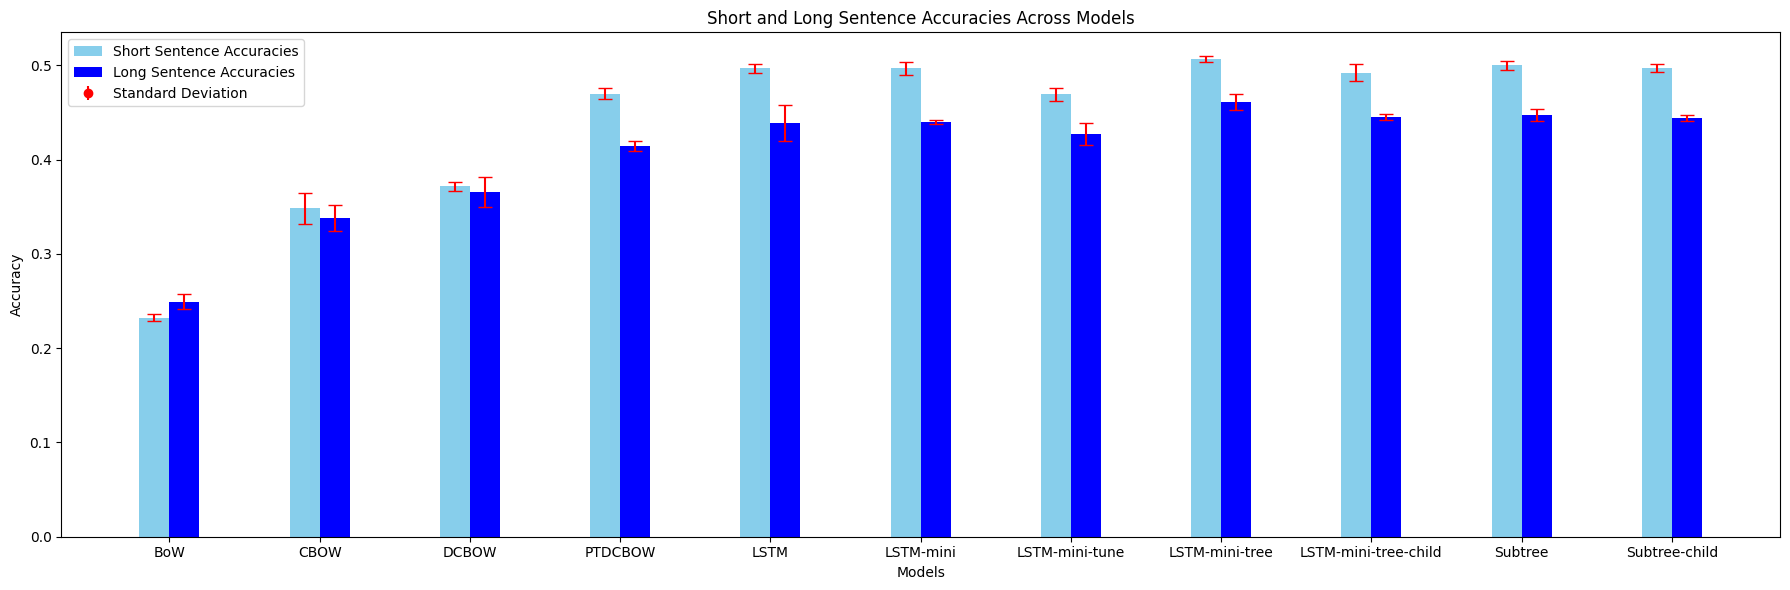

In [ ]:
models = ['BoW', 'CBOW', 'DCBOW', 'PTDCBOW', 'LSTM', 'LSTM-mini', 'LSTM-mini-tune', 'LSTM-mini-tree', 'LSTM-mini-tree-child', 'Subtree', 'Subtree-child']
short_means = [short_acc_means_bow[0], short_acc_means_cbow[0], short_acc_means_dcbow[0], short_acc_means_ptdcbow[0], short_acc_means_lstm[0], short_acc_means_lstm_mini[0], short_acc_means_lstm_mini_tune[0], short_acc_means_lstm_mini_tree[0], short_acc_means_lstm_mini_tree_child[0], short_acc_means_subtree[0], short_acc_means_subtree_child[0]]
short_stds = [short_acc_stds_bow[0], short_acc_stds_cbow[0], short_acc_stds_dcbow[0], short_acc_stds_ptdcbow[0], short_acc_stds_lstm[0], short_acc_stds_lstm_mini[0], short_acc_stds_lstm_mini_tune[0], short_acc_stds_lstm_mini_tree[0], short_acc_stds_lstm_mini_tree_child[0], short_acc_stds_subtree[0], short_acc_stds_subtree_child[0]]
long_means = [long_acc_means_bow[0], long_acc_means_cbow[0], long_acc_means_dcbow[0], long_acc_means_ptdcbow[0], long_acc_means_lstm[0], long_acc_means_lstm_mini[0], long_acc_means_lstm_mini_tune[0], long_acc_means_lstm_mini_tree[0], long_acc_means_lstm_mini_tree_child[0], long_acc_means_subtree[0], long_acc_means_subtree_child[0]]
long_stds = [long_acc_stds_bow[0], long_acc_stds_cbow[0], long_acc_stds_dcbow[0], long_acc_stds_ptdcbow[0], long_acc_stds_lstm[0], long_acc_stds_lstm_mini[0],  long_acc_stds_lstm_mini_tune[0], long_acc_stds_lstm_mini_tree[0], long_acc_stds_lstm_mini_tree_child[0], long_acc_stds_subtree[0], long_acc_stds_subtree_child[0]]

x = np.arange(len(models)) * 0.5
fig, ax = plt.subplots(figsize=(18, 6))

short_bar = ax.bar(x - 0.2/4, short_means, 0.2/2, label='Short Sentence Accuracies', yerr=short_stds, capsize=5, color='skyblue', ecolor='red')
long_bar =  ax.bar(x + 0.2/4, long_means, 0.2/2, label='Long Sentence Accuracies', yerr=long_stds, capsize=5, color='blue', ecolor='red')

ax.errorbar([], [], yerr=1, fmt='o', color='red', label='Standard Deviation')

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Short and Long Sentence Accuracies Across Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()
